<a href="https://colab.research.google.com/github/vsaengerderache/scour_ai/blob/main/scour_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [939]:
import this

In [940]:
!pip install ipytest
!pip install scikit-optimize
import ipytest
import pytest

ipytest.autoconfig()

In [941]:
# import library

from google.colab import drive
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from shapely import wkt
import geopandas as gpd
import seaborn as sns
from pprint import pprint
import math
import pytest

In [942]:
# connect to drive
drive.mount('/content/drive')

# path to working directory
%cd '/content/drive/My Drive/shared_folder_scour_ai//datos'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/My Drive/shared_folder_scour_ai/datos


# Data exploration


Upload dataset, processing, detect outliers

In [943]:
!ls # show files in folder

 01_DATA.xlsx		    2001_Yammaz.xls		 eq_lead_combined.png
 1980_Jain_y_fischer.xlsx   2005_Mueller_y_Wagner.xlsx	 feature_importance
 1982_Chee.xlsx		   '2009_ Lee_y_Sturm.xlsx'	 models
 1982_zanke.xls		    2013_Lanca_et_al.xlsx	 Pier_Shape.xlsx
 1984_Chiew.xlsx	    data_processed		 plot
 1995_Dey_et_al.xls	    data_run			 res
 2001_Ting_et_al.xls	    Datos_supercriticos.xlsx	 results


In [944]:
# read dataset
df = pd.read_excel('01_DATA.xlsx')
df = df.iloc[1:].reset_index(drop=True) # delete first row
df = df.rename(columns={ # rename columns
    'id': 'id',
    'Autor': 'author',
    'Denominacion original': 'original denomination',
    'scour depth (m)': 'ymax',
    'pier diameter (m)': 'b',
    'flow depth (m)': 'h',
    'flow velocity (m/s)': 'v',
    'D50 (mm)': 'd50',
    'H/b': 'h/b',
    'b/D50': 'b/d50'
})
 # create id col
df['id'] = range(1, len(df) + 1)
df = df[['id'] + [col for col in df.columns if col != 'id']]

# replace - and 999 by NA
df = df.where(~df.isin(['-', 999]), pd.NA)

# put _ in the col names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

 # convert columns to numeric where possible
numeric_cols = ['ymax', 'b', 'h', 'v', 'd50', 'sigma', 'skew', 'ds/b', 'b/d50']

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# convert pier shape to lowercase
df['pier_shape'] = df['pier_shape'].astype(str).str.lower()

display(df) # display
print(df.dtypes) # types

,id,unnamed:_0,author,original_denomination,ymax,b,h,v,d50,d50_(m),ro,sigma,pier_shape,skew,ds/b,h/b,b/d50,fr
0,1.0,1.0,Jain and Fischer (1981),F-2,0.09900,0.0508,0.102,0.75,0.25,0.00025,1.65,1.34,cylindrical,0,1.948819,2.007874,203.200000,0.749768
1,2.0,2.0,Jain and Fischer (1981),F-3,0.11400,0.0508,0.102,1.00,0.25,0.00025,1.65,1.34,cylindrical,0,2.244094,2.007874,203.200000,0.999690
2,3.0,3.0,Jain and Fischer (1981),F-4,0.15700,0.0508,0.102,1.20,0.25,0.00025,1.65,1.34,cylindrical,0,3.090551,2.007874,203.200000,1.199628
3,4.0,4.0,Jain and Fischer (1981),M-1,0.08600,0.0508,0.102,0.50,1.50,0.00150,1.65,1.25,cylindrical,0,1.692913,2.007874,33.866667,0.499845
4,5.0,5.0,Jain and Fischer (1981),M-2,0.08700,0.0508,0.102,0.65,1.50,0.00150,1.65,1.25,cylindrical,0,1.712598,2.007874,33.866667,0.649799
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1025,1026.0,1222.0,Chiew (1984),A5-02,0.09855,0.0450,0.240,1.43,0.85,0.00085,1.65,1.23,cylindrical,0,2.190000,5.333333,52.941176,0.931957
1026,1027.0,1223.0,Chiew (1984),A5-03,0.09540,0.0450,0.240,1.21,0.85,0.00085,1.65,1.23,cylindrical,0,2.120000,5.333333,52.941176,0.788579
1027,1028.0,1224.0,Chiew (1984),A5-04,0.09855,0.0450,0.240,1.46,0.85,0.00085,1.65,1.23,cylindrical,0,2.190000,5.333333,52.941176,0.951509
1028,1029.0,1225.0,Chiew (1984),A5-05,0.09630,0.0450,0.340,1.39,0.85,0.00085,1.65,1.23,cylindrical,0,2.140000,7.555556,52.941176,0.761098


id                       float64
unnamed:_0               float64
author                    object
original_denomination     object
ymax                     float64
b                        float64
h                        float64
v                        float64
d50                      float64
d50_(m)                  float64
ro                       float64
sigma                    float64
pier_shape                object
skew                       int64
ds/b                     float64
h/b                      float64
b/d50                    float64
fr                       float64
dtype: object


In [945]:
df_zero_velocity = df[df['v'] == 0]
print(df_zero_velocity)
df = df[df['v'] != 0].copy()

Empty DataFrame
Columns: [id, unnamed:_0, author, original_denomination, ymax, b, h, v, d50, d50_(m), ro, sigma, pier_shape, skew, ds/b, h/b, b/d50, fr]
Index: []


* ymax (m) (scour depth max)
* b (m) (pier diameter)
* h (m) (flow depth)
* v (m/s) (flow velocity)
* d50 (mm) (particle diameter)
* sigma (geometric standard deviation)

In [946]:
print(df.isna().sum())

id                       1
unnamed:_0               1
author                   0
original_denomination    0
ymax                     0
b                        0
h                        0
v                        0
d50                      0
d50_(m)                  0
ro                       0
sigma                    0
pier_shape               0
skew                     0
ds/b                     0
h/b                      0
b/d50                    0
fr                       0
dtype: int64


In [947]:
df.dropna(subset=['ymax'], inplace=True)

In [948]:
df.dropna(subset=['d50'], inplace=True)
print(df.isna().sum())

id                       1
unnamed:_0               1
author                   0
original_denomination    0
ymax                     0
b                        0
h                        0
v                        0
d50                      0
d50_(m)                  0
ro                       0
sigma                    0
pier_shape               0
skew                     0
ds/b                     0
h/b                      0
b/d50                    0
fr                       0
dtype: int64


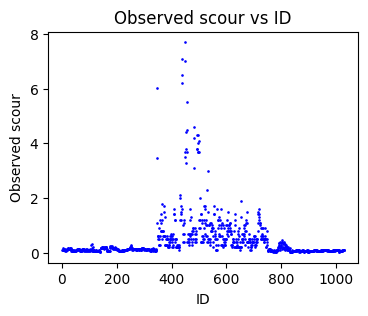

In [949]:
# plot observed scour vs id
plt.figure(figsize=(4, 3))
df = df.dropna(subset=['id', 'ymax'])
plt.scatter(df['id'], df['ymax'], color='b', s=0.8)
plt.xlabel('ID')
plt.ylabel('Observed scour')
plt.title('Observed scour vs ID')
plt.show()

In [950]:
# Detect duplicates
duplicates = df[df.duplicated()]

# check if there are any duplicates
if not duplicates.empty:
    print('Warning: Duplicate values found in the dataset')
    display(duplicates)
else:
    print('No duplicate values found in the dataset')

No duplicate values found in the dataset


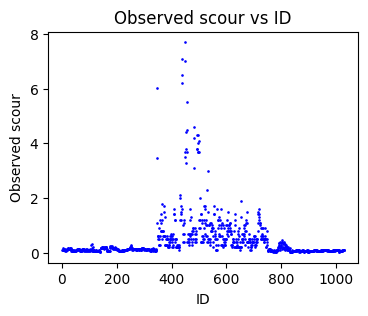

In [951]:
# Delete outliers
#df = df[~df['ymax'].isin(df['ymax'].nlargest(2))]  # delete two largest values

# observed scour vs id
plt.figure(figsize=(4, 3))
plt.scatter(df['id'], df['ymax'], color='b', s=0.8)
plt.xlabel('ID')
plt.ylabel('Observed scour')
plt.title('Observed scour vs ID')
plt.show()

In [952]:
df['pier_shape'] = (
    df['pier_shape']
    .str.strip()
    .str.lower()
    .replace({
        'cylindrical': 'circular',
        'round': 'circular',
        'square': 'rectangular'
    })
)
print(df['pier_shape'].unique())

['circular' 'sharp' 'rectangular']


# Calculation with traditional scour formulas

Calculate for each observation in the dataset the scour values preditect by the equations provided



In [953]:
df = df.copy()

g = 9.81  # gravity acceleration (m/s^2)
density_solid = 2650
density_water = 1000
delta = 1.65  # relative density: (solid density - water density) / water density
nu = 0.000001  # kinematic viscosity (m2/s)

df['g'] = g
df['density_solid'] = density_solid
df['density_water'] = density_water
df['delta'] = (df['density_solid']-df['density_water']) / df['density_water']
df['density_t_m3'] = df['ro']+1
df['nu'] = nu

In [954]:
df['w'] = 11 / df['d50'] * nu * (df['b']**3 * 0.01 + 1)**0.5 - 1
df['fr'] = df['v'] / (df['g'] * df['h'])**0.5
df['b_d50'] = df['b'] / df['d50']
df['h_b'] = df['h'] / df['b']
df['obs_dimensionless'] = df['ymax'] / df['b']
df['b/h'] = df['b'] / df['h']

In [955]:
# vcr estimated to Neill 1973
def calculate_vcr_n(d50, h):
    d50=d50/1000

    if d50 < 0.0009:
        theta_s = 0.0019 * d50**(-0.384)
    elif 0.0009 <= d50 <= 0.020:
        theta_s = 0.0942 * d50**(0.175)
    else:
        theta_s = 0.047

    vcr_n = (theta_s)**0.5 * 31.08 * h**(1/6) * d50**(1/3)
    return vcr_n

In [956]:
# vcr estimated from Shields 1936
def calculate_vcr_shields(d50, h):
  """
  References:
    https://doi.org/10.1061/(ASCE)HY.1943-7900.0000800
    https://drive.google.com/file/d/1Bt9rjmcilpVrn8minHE_v-1iR984_Raz/view

  """
  v_c = np.nan

  y_1 = h
  d50 = d50 / 1000
  # Eq. (11)
  u_asterisk = (16.2*d50*((9.09*10**(-6)/d50)-d50*(38.76+9.6*np.log(d50))-0.005))**0.5
  # Eq. (12)
  r = u_asterisk * d50 / (2.32*10**(-7))

  if 5 <= r and r <= 70:
    v_c = 2.5 * u_asterisk * np.log(73.5*y_1/(d50*(r*(2.85-0.58*np.log(r)+0.002*r)+111/r-6)))
  elif r > 70:
    v_c = 2.5 * u_asterisk * np.log(2.21*y_1/d50)
  elif r < 5:
    v_c = np.nan

  return(v_c)

In [957]:
# vcr estimated from Zanke 198-
def calculate_vcr_zanke(d50, g, delta, nu):
    d50_m = d50 / 1000  # convert d50 to m
    vcr = 1.4 * (2 * (g * delta * d50_m) ** 0.5 + 10.5 * nu / d50_m)
    return vcr

In [958]:
# vcr estimated from Zhang et al. 198
def calculate_vcr_zhang(d_o, d, p_s, p):
  """
  References:
    CEL: https://rosap.ntl.bts.gov/view/dot/855

  Args:
    d_o: normal depth
    d: average diameter of bed material
    p_s: density of sediment particles
    p: density of water

  Return:
    v_c: critical velocity
  """
  # Eq. (2)
  v_c = ((d_o/d)**0.14) * (17.6*(p_s-p)/p*d+0.00000605*((10+d_o)/(d**0.72)))**0.5

  return(v_c)

In [959]:
# apply functions vcr to df
df['vcr_neill'] = df.apply(lambda row: calculate_vcr_n(row['d50'], row['h']), axis=1)
df['vcr_shields'] = df.apply(lambda row: calculate_vcr_shields(row['d50'], row['h']), axis=1)
df['vcr_zanke'] = df.apply(lambda row: calculate_vcr_zanke(row['d50'], row['g'], row['delta'], row['nu']), axis=1)
df['vcr_zhang'] = df.apply(lambda row: calculate_vcr_zhang(row['h'], row['d50']/1000, row['density_solid'], row['density_water']), axis=1)
# other
df['v_vcr_n']= df['v'] / df['vcr_neill']
df['v_vcr']= df['v'] / df['vcr_zanke']

display(df)

/tmp/ipython-input-374952169.py:14: RuntimeWarning: invalid value encountered in scalar power
  u_asterisk = (16.2*d50*((9.09*10**(-6)/d50)-d50*(38.76+9.6*np.log(d50))-0.005))**0.5


,id,unnamed:_0,author,original_denomination,ymax,b,h,v,d50,d50_(m),...,b_d50,h_b,obs_dimensionless,b/h,vcr_neill,vcr_shields,vcr_zanke,vcr_zhang,v_vcr_n,v_vcr
0,1.0,1.0,Jain and Fischer (1981),F-2,0.09900,0.0508,0.102,0.75,0.25,0.00025,...,0.203200,2.007874,1.948819,0.498039,0.286770,0.235979,0.236917,0.409987,2.615338,3.165670
1,2.0,2.0,Jain and Fischer (1981),F-3,0.11400,0.0508,0.102,1.00,0.25,0.00025,...,0.203200,2.007874,2.244094,0.498039,0.286770,0.235979,0.236917,0.409987,3.487118,4.220894
2,3.0,3.0,Jain and Fischer (1981),F-4,0.15700,0.0508,0.102,1.20,0.25,0.00025,...,0.203200,2.007874,3.090551,0.498039,0.286770,0.235979,0.236917,0.409987,4.184542,5.065073
3,4.0,4.0,Jain and Fischer (1981),M-1,0.08600,0.0508,0.102,0.50,1.50,0.00150,...,0.033867,2.007874,1.692913,0.498039,0.422550,0.373473,0.446095,0.404314,1.183292,1.120838
4,5.0,5.0,Jain and Fischer (1981),M-2,0.08700,0.0508,0.102,0.65,1.50,0.00150,...,0.033867,2.007874,1.712598,0.498039,0.422550,0.373473,0.446095,0.404314,1.538279,1.457089
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1025,1026.0,1222.0,Chiew (1984),A5-02,0.09855,0.0450,0.240,1.43,0.85,0.00085,...,0.052941,5.333333,2.190000,0.187500,0.393173,0.329433,0.345725,0.410762,3.637071,4.136236
1026,1027.0,1223.0,Chiew (1984),A5-03,0.09540,0.0450,0.240,1.21,0.85,0.00085,...,0.052941,5.333333,2.120000,0.187500,0.393173,0.329433,0.345725,0.410762,3.077522,3.499892
1027,1028.0,1224.0,Chiew (1984),A5-04,0.09855,0.0450,0.240,1.46,0.85,0.00085,...,0.052941,5.333333,2.190000,0.187500,0.393173,0.329433,0.345725,0.410762,3.713373,4.223010
1028,1029.0,1225.0,Chiew (1984),A5-05,0.09630,0.0450,0.340,1.39,0.85,0.00085,...,0.052941,7.555556,2.140000,0.132353,0.416673,0.347261,0.345725,0.431898,3.335948,4.020537


In [960]:
df['h/vcr'] = df['h'] / df['vcr_zanke']

In [961]:
def meters_to_feet(m):
    return m * (1/0.3084)

def feet_to_meters(ft):
    return ft / (1/0.3084)

In [962]:
def cal_2003_van_rijn_v_lp(d50, d90, h, p=1000, p_s=2650, g=9.81, nu=1e-6):
    """
    Calculated live-bed peak velocity from van Rijn 1993, pp. 5.3 and 5.4

    Args:
    - d50: median particle size
    - d90: particle size at 90% finer
    - h: mean water depth
    - p: fluid density
    - p_s: sediment density
    - g: gravedad (m/s²)
    - nu: fluid viscocity

    Return:
    - v_lp: live-bed peak velocity
    """

    s = p_s / p
    d_astersik = ((s - 1) * g / nu**2)**(1/3) * d50

    # Eq. (4.1.11)
    if 1 < d_astersik <= 4:
        theta_cr = 0.24 * d_astersik**-1
    elif 4 < d_astersik <= 10:
        theta_cr = 0.14 * d_astersik**-0.64
    elif 10 < d_astersik <= 20:
        theta_cr = 0.04 * d_astersik**-0.1
    elif 20 < d_astersik <= 150:
        theta_cr = 0.013 * d_astersik**0.29
    elif d_astersik > 150:
        theta_cr = 0.055
    else:
        return np.nan

    t_bcr = theta_cr * ((p_s - p) * g * d50)

    v_lp = 0.001  # velocity initial
    while v_lp < 10:
        c_prime = 18 * np.log10((12 * h) / (3 * d90))
        t_bc = p * g * (v_lp / c_prime)**2
        t = (t_bc - t_bcr) / t_bcr
        fr = v_lp / np.sqrt(g * h)

        if fr >= 0.8 and t >= 25:
            return v_lp
        v_lp += 0.001  # velocity increment

    return np.nan

In [963]:
%%ipytest

"""
Examples Table 1 - https://doi.org/10.1061/(ASCE)0733-9429(2006)132:7(635)
"""

@pytest.mark.parametrize('d50, d90, h, expected', [
    (0.27/1000, 0.27/1000*1.5, 0.42, 1.61),
    (0.27/1000, 0.27/1000*1.5, 0.40, 1.58),
])
def test_cal_2003_van_rijn_v_lp(d50, d90, h, expected):
    result = cal_2003_van_rijn_v_lp(d50=d50, d90=d90, h=h)
    assert pytest.approx(result, rel=0.01) == expected

..                                                                                           [100%]
2 passed in 0.44s


In [964]:
df['d50/h'] = df['d50'] / df['h']

##### Separate dataset: sub-critic and super-critic

In [965]:
# Separate dataset: sub-critic and super-critic
df_subcritic = df[df['fr'] <= 1].copy()
df_supercritic = df[df['fr'] > 1].copy()

print(f'Subcritical dataset: {len(df_subcritic)} observations')
print(f'Supercritical dataset: {len(df_supercritic)} observations')

Subcritical dataset: 938 observations
Supercritical dataset: 91 observations


In [966]:
# Export
df_subcritic.to_csv('data_processed/df_subcritic.csv', index=False)
df_supercritic.to_csv('data_processed/df_supercritic.csv', index=False)

## Equations functions

###### 1901 Santa María

In [967]:
def eq_1901_santa_maria(h, u_s, u_asterisk_c):
  """ Calculate maximum scour depth at a pier
  Sources:
    https://doi.org/10.1061/JHEND8.HYENG-14216

  Args:
    h: flow depth
    u_s: flow velocity
    u_asterisk_c: critical shear velocity for inception of sediment

  Return:
    d_s: maximum scour depth

  """
  d_s = h * ((0.65 * u_s - u_asterisk_c) / (u_s - 0.65 * u_s))

  if (0.65 * u_s - u_asterisk_c) <= 0:
    d_s = 0

  return d_s

In [968]:
%%ipytest

"""
Table 3
"""
@pytest.mark.parametrize('h, u_s, u_asterisk_c, expected', [
    (3.4, 6.0, 1.8, 3.40),
    (3.5, 7.0, 1.8, 3.93),
    (4.0, 8.0, 1.8, 4.86),
    (4.2, 7.0, 1.8, 4.71),
    (5.0, 7.3, 1.8, 5.76),
    #(6.0, 8.0, 1.8, 6.80),
    #(7.0, 9.0, 1.8, 8.36),
    #(6.0, 8.0, 1.5, 7.27),
    #(4.0, 3.54, 0.25, 5.79),
    #(4.0, 8.53, 0.25, 6.21),
    (5.0, 10.0, 1.6, 7.00),
    (4.0, 10.0, 1.85, 5.31),
    #(4.0, 2.31, 0.3, 5.20),
    (4.0, 8.5, 1.4, 5.55),
])

def test_eq_1909_santa_maria(h, u_s, u_asterisk_c, expected):
    result = eq_1901_santa_maria(h, u_s, u_asterisk_c)
    assert pytest.approx(result, rel=0.001) == expected

........                                                                                     [100%]
8 passed in 0.15s


###### 1949 Inglis

In [969]:
def eq_1949_inglis(h, b, v):
  """
  Source:
    CEL: https://www.researchgate.net/publication/341323092_Validation_of_Bridge_Pier_and_Abutment_Scour_Equations

    CEL: https://citeseerx.ist.psu.edu/document?repid=rep1&type=pdf&doi=6da62afb7e9820afd6fad5c3a8a0c93c4e2c4364

    CEL: https://doi.org/10.2166/aqua.2024.235

  Args:
    b: width of bridge pier
    h: flow depth
    fr: froude number

  Returns:
    d_s: scour depth
  """

  d_s = (2.32*v**0.52*h**0.52*b**0.22)-h

  return d_s

###### 1960 Laursen

In [970]:
import numpy as np
from scipy.optimize import brentq

def eq_1960_laursen(y_0, b):
    r = 11.5

    tol   = 1e-2     # tolerancia sobre la ecuación
    step  = 1e-2     # incremento en d_s (ft)
    max_s = 100.0    # cota superior (ft)

    d_s = step
    while d_s <= max_s:
      term_0 = b / y_0
      term_1 = 5.5 * (d_s / y_0)
      term_2 = ((d_s / (y_0 * r)) + 1.0)**1.7 - 1
      obj = term_1 * term_2 - term_0

      if abs(obj) <= tol:
          return d_s

      d_s += step

In [971]:
%%ipytest

@pytest.mark.parametrize('h, b, expected', [
    (feet_to_meters(69), feet_to_meters(47), feet_to_meters(63)),
    (feet_to_meters(28.2), feet_to_meters(6.5833333333), feet_to_meters(13.6)),
    (feet_to_meters(31.2), feet_to_meters(6.5833333333), feet_to_meters(14.5)),
    (feet_to_meters(35.1), feet_to_meters(6.5833333333), feet_to_meters(15.4))
])

def test_eq_1960_laursen(h, b, expected):
    result = eq_1960_laursen(h, b)
    assert pytest.approx(result, rel=0.01) == expected

FFFF                                                                                         [100%]
============================================= FAILURES =============================================
__________________________ test_eq_1960_laursen[21.2796-14.4948-19.4292] ___________________________

h = 21.2796, b = 14.4948, expected = 19.4292

    @pytest.mark.parametrize('h, b, expected', [
        (feet_to_meters(69), feet_to_meters(47), feet_to_meters(63)),
        (feet_to_meters(28.2), feet_to_meters(6.5833333333), feet_to_meters(13.6)),
        (feet_to_meters(31.2), feet_to_meters(6.5833333333), feet_to_meters(14.5)),
        (feet_to_meters(35.1), feet_to_meters(6.5833333333), feet_to_meters(15.4))
    ])
    
    def test_eq_1960_laursen(h, b, expected):
        result = eq_1960_laursen(h, b)
>       assert pytest.approx(result, rel=0.01) == expected
E       assert 19.080000000000183 ± 0.1908 == 19.4292
E         
E         comparison failed
E         Obtained: 19.4292
E   

###### 1962 Blench - Inglis I



In [972]:
def eq_1962_blench_inglis_i(h, b):
  """
  Source:


  Args:
    b: width of bridge pier
    h: flow depth

  Returns:
    d_s: scour depth
  """

  d_s = (1.8 * b**0.25 * h**0.75)/h - h

  return max(d_s,0)

###### 1962 Blench - Inglis II


In [973]:
def eq_1962_blench_inglis_ii(h, b, v, d50):
  """
  Source:

  Args:
    b: width of bridge pier
    h: flow depth
    v: flow velocity
    d50: diameter of sediment

  Returns:
    d_s: scour depth
  """

  d_s = (((1.14 * b**0.25 * v**0.5 * d50**(-0.125))/h)-1) * h

  return max(d_s,0)

###### 1962 Chitale

In [974]:
def eq_1962_chitale(h, fr):
  """
  Source:
    https://doi.org/10.1061/TACEAT.0008391

  Args:
    b: width of bridge pier (m)
    h_0: flow depth (m)

  Returns:
    y_m_e: equilibrium scour depth (m) """

  if fr < 0.1 or fr > 0.5:
    return 'NaN_out_of_bonds'

  d_s = h * (0.49 + (6.65 * fr)- (5.49 * fr**2))
  if (0.49 + (6.65 * fr)  - (5.49 * fr**2)) >=0:
    d_s = h * ( 0.49 + (6.65 * fr) - (5.49 * fr**2))
  else:
    return 'NaN_out_of_bonds'

  return d_s

###### 1963 Laursen

In [975]:
import numpy as np
from scipy.optimize import brentq

def eq_1963_laursen(b, y_0, v_0, d50):
  """
  References:
    https://doi.org/10.1061/JYCEAJ.0000896

  Args:
    b: pier width
    d_o: approach flow depth

  Return:
    d_s: scour depth

  """
  r = 12
  d50  = d50/1000

  tau_pr = (v_0**2) / (37*(d50)**(2/3)*y_0**(1/3))
  if tau_pr >= 1:
    return 'NaN_out_of_bonds'
  print("Tau:",tau_pr)

  tol   = 1e-2     # tolerancia sobre la ecuación
  step  = 1e-3     # incremento en d_s
  max_s = 1000.0    # cota superior

  d_s = step
  while d_s <= max_s:
    term_0 = b / y_0
    term_1 = 5.5 * (d_s / y_0)
    term_2 = (((d_s / (y_0 * r)) + 1.0)**(7/6) / (tau_pr**0.5) - 1.0)
    obj = term_1 * term_2 - term_0

    if abs(obj) <= tol:
        return d_s

    d_s += step

In [976]:
%%ipytest
"""
Test with TBR and Laursen 1963 with Poona data
"""
@pytest.mark.parametrize('b, h, v, d50, expected', [
    (feet_to_meters(47), feet_to_meters(69),  feet_to_meters(2), 1,  feet_to_meters(13)),
    (feet_to_meters(0.57), feet_to_meters(1.25),  feet_to_meters(0.8), 0.16,  feet_to_meters(0.5)),
    (feet_to_meters(0.57), feet_to_meters(1.05),  feet_to_meters(0.95), 0.24,  feet_to_meters(0.75)),
])

def test_eq_1963_laursen(b, h, v, d50, expected):
    result = eq_1963_laursen(b, h, v, d50)
    assert pytest.approx(result, rel=0.1) == expected

...                                                                                          [100%]
3 passed in 0.19s


###### 1963 Larras

In [977]:
"1977 breuses, page 225"
def eq_1963_larras(b):
  scour_depth = 1.05*(b**0.75)
  return scour_depth

###### 1964 Neill

In [978]:
def eq_1964_neill_fit_laursen_and_toch(b, h_0):
  """Calculate equilibrium depth of local scour
  Source: Melville (1975)

  Args:
    b: width of bridge pier (m)
    h_0: flow depth (m)

  Returns:
    y_m_e: equilibrium scour depth (m) """

  d_s = 1.5 * b **0.7 * h_0**0.3

  return d_s

###### 1965 Breusers

In [979]:
def eq_1965_breusers(b):
  d_s = 1.4*b
  return d_s

###### 1966 Shen et al.

In [980]:
def eq_1966_shen(fr,b):
  """
  Source:
    CEL: https://doi.org/10.2166/aqua.2024.235

  Args:
    b: width of bridge pier
    fr: froude number

  Returns:
    d_s: scour depth
  """

  d_s = 11 * b * (fr)**2

  return d_s

###### 1967 Arunachalam

In [981]:
""" 1977 breusers, page 222 """
def eq_1967_arunachalam(b, h):
  """Calculate equilibrium depth of local scour
  Source: https://doi.org/10.1080/00221687709499645

  Args:
    b: pier width (m)
    h: flow depth (m)

  Returns:
    d_s: maximum depth reached by the scour hole around the pier after sufficient time has elapsed to reach the equilibrium (m) """

  d_s= b * (1.95 * (b/h)**(1/6) - 1)

  return d_s

###### 1971 Coleman

In [982]:
""" 1977 breusers, page 230 """
"https://drive.google.com/file/d/1wPpNYPKgKsyFuWdUFW7EJZsSWiNUacVt/view?usp=sharing"
def eq_1971_coleman(b, v, h, g):
  d_s = 1.49 * b * ((v**2/(g*h))**(1/10))
  return d_s

###### 1971 Hancu

In [983]:
"https://drive.google.com/file/d/13EuWudXdeZ1EQuDWlDqKkD-EYDAdkGrK/view?usp=drive_link"
""" 1990 May, page 8 eq 10 """
""" 1977 breusers, page 241 eq 16"""
def eq_1971_hancu(b, d_0, d):
  """Calculate equilibrium depth of local scour
  Source: https://doi.org/10.1080/00221687709499645

  Args:
    b: pier width (m)
    d_0: flow depth (m)
    d: diameter of sediment (m)

  Returns:
    d_s: maximum depth reached by the scour hole around the pier after sufficient time has elapsed to reach the equilibrium (m) """

  d = d/1000
  d_s = b * 3.3 * (d/b)**0.2 * (d_0/b)**0.13

  return d_s

###### 1973 Neill

In [984]:
def eq_1973_neill(b, pier_shape):
  """Calculate equilibrium depth of local scour
  Source:
    Guide to bridge hydraulics, Neil 1973

    CEL: https://doi.org/10.2166/aqua.2024.235

  Args:
    b:
    y_o:
    u:
    d:

  Returns:
    d_s:
  """
  if pier_shape== 'circular':
    k_5 = 1
  elif pier_shape == 'rectangular':
    k_5 = 2
  elif pier_shape == 'sharp':
    k_5 = 1.2


  d_s = b * k_5

  return d_s

###### 1975 Basak et al.

In [985]:
""" (1977 breusers, page 233) """
def eq_1975_basak(b):
  """ for square piers """
  scour_depth = 0.558 * b**0.586
  return scour_depth

###### 1975 CSU Equation

Ref: Richardson et al. (1975)

In [986]:
def eq_1975_csu_equation(fr, h, b):
  """
  Source:
    https://doi.org/10.2166/aqua.2024.235

  Ars:
    b: pier diameter
    h: depth of approach flow
    fr: froude number

  Return:
    d_s: scour depth
  """

  d_s = 2 * b * (h/b)**0.35 * fr**0.43

  return d_s


In [987]:
# Calcular socavación usando eq_1975_csu_equation
#df_subcritic['d_s_csu'] = df_subcritic.apply(
#    lambda row: eq_1975_csu_equation(
##        fr=row['fr'],
 #       h=row['h'],
 #       b=row['b']
 #   ), axis=1
#)

# Calcular la razón d_s/b
#df_subcritic['d_s_csu_b'] = df_subcritic['d_s_csu'] / df_subcritic['b']

# Filtrar observaciones con valores inusualmente altos (por ejemplo, > 4 veces el ancho del pilar)
#df_outliers_csu = df_subcritic[df_subcritic['d_s_csu_b'] > 4]

# Mostrar filas problemáticas
#print(df_outliers_csu[['id', 'b', 'h', 'fr', 'd_s_csu', 'd_s_csu_b']])

# Mostrar estadísticas resumen
#print('Número de outliers CSU:', len(df_outliers_csu))
#print('Máximo valor de d_s (CSU):', df_outliers_csu['d_s_csu_b'].max())

###### 1977 Breusers et al.

In [988]:
def eq_1977_breusers(d_0, b, u, d50, pier_shape):
  """
  Source: http://dx.doi.org/10.1080/00221687709499645

  Ars:
    b: pier diameter
    d_0: depth of approach flow
    u: mean velocity of undisturbed flow

  Return:
    d_s: scour depth
  """

  u_c = 0.85 * (2*g*delta*d50/1000)**(1/2)

  if (u/u_c) <= 0.5 :
    f_1 = 0
  elif 0.5 <(u/u_c) <= 1:
    f_1 = (2*u/u_c -1)
  elif (u/u_c) >= 1:
    f_1 = 1

  shape_map = {"circular": 1.0, "rectangular": 1.3}
  f_2 = shape_map.get(pier_shape.lower(), 1.0)

  f_3 = 1 # l=b

  d_s = b * (f_1 * (2 * np.tanh(d_0/b) * f_2 * f_3))

  return d_s

In [989]:
#%%ipytest

"""
Examples from: https://doi.org/10.1061/(ASCE)0733-9429(2006)132:7(635)
Table 1 and Table 2
Results are adimensional
"""

@pytest.mark.parametrize('test, d, d50, y0, v, v_c, breusers', [
    ('1', 0.152, 0.27, 0.42, 0.17, 0.27, 0.52),
    ('2', 0.152, 0.27, 0.42, 0.62, 0.28, 1.73),
    ('3', 0.152, 0.27, 0.43, 0.88, 0.28, 1.99),
    ('4', 0.152, 0.27, 0.4, 1.1, 0.28, 1.98),
    ('5A', 0.152, 0.27, 0.4, 1.26, 0.28, 1.98),
    ('5B', 0.152, 0.27, 0.4, 1.43, 0.27, 1.98),
    ('6', 0.152, 0.27, 0.4, 1.64, 0.27, 1.98),
    ('7A', 0.152, 0.27, 0.2, 0.55, 0.25, 1.52),
    ('7B', 0.152, 0.27, 0.2, 0.72, 0.25, 1.73),
    ('8', 0.152, 0.27, 0.43, 0.69, 0.28, 1.99),
    ('10', 0.152, 0.84, 0.43, 0.37, 0.41, 1.59),
    ('11', 0.152, 0.84, 0.38, 0.58, 0.41, 1.97),
    ('12', 0.152, 0.84, 0.38, 0.74, 0.41, 1.97),
    ('13', 0.152, 0.84, 0.38, 1.05, 0.41, 1.97),
    ('14', 0.152, 0.84, 0.38, 1.21, 0.41, 1.97),
    ('15', 0.152, 0.84, 0.38, 1.37, 0.41, 1.97),
    ('16', 0.152, 0.84, 0.38, 1.52, 0.41, 1.97),
    ('17', 0.152, 0.84, 0.3, 1.52, 0.4, 1.92),
    ('18', 0.152, 0.84, 0.3, 1.76, 0.4, 1.92),
    ('19', 0.152, 0.84, 0.3, 1.85, 0.4, 1.92),
    ('20', 0.152, 0.84, 0.3, 1.99, 0.4, 1.92),
    ('21', 0.152, 0.84, 0.3, 2.16, 0.4, 1.92),
    ('22', 0.152, 0.84, 0.43, 0.25, 0.41, 1.46),
])

def test_eq_1977_breusers(test, d, y0, v, d50, v_c, breusers):
    result = eq_1977_breusers(y0, d, v, d50)
    assert pytest.approx(result, rel=0.4) == (breusers * d)

###### 1980 Jain and Fischer

In [990]:
"""https://drive.google.com/file/d/1kUYinMhdZy9_afmxSMecD0rCUMMvA8Vw/view?usp=drive_link"""
"""page 1838, eq 6"""
def eq_1980_jain_and_fisher(b, d50, fr, h, g, delta, nu):
  D_sed = ((g * delta) / (nu**2))**(1/3) * d50

  #critical Shields parameter theta_cr (page 1834)
  if D_sed >= 145:
    theta_cr = 0.055
  elif 18 <= D_sed < 145:
    theta_cr = 0.013 * D_sed**(0.29)
  elif 10 <= D_sed < 18:
    theta_cr = 0.040 * D_sed**(-0.10)
  elif 6 <= D_sed < 10:
    theta_cr = 0.140 * D_sed**(-0.64)
  else:  # D_sed < 6
    theta_cr = 0.109 * D_sed**(-0.50)

  if (fr - theta_cr)< 0:
    return np.nan
    #return 'NaN_out_of_bonds'

  # Assume viscocity factor = 1
  x = 1

  v_asterisk = theta_cr

  v_c = 2.5*np.log(11.02*h*x/d50)*v_asterisk
  fr_c = v_c/((g*h)**0.5)

  if (fr - fr_c) < 0.15 or (fr - fr_c) > 1.2:
    return 'NaN_out_of_bonds'
  if not (1 <= h / b <= 2):
    return 'NaN_out_of_bonds'

  d_s = (1.86 * (h/b)**0.5 * (fr - fr_c)**0.25) * b

  return d_s

###### 1981 Jain

In [991]:
""" https://doi.org/10.1061/JYCEAJ.0005667 """
def eq_1981_jain(b, h, vcr, g):
  fr_c = vcr/(g*h)**(0.5)
  d_s = 1.84 * b * fr_c**(0.25) * (h/b)**0.3
  return d_s

###### 1982 Zanke

In [992]:
import numpy as np

def eq_1982_zanke(v_c, v, b, band=0.02):
    """
    """
    if b <= 0 or v_c <= 0 or v < 0 or not np.isfinite(v) or not np.isfinite(v_c):
        return np.nan

    v_vcr = v / v_c

    def omega_poly(x):
        return ((((((0.2234*x - 1.9879)*x + 6.3328)*x - 8.3095)*x + 2.5538)*x + 2.0397)*x + 2.0002)

    ds = 0.01 * b
    ds_max = 2.5 * b
    step = 0.01 * b

    while ds <= ds_max:
        x = ds / b
        omega = omega_poly(x)

        if v_vcr >= 1.0:
            denom = np.sqrt(v_vcr**-1 + v_vcr**-2 - v_vcr**-3)
            rhs = b * (omega / denom - 1.0) if np.isfinite(denom) and denom > 0 else np.inf

        elif v_vcr < 1.0:
            rhs = b * (omega * v_vcr - 1.0)

        # banda ±band (por defecto 2%): ds ∈ [rhs, (1+band)*rhs]
        if np.isfinite(rhs) and (ds >= rhs) and (ds <= (1.0 + band) * rhs):
            return ds

        ds += step

    return "NaN_out_of_bonds"

###### 1988 Melville and Sutherland

In [993]:
def eq_1988_melville_and_sutherland(d, y, u, d50, sigma, pier_shape, skew):
  """
  Source: https://doi.org/10.1061/(ASCE)0733-9429(1988)114:10(1210)

  Args:
    y: flow depth
    u: flow velocity
    d: pier diameter
    d50: grain size
    sigma: geometric standard deviation

  Returns:
    d_s: local scour depth """


  """
  k_i: flow intensity
  k_y: flow depth
  k_d: sediment size
  k_sigma: sediment_gradation
  k_s: pier shape
  k_alpha: pier alignment

  """

  # fig. 2. flow chart to calculate u_a
  m = 1.65 # exponent value for eq. (3)
  dmax = (sigma**m) * d50 # eq. (3)
  d50a = dmax/1.8

  # eq. (1)
  # u_asterisk in (m/s); d50 in (mm)

  if d50 > 6:
    u_asterisk_c  = 0.03 * d50**(1/2)
    u_asterisk_ca = 0.03 * d50a**(1/2)
  elif 6 >= d50 > 1:
    u_asterisk_c = 0.0305*d50**(1/2)-0.0065*d50**(-1)
    u_asterisk_ca = 0.0305*d50a**(1/2)-0.0065*d50a**(-1)
  elif 1 >= d50:
    u_asterisk_c = 0.0115+0.0125*d50**1.4
    u_asterisk_ca = 0.0115+0.0125*d50a**1.4
  else:
    return 'NaN_out_of_bonds'

  # eq. (2)
  # d50 in (m)
  u_c = u_asterisk_c*5.75*np.log10(5.53 * (y/(d50/1000)))

  u_ca = u_asterisk_ca*5.75*np.log10(5.53 * (y/(d50a/1000)))


  u_a = 0.8 * u_ca

  # fig. 2. flow chart to calculate u_a


  if u_a >= u_c:
    u_a = u_a
  elif u_a <= u_c:
    u_a = u_c

  # k_i
  if u_c == 0:
    k_i = 'NaN_out_of_bonds'
  elif (u - (u_a - u_c)) / u_c > 1:
    k_i = 2.4
  else:
    k_i = 2.4 * abs((u - (u_a - u_c)) / u_c)

  k_i = min(k_i, 2.4)

  # k_d
  # d50 and d50a in (m)
  if sigma < 1.3:
    if (d/(d50/1000)) > 25:
      # eq. (9a)
      k_d = 1

    elif (d/(d50/1000)) <= 25:
      # eq. (9b)
      k_d = 0.57*np.log10(2.24*d/(d50/1000))

  else:
    if (d/(d50a/1000)) > 25:
      # eq. (9a)
      k_d = 1

    elif (d/(d50a/1000)) <= 25:
      # eq. (9b)
      k_d = 0.57*np.log10(2.24*d/(d50a/1000))
    else:
        k_d = 1  # or whatever is appropriate when equal to 25

  # k_y
  if (y/d) > 2.6:
    # eq. (8a)
    k_y = 1

  elif (y/d) < 2.6 :
    # eq. (8b)
    k_y = 0.78 * (y/d) ** 0.255

  # k_alpha
  # we asume angle of attack=0°, then k_alpha=1
  k_alpha = 1

  # k_s
  # Table 2
  if pier_shape == 'circular':
    k_s = 1
  elif pier_shape == 'rectangular':
    k_s = 1.11
  elif pier_shape == 'sharp':
    k_s = 1.25

  # eq. (7)
  d_s = k_i*k_d*k_y*k_s*k_alpha*d

  return d_s

In [994]:
%%ipytest

"""
Examples from: https://doi.org/10.1061/(ASCE)0733-9429(1988)114:10(1210)
"""

@pytest.mark.parametrize('d, y, u, d50, sigma, pier_shape, skew, expected', [
    (1.2, 1.5, 1.5, 0.5, 2.5,'circular', 0, 2.38),
    (1.2, 1.8, 2.0, 100, 2.0,'circular', 0, 0.98),
])
def test_eq_1988_melville_and_sutherland(d, y, u, d50, sigma, pier_shape, skew, expected):
    result = eq_1988_melville_and_sutherland(d=d, y=y, u=u, d50=d50, sigma=sigma, pier_shape=pier_shape, skew=skew)
    assert pytest.approx(result, rel=0.01) == expected

..                                                                                           [100%]
2 passed in 0.25s


In [995]:
# Calcular socavación usando eq_1988_melville_and_sutherland
df['d_s_melville'] = df.apply(
    lambda row: eq_1988_melville_and_sutherland(
        d=row['b'],
        y=row['h'],
        u=row['v'],
        d50=row['d50'],
        sigma=row['sigma'],
        pier_shape=row['pier_shape'],
        skew=row['skew'],
    ), axis=1
)

# Filtrar observaciones con valores inusualmente altos (por ejemplo, > 3 veces el ancho del pilar)
df['d_s_melville_b']  = df['d_s_melville'] / df['b']
df_outliers = df[df['d_s_melville_b'] > 4 ]
# Mostrar filas problemáticas
print(df_outliers[['id', 'b', 'h', 'v', 'd50', 'sigma', 'd_s_melville', 'd_s_melville_b']])
#display(df_outliers)
# Mostrar estadísticas resumen
print('Número de outliers:', len(df_outliers))
print('Máximo valor de d_s:', df['d_s_melville'].max())

Empty DataFrame
Columns: [id, b, h, v, d50, sigma, d_s_melville, d_s_melville_b]
Index: []
Número de outliers: 0
Máximo valor de d_s: 16.5


###### 1988  Froelich

In [996]:
def eq_1988_froelich(b, h, d50, fr, pier_shape, skew):
  """
   References:
     Froehlich, D.C., 1988, Analysis of on-site measurements of scour at piers, in Abt, S.R., and Gessler, Johannes, eds.,Hydraulic Engineering—Proceedings of the 1988 National Conference on Hydraulic Engineering: New York, American Society of Civil Engineers, p. 534-539.
     https://www.academia.edu/28729468/Analysis_of_onsite_measurements_of_scour_at_piers

   Args:
    h: flow depth
    b: pier width
    skew: angle of atack
    fr: froude number

  Return
    d_s: scour depth

  """


  if pier_shape == "circular":
    k_s = 1
  elif pier_shape == "rectangular":
    k_s = 1.3
  elif pier_shape == "sharp":
    k_s = 0.7

  b_prim = b * np.cos(skew*np.pi/180) + b* np.sin(skew*np.pi/180)

  scour_depth = 0.32 * k_s * (b_prim/b) ** 0.62 * (h/b) ** 0.46 * (fr) ** 0.20 * (b/d50) ** 0.08 * b

  return scour_depth

###### 1988 Froelich - Design

In [997]:
def eq_1988_froelich_design(b, h, d50, fr, pier_shape, skew):
  """
   References:
     Froehlich, D.C., 1988, Analysis of on-site measurements of scour at piers, in Abt, S.R., and Gessler, Johannes, eds.,Hydraulic Engineering—Proceedings of the 1988 National Conference on Hydraulic Engineering: New York, American Society of Civil Engineers, p. 534-539.
     https://www.academia.edu/28729468/Analysis_of_onsite_measurements_of_scour_at_piers

   Args:
    h: flow depth
    b: pier width
    skew: angle of atack
    fr: froude number

  Return
    d_s: scour depth

  """


  if pier_shape == "circular":
    k_s = 1
  elif pier_shape == "rectangular":
    k_s = 1.3
  elif pier_shape == "sharp":
    k_s = 0.7

  b_prim = b * np.cos(skew*np.pi/180) + b* np.sin(skew*np.pi/180)

  scour_depth = (0.32 * k_s * (b_prim/b) ** 0.62 * (h/b) ** 0.46 * (fr) ** 0.2 * (b/d50) ** 0.08 + 1) * b

  return scour_depth

###### 1991 MOP

In [998]:
def eq_1991_mop (b, h, fr, pier_shape, omega):
  """
  Args:
    b: flow depth
    h: flow depth
    fr: froude number
    pier_shape: pier form
    omega:

  Returns:
    s: local scour depth
    """


  if pier_shape== 'circular' or 'sharp':
    k_s = 1
  elif pier_shape == 'rectangular':
    k_s = 1.2

  # w asume pile with same values of widt and large
  if pier_shape == 'rectangular':
    k_omega = (np.cos(np.radians(omega)) + np.sin(np.radians(omega)))**0.62
  else :
    k_omega = 1


  if fr < 0.5:
    s_c = b * 2 * np.tanh(h/b)

  elif 0.5 <= fr <= 0.7:
    s_c = b * 2 * ((h/b)**0.35) * (fr**0.43)

  elif fr > 0.7:
    if (h/b) <= 2:
      s_c = b * 2 * (h/b)**0.35
    else:
      s_c = b * 2.5

  k = k_s * k_omega

  s = k * s_c
  return s

###### 1992 Johnson and Ayyub (1992)

In [999]:
"""https://drive.google.com/file/d/1ja8RZ_4dNyNp9HMSQu3RDVmWV-6Bk5IE/view?usp=drive_link"""

def eq_1992_johnsons(b, h, fr, sigma):
  scour_depth = 2.01*b*(h/b)**0.02*fr**0.21*sigma**(-0.24)
  return scour_depth

###### 1992 Kothyari et al.

In [1000]:
def eq_1992_kothyari(h, d50, b):
  """
  Source:
    https://doi.org/10.1080/00221689209498889

  Args:
    h: approach flow depth
    d50: size of uniform sediment
    b: pier diameter

  Return:
    d_s: pier-scour depth
  """
  # asumption: only 1 pier, no distance between piers, alpha = 1
  alpha = 1
  #d50 = d50/1000

  # Eq. (9)
  d_s = (0.99*(b/d50)**(0.67)*(h/d50)**(0.4)*alpha**(-0.3)) * d50
  return d_s

###### 1993 Gao et al.

In [1001]:
def eq_1993_gao(d_o, b, d, v, v_c):
  """
  Reference:
    https://rosap.ntl.bts.gov/view/dot/855

  Citation:
    CEL: https://doi.org/10.1080/10641190903263054

  Args:
    d_o: depth of approach flow
    b: width of pier
    d: mean diameter of bed materia
    v_c: critical velocity
    v_c_prim: initial velocity

  Return:
    y_s: pier-scour depth
  """


  k_s = 1
  v_c_prim = v_c * 0.5


  if v <= v_c :
    n=1
    # Eq. (11)
    d_s= 0.65*k_s*d_o**0.15*b**0.6*d**(-0.07)*((v-v_c_prim)/(v_c-v_c_prim))**n
  else:
    c = (v_c/v)**(9.35+2.23*np.log(d))
    d_s= 0.65*k_s*b**0.6*d**(-0.07)*((v-v_c_prim)/(v_c-v_c_prim))**c

  return max(d_s, 0)

###### 1997 Melville

In [1002]:
def eq_1997_melville(b, h, v, d50, pier_shape):
  """ Estimate scour depth
  Source:
    https://doi.org/10.1061/(ASCE)0733-9429(1997)123:2(125)
    https://drive.google.com/file/d/1OTZQNKzq9S-HsJNx9oCVugXuN_u8_nd0/view?usp=drive_link

  Args:
    b: transverse dimension of the pier
    d50: median particle size
    y: flow depth
    v: mean approach velocity

  Return:
    d_s: equilibrium scour depth (m)
  """

  # velocity calculations
  if 0.1 < d50 <= 1:
    u_asteric_c = 0.0115 + 0.0125*d50**1.4
  elif 1 < d50 <= 100:
    u_asteric_c = 0.0305*d50**0.5 - 0.0065*d50**(-1)
  else:
    return 'NaN_out_of_bonds'

  # d50 in meters for v_c
  v_c =  u_asteric_c * (5.75 * np.log10(5.53 * h / (d50/1000)))
  v_a = 0.8 * v_c

  # estimate k depth-size
  if b/h <= 0.7:
    k_yb = 2.4 * b
  elif 0.7 < b/h <= 5:
    k_yb = 2 * (b*h)**0.5
  else:
    k_yb = 4.5 * h
  k_yw = k_yb

  # estimate k flow intensity
  if (v-(v_a-v_c))/v_c < 1:
    k_i = (v-(v_a-v_c))/v_c
  elif (v-(v_a-v_c))/v_c >= 1:
    k_i = 1

  # estimate k depth-size
  if b / (d50/1000) <= 25:
    k_d = 0.57 * math.log10(2.24 * b / (d50/1000))
  elif b / (d50/1000) > 25:
    k_d = 1

  # estimate foundation shape
  # k_s = 1 for theta > 5°"
  if pier_shape == 'circular':
    k_s = 1
  elif pier_shape== 'rectangular':
    k_s = 1.1
  elif pier_shape== 'sharp':
    k_s = 0.9

  # estimate k flow alignment
  # We asume l=b, so k_theta = 1
  k_theta = 1

  # estimate k channel geometry
  # k_g = 1 for piers"
  k_g = 1

  # estimate scour depth
  d_s = k_yw * k_i * k_d * k_s * k_theta * k_g

  return d_s

###### 2001 Yanmaz

In [1003]:
def eq_2001_yanmaz(u, d_0, b):
  """
  Source:
    https://citeseerx.ist.psu.edu/document?repid=rep1&type=pdf&doi=23e9ac6cfe69bbcd2a9e6e2b75336d40e0d2b902

    CEL: https://doi.org/10.2166/aqua.2024.235

  Args:
    u: mean velocity of approach
    d_0: depth of approach flow

  Return:
    y_c: relative scour depths
  """
  z = u / ((g*d_0)**(1/2))
  x = d_0/b

  y_c = 1.564*(x**0.405)*(z**0.413)*b
  return y_c

###### 2002 JTG 65-1

In [1004]:
def eq_2002_jtg_65_1(v, h, d50, b, pier_shape, skew):
  """
  Source: https://doi.org/10.1007/s11069-016-2287-z
  """


  # Vc= critical approach flow velocity for entrainment of bed sediment
  Vc = 0.0246 * (h / d50) ** 0.14 * np.sqrt(332 * d50 + ((10 + h) / d50 ** 0.72))

  # V'0= incipient velocity for local scour at a pier
  V0_p = 0.462 * (d50 / b) ** 0.06 * Vc

  #kn1= sediment size factor
  k_eta1 = 0.8 * ((1 / d50 ** 0.45) + (1 / d50 ** 0.15))

  #hs= scour depth
  ks = 1  # pier shape factor ()

  # We asume l=b
  l = b
  if pier_shape == 'circular' or pier_shape == 'sharp':
    b_e = b
  elif pier_shape == 'rectangular':
    b_e = b * np.cos(np.radians(skew)) + l * np.sin(np.radians(skew))

  if v <= Vc:
    hs = ks * k_eta1 * b_e ** 0.6 * (v - V0_p)
  else:
    base = (v - V0_p) / (Vc - V0_p)
    if base <= 0 or np.isnan(base):
      return np.nan
    n1 = (Vc / v) ** (0.25 * d50 ** 0.19)
    hs = ks * k_eta1 * b_e ** 0.6 * (Vc - V0_p) * base ** n1

  return max(hs, 0)

###### 2002 JTG 65-2

In [1005]:
def eq_2002_jtg_65_2(b, h_p, v, d_s, pier_shape, skew):
  """Calculate equilibrium depth of local scour
  Source: https://doi.org/10.1007/s11069-016-2287-z

  Args:
    h_p: flow depth after contraction scour (m)
    v: depth-averaged velocity of approach flow (m/s)
    d_s: sediment size (mm)
    b: pier width (m)

  Returns:
    h_s:  local scour depth at bridge piers (m)
    """

  # Since the flow depth after contraction scour h_p is unknown, the approach flow depth h was alternatively
  k_s = 1 # pier shape factor instead of s

  # We asume l=b
  l = b
  if pier_shape == 'circular' or pier_shape == 'sharp':
    b_e = b
  elif pier_shape == 'rectangular':
    b_e = b * np.cos(np.radians(skew)) + l * np.sin(np.radians(skew))

  k_n2 = 0.0023/(d_s**2.2) + 0.375*d_s**0.24 # eq. (8)
  v_prime_0 = 0.12 * (d_s + 0.5)**0.55 # eq. (9)
  v_c = 0.28 * (d_s + 0.7) ** 0.5 # eq. (10)
  n_2 = (v_c / v)**(0.23+0.19*l*g*d_s)

  # eq. (7)
  base = (v - v_prime_0) / v_c
  if base <= 0 or np.isnan(base):
    return np.nan

  if v <= v_c:
    h_s = k_n2 * k_s * b_e**0.6 * h_p**0.15 * base
  else:
    h_s = k_n2 * k_s * b_e**0.6 * h_p**0.15 * base**n_2

  return max(h_s,0)

###### 2006 Sheppard and Miller

In [1006]:
def eq_2006_sheppard_and_miller(d, y_0, v, d50, v_c, pier_shape):
  """ Calculate equilibrium scour depth
  Source:
    https://doi.org/10.1061/(ASCE)0733-9429(2006)132:7(635)
    https://drive.google.com/file/d/1I8M11LTD4IJqE5qcO2da02IIF83FsRRs/view?usp=drive_link
    k_s: https://doi.org/10.1061/(ASCE)0733-9429(2004)130:10(957)


  Args:
    d: circular pile diameter (m)
    y_0: approach water depth (m)
    v: depth averaged velocity (m/s)
    d50: median sediment grain diameter (m)
    v_c: averaged velocity at threshold condition for sediment motion (sediment critical velocity) (m/s)

  Return:
    d_se: equilibrium scour depth (m)
  """
  # We asume sharp = circular
  if pier_shape == 'circular':
    k_s = 1
  elif pier_shape == 'sharp':
    k_s = 1
  elif pier_shape == 'rectangular':
    k_s = 1.23



  d_asterisk = d * k_s # effective structure width/diameter

  d50 = d50/1000 # d50 in meters
  d90 = d50*1.5

  # calculate live-bed-peak-velocity (v_lp) according to Van Rijn (1993)
  v_lp = cal_2003_van_rijn_v_lp(d50, d90, y_0)

  # eq. (6)
  f_1 = np.tanh((y_0/d_asterisk)**0.4)

  # eq. (7)
  f_2 = (d_asterisk/d50) / (0.4*(d_asterisk/d50)**1.2 + 10.6*(d_asterisk/d50)**(-0.13))

  if 0.47 <= (v/v_c) <= 1:
    # eq. (3)
    d_se = 2.5 * f_1 * f_2 * (1-1.75*(np.log(v/v_c))**2) * d_asterisk

  elif 1 < (v/v_c) <= (v_lp/v_c):
    # eq. (4)
    d_se = f_1*(2.2 *(((v/v_c)-1)/((v_lp/v_c)-1)) + 2.5*f_2*(((v_lp/v_c)-(v/v_c))/((v_lp/v_c)-1))) * d_asterisk

  elif (v/v_c) > (v_lp/v_c):
    # eq. (5)
    d_se = 2.2 * f_1 * d_asterisk

  else:
    d_se = 'NaN_out_of_bonds'

  #d_se = d_se/d_asterisk

  return d_se


In [1007]:
%%ipytest

"""
Examples from: https://doi.org/10.1061/(ASCE)0733-9429(2006)132:7(635)
Table 1 and Table 2
Results are adimensional
"""

@pytest.mark.parametrize("test, d, d50, y0, v, v_c, uf, pier_shape", [
    ("1", 0.152, 0.27, 0.42, 0.17, 0.27, 0.99, "circular"),
    ("2", 0.152, 0.27, 0.42, 0.62, 0.28, 1.69, "circular"),
    ("3", 0.152, 0.27, 0.43, 0.88, 0.28, 1.77, "circular"),
    ("4", 0.152, 0.27, 0.4, 1.1, 0.28, 1.83, "circular"),
    ("5A", 0.152, 0.27, 0.4, 1.26, 0.28, 1.88, "circular"),
    ("5B", 0.152, 0.27, 0.4, 1.43, 0.27, 1.93, "circular"),
    ("6", 0.152, 0.27, 0.4, 1.64, 0.27, 1.98, "circular"),
    ("7A", 0.152, 0.27, 0.2, 0.55, 0.25, 1.52, "circular"),
    ("7B", 0.152, 0.27, 0.2, 0.72, 0.25, 1.58, "circular"),
    ("8", 0.152, 0.27, 0.43, 0.69, 0.28, 1.71, "circular"),
    #("9", 0.152, 0.27, 0.49, 0.25, 0.28, None, "circular"),
    ("10", 0.152, 0.84, 0.43, 0.37, 0.41, 1.92, "circular"),
    ("11", 0.152, 0.84, 0.38, 0.58, 0.41, 1.93, "circular"),
    ("12", 0.152, 0.84, 0.38, 0.74, 0.41, 1.93, "circular"),
    ("13", 0.152, 0.84, 0.38, 1.05, 0.41, 1.94, "circular"),
    ("14", 0.152, 0.84, 0.38, 1.21, 0.41, 1.95, "circular"),
    ("15", 0.152, 0.84, 0.38, 1.37, 0.41, 1.95, "circular"),
    ("16", 0.152, 0.84, 0.38, 1.52, 0.41, 1.96, "circular"),
    ("17", 0.152, 0.84, 0.3, 1.52, 0.4, 1.89, "circular"),
    ("18", 0.152, 0.84, 0.3, 1.76, 0.4, 1.90, "circular"),
    ("19", 0.152, 0.84, 0.3, 1.85, 0.4, 1.90, "circular"),
    ("20", 0.152, 0.84, 0.3, 1.99, 0.4, 1.90, "circular"),
    ("21", 0.152, 0.84, 0.3, 2.16, 0.4, 1.90, "circular"),
    ("22", 0.152, 0.84, 0.43, 0.25, 0.41, 1.12, "circular"),
])
def test_eq_2006_sheppard_and_miller(test, d, d50, y0, v, v_c, uf, pier_shape):
    result = eq_2006_sheppard_and_miller(d, y0, v, d50, v_c, pier_shape)
    assert pytest.approx(result, rel=0.01) == (uf * d)

.......................                                                                      [100%]
23 passed in 0.62s


###### 2009 Lee and Sturm

In [1008]:
def eq_2009_lee_and_sturm(b, d50):
  """
  Source: https://doi.org/10.1061/(ASCE)HY.1943-7900.0000091
  Args:
    b: bridge pier width
    d50: median sediment size

  Returns:
    d_s: maximum equilibrium value of scour depth"""

  d50=d50/1000  # in meters

  if 6 <= b/d50 <= 25:
    d_s = b * (5*np.log10(b/d50)-4)
  elif 25 <= b/d50 <= 1*10**4:
    d_s = b * (1.8/((0.02*b/d50-0.2)**2+1)+1.3)
  else:
    return 'NaN_out_of_bonds'

  return d_s

###### 2012 Guo

In [1009]:
""" https://doi.org/10.1080/00221686.2011.644418 """
def eq_2012_guo(b, h, v, d50, density_t_m3, sigma):
  try:
    # d50 en metros
    h_dpfn = v / np.sqrt((density_t_m3 - 1) * g * (d50 / 1000))
    ys_norm = np.tanh((h_dpfn**2) / (sigma**1.5) / 3.75)
    ys_max = np.sqrt(b * h)
    scour_depth = ys_norm * ys_max

        #
    if scour_depth > ys_max:
      return np.nan  # fuera del rango físico
    return scour_depth
  except:
    return np.nan

###### 2014 Sheppard et al.


In [1010]:
def eq_2014_sheppard(a, d50, v_1, v_c, y_1, pier_shape):
  """Calculate equilibrium local scour depth
  Source: https://doi.org/10.1061/(ASCE)HY.1943-7900.0000800

  Args:
    a: pier width (L)
    d50: median grain size (L)
    v_1: average velocity in upstream main channel (L/T)
    v_c: sediment critical velocity for D50 (L/T)
    y_1: average depth in the upstream main channel (L)
    alpha: flow skew angle in radians

  Returns:
    y_s: equilibrium scour depth (L)"""

  d50 = d50/1000 # in meters

  # for circular piers, ks = 1,
  # pier_form = "circular"
  alpha = 0

  k_s = 1
  if pier_shape == "circular":
    k_s = 1
  elif pier_shape == "rectangular":
    # eq. (10)
    k_s = 0.86 + 0.97*(abs(alpha-np.pi/4))**4
  elif pier_shape == "sharp":
    # eq. (10)
    k_s = 0.86 + 0.97*(abs(alpha-np.pi/4))**4

  a_asterisk = k_s * a

  # eq. (4)
  f_1 = np.tanh((y_1 / a_asterisk) ** 0.4)
  # eq. (5)
  f_2 = (1 - 1.2 * (np.log(v_1 / v_c)) ** 2)
  # eq. (6)
  f_3 = (a_asterisk / d50) / (0.4 * (a_asterisk / d50) ** 1.2 + 10.6 * (a_asterisk / d50) ** -0.13)

  # eq. (7)
  v_1_p_1 = 5 * v_c
  # eq. (8)
  v_1_p_2 = 0.6 * np.sqrt(g * y_1)

  # eq. (9)
  if v_1_p_1 >= v_1_p_2:
    v_1_p = v_1_p_1
  elif v_1_p_1 < v_1_p_2:
    v_1_p = v_1_p_2

  if 0.4 <= (v_1/v_c) < 1:
    # eq. (1)
    y_s = (2.5 * f_1 * f_2 * f_3) * a_asterisk
  elif 1 <= (v_1/v_c) <= (v_1_p/v_c):
    # eq. (2)
    y_s = (f_1 * (2.2 *((v_1/v_c-1)/(v_1_p/v_c-1)) + 2.5*f_3*((v_1_p/v_c-v_1/v_c)/(v_1_p/v_c-1)))) * a_asterisk
  elif (v_1/v_c) > (v_1_p_1/v_c):
    # eq. (3)
    y_s = (2.2 * f_1) * a_asterisk
  else:
    return 'NaN_out_of_bonds'

  return y_s

###### 2015 Ettmer et al.

In [1011]:
def eq_2015_ettmer(u, u_c, d):
  """ Estimation of Equilibrium Scour Depth onto a Lifelike Worst-Case Scenario
  Source: https://doi.org/10.1061/(ASCE)HY.1943-7900.0001025

  Args:
    u: section-averaged velocity at the undisturbed bed
    u_c: critical velocity for the incipient motion of sediment particles
    d: 	pier diameter

  Return:
    y_max: maximum scour depth

  """
  if 0.8 <= u / u_c <= 8.5:
    y_max = d * (np.log(u/u_c) + 1.2)
  else:
    return 'NaN_out_of_bonds'

  return y_max

###### 2016 Sharafi et al.

In [1012]:
def eq_2016_sharafi(y, d, d50, u, sigma):
  """
  Source: https://doi.org/10.1007/s11069-016-2540-5

  Args:
    y: flow depth
    d: pier width
    d50: median diameter of particles
    u: average velocity
    sigma: standard deviation of bed grain size
    l: pier length

  Returns:
    d_s: local scour depth
    """

  # in circular pier: pier length=pier width
  l = d
  d50=d50/1000

  fr = u / ((y*g)**(1/2))

  # eq. (30)
  d_s = y * 0.28 * (fr**0.47) * (d50/y)**(-0.1) * (d/y)**(0.44)* (l/y)**(0.23) * sigma**(0.13)

  return d_s

###### 2018 Pandey et al.

In [1013]:
def eq_2018_pandey(y, b, d50, u, s):
  """Estimating the maximum equilibrium scour depth around circular bridge pier
  Source: https://doi.org/10.1007/s11069-017-3157-z

  Args:
    y: approach flow depth
    b: pier diameter
    d50: particle size at 50% finer
    u: approach flow velocity
    s: relative density

  Returns:
    d_se: maximum scour depth
    """

  f_d50 = u/(((s-1)*g*d50)**(1/2))

  # eq. (7)
  d_se = y * (0.987*f_d50**(-0.302))*(y/b)**(-0.566)*(b/d50)**0.079

  return d_se

###### 2022 Franzetti et al.

In [1014]:
def eq_2022_franzetti(h, b, d50, v, vcr, sigma):
  """
  Source: https://doi.org/10.1061/(ASCE)HY.1943-7900.0002009

  Args:
    y: flow depth
    d: pier width
    d50: median diameter of particles
    u: average velocity
    sigma: standard deviation of bed grain size
    l: pier length

  Returns:
    d_s: local scour depth
    """
  d50 = d50/1000
  d50_dimensionless = b/d50

  a = 2.568
  flow_intensity_ratio = v / vcr
  if not (0.7 <= flow_intensity_ratio <= 1.05):
    return 'NaN_out_of_bonds'

  # Eq. (7a)
  f1 = 1 - 0.675 * np.exp(-1.451 * (h/b))

  # Eq. (7b)
  f2 = 0.849 * ((d50_dimensionless ** 1.815) * np.exp(-2.990 * (d50_dimensionless ** 0.235)) + 0.511)
  f2 = min(f2, 1)

  # Eq. (7c)
  f3 = 0.740*(np.exp(-0.066*(sigma**3.923))+0.416)
  f3 = min(f3, 1)

  # Eq. (7d)
  f4 = 1 - 2.017 * (1 - flow_intensity_ratio) ** 3 if flow_intensity_ratio <= 1 else 1
  f4 = min(f4, 1)

  # Eq. (7e)
  f5 = 1 # discarding the temporal function

  # Eq. (6)
  d_s = a * f1 * f2 * f3 * f4 * f5 * b

  #print(a,f1,f2,f3,f4,f5)

  return d_s

In [1015]:
#%%ipytest

@pytest.mark.parametrize("h, b, d50, v, vcr, sigma, expected", [
    (0.40, 0.15, 3, 0.45, 0.50, 1.4, (1.69*0.15)),
])
def test_eq_2022_franzetti(h, b, d50, v, vcr, sigma, expected):
    result = eq_2022_franzetti(h, b, d50, v, vcr, sigma)
    assert isinstance(result, float)
    assert pytest.approx(result, rel=0.01) == expected

###### 2023 Nandi and Das

In [1016]:
def eq_2023_nandi_and_das(h, b, v, v_c, d50, sigma, density_solid, density_liquid):
  """
  Source: https://doi.org/10.1016/j.oceaneng.2023.115639

  Args:
    y: flow depth
    d: pier width
    d50: median diameter of particles
    u: average velocity
    sigma: standard deviation of bed grain size
    l: pier length

  Returns:
    d_s: local scour depth
    """
  xi = 2.86  # empirical constant
  d50 = d50/1000
  delta = (density_solid/density_liquid) - 1
  # Eq. (8)
  v_asterisk = v_c / (5.75*np.log10(5.53*h/d50))

  # Eq. (3)
  #t_e = 0.0005*(b**2/(np.sqrt(g*delta*d50**3)))*(h/b)*(v_asterisk**2/(g*delta*d50))**(-2.2)
  #t_e = t_e*86400
  beta = 1 # assumption

  # parameter functions
  f1 = 1.1791 * (v/v_c) if (v/v_c) <= 1 else 1
  f1 = min(f1, 1)

  f2 = 0.7786 * ((h/b) ** 0.1759) if (h/b) <= 4 else 1
  f2 = min(f2, 1)

  f3 = 0.3538 + (0.6854 / (1 + np.exp(6.9924 * np.log(sigma /1.7196))))
  f3 = min(f3, 1)

  f4 = 0.8491 * ((b / d50) ** 1.8158) * np.exp(-2.9905 * ((b / d50) ** 0.235)) + 0.5112
  f4 = min(f4, 1)

  #f5 = 1 - np.exp(-0.1*((t_e*v)/(b*np.sqrt(delta)))**0.2)
  f5 = 1

  f6= 1

  d_s = xi * f1 * f2 * f3 * f4 * f5 * f6 * b

  return d_s

## Equations application to dataset

In [1017]:
equation_list = [
    (eq_1901_santa_maria,'eq_1901_santa_maría', ['h', 'v', 'vcr_zanke']),
    (eq_1949_inglis, 'eq_1949_inglis',['h','b','v']),
    (eq_1960_laursen, 'eq_1960_laursen',['h','b']),
    (eq_1962_blench_inglis_i,'eq_1962_blench_inglis_i', ['b','h']),
    (eq_1962_blench_inglis_ii, 'eq_1962_blench_inglis_ii',['h','b','v','d50']),
    (eq_1962_chitale, 'eq_1962_chitale', ['h', 'fr']),
    (eq_1963_laursen,'eq_1963_laursen',['b','h','v','d50']),
    (eq_1963_larras,'eq_1963_larras',['b']),
    (eq_1964_neill_fit_laursen_and_toch,'eq_1964_neill_fit_laursen_and_toch',['b','h']),
    (eq_1965_breusers, 'eq_1965_breusers', ['b']),
    (eq_1966_shen, 'eq_1966_shen', ['fr','b']),
    (eq_1967_arunachalam,'eq_1967_arunachalam',['b', 'h']),
    (eq_1971_coleman,'eq_1971_coleman',['b','v','h','g']),
    (eq_1971_hancu,'eq_1971_hancu', ['b','h','d50']),
    (eq_1973_neill,'eq_1973_neill',['b', 'pier_shape']),
    (eq_1975_basak,'eq_1975_basak_et_al', ['b']),
    (eq_1975_csu_equation, 'eq_1975_csu_equation', ['fr', 'h', 'b']),
    (eq_1977_breusers,'eq_1977_breusers_et_al', ['b', 'h', 'v', 'd50', 'pier_shape']),
    (eq_1980_jain_and_fisher,'eq_1980_jain_and_fisher',['b', 'd50', 'fr', 'h','g','delta','nu']),
    (eq_1981_jain,'eq_1981_jain',['b','h','vcr_zanke', 'g']),
    (eq_1982_zanke, 'eq_1982_zanke', ['vcr_zanke','v','b']),
    (eq_1988_melville_and_sutherland,'eq_1988_melville_and_sutherland',['b', 'h', 'v', 'd50', 'sigma','pier_shape','skew']),
    (eq_1988_froelich, 'eq_1988_froelich', ['b', 'h', 'v', 'd50','pier_shape','skew']),
    (eq_1988_froelich_design, 'eq_1988_froelich_design' ,['b', 'h', 'v', 'd50','pier_shape','skew']),
    (eq_1991_mop,'eq_1991_mop',['b','h','fr','pier_shape','skew']),
    (eq_1992_johnsons, 'eq_1992_johnsons_and_ayyub', ['b', 'h', 'fr', 'sigma']),
    (eq_1992_kothyari,'eq_1992_kothyari',['h','d50','b']),
    (eq_1993_gao, 'eq_1993_gao', ['h', 'b', 'd50', 'v','vcr_zhang']),
    (eq_1997_melville,'eq_1997_melville', ['b', 'h', 'v', 'd50','pier_shape']),
    (eq_2001_yanmaz, 'eq_2001_yanmaz', ['v', 'h', 'b']),
    (eq_2002_jtg_65_1,'eq_2002_jtg_65_1',['v','h','d50','b','pier_shape','skew']),
    (eq_2002_jtg_65_2,'eq_2002_jtg_65_2', ['b','h','v','d50','pier_shape','skew']),
    (eq_2006_sheppard_and_miller,'eq_2006_sheppard_and_miller',['b','h','v','d50','vcr_zanke','pier_shape']),
    (eq_2009_lee_and_sturm, 'eq_2009_lee_and_sturm', ['b','d50']),
    (eq_2012_guo,'eq_2012_guo',['b', 'h', 'v', 'd50', 'density_t_m3', 'sigma']),
    (eq_2014_sheppard,'eq_2014_sheppard_et_al', ['b','d50','v','vcr_shields','h','pier_shape']),
    (eq_2015_ettmer,'eq_2015_ettmer', ['v','vcr_shields','b']),
    (eq_2016_sharafi,'eq_2016_sharafi_et_al', ['h','b','d50','v','sigma']),
    (eq_2018_pandey, 'eq_2018_pandey_et_al', ['h','b','d50','v','delta']),
    (eq_2022_franzetti, 'eq_2022_franzetti_et_al', ('h', 'b' ,'v', 'vcr_zanke', 'd50', 'sigma')),
    (eq_2023_nandi_and_das, 'eq_2023_nandi_and_das', ('h', 'b', 'v', 'vcr_zanke', 'd50', 'sigma', 'density_solid', 'density_water'))
]
print('number of equations: ', len(equation_list))
print(70 * '_')

# apply each function and sum results in 'cal' column
def apply_equation_to_dataset(df, equation):
    results = []
    for func, equation, cols in equation:
        cal = df.apply(lambda row: func(*(row[col] for col in cols)), axis=1)
        df_cal = pd.DataFrame({'equation': [equation] * len(df), 'cal': cal})
        df_cal = pd.concat([df, df_cal], axis=1)
        results.append(df_cal)

    final_df = pd.concat(results, ignore_index=True)
    return final_df
df_subcritic_cal = apply_equation_to_dataset(df_subcritic, equation_list)
df_supercritic_cal = apply_equation_to_dataset(df_supercritic, equation_list)

number of equations:  41
______________________________________________________________________
Tau: 0.7850757358009538
Tau: 0.7850757358009538
Tau: 0.7297422248643466
Tau: 0.7975901589942962
Tau: 0.8684535568633546
Tau: 0.5871263208566648
Tau: 0.5871263208566648
Tau: 0.5871263208566648
Tau: 0.9988916611928135
Tau: 0.7326396420710977
Tau: 0.18315991051777442
Tau: 0.2767461334324782
Tau: 0.4919931261021835
Tau: 0.7185725565721541
Tau: 0.7185725565721541
Tau: 0.7185725565721541
Tau: 0.5756191134684545
Tau: 0.5756191134684545
Tau: 0.5756191134684545
Tau: 0.4065997016029383
Tau: 0.4065997016029383
Tau: 0.4065997016029383
Tau: 0.9693233597893706
Tau: 0.9693233597893706
Tau: 0.9693233597893706
Tau: 0.8085914543578561
Tau: 0.8085914543578561
Tau: 0.8085914543578561
Tau: 0.6000446800121854
Tau: 0.6000446800121854
Tau: 0.6000446800121854
Tau: 0.40497388256397726
Tau: 0.41166755238704694
Tau: 0.6726760068687324
Tau: 0.7967529014375447
Tau: 0.6114552011851822
Tau: 0.8666330710678931
Tau: 0.866633

In [1018]:
df_supercritic_cal

,id,unnamed:_0,author,original_denomination,ymax,b,h,v,d50,d50_(m),...,vcr_neill,vcr_shields,vcr_zanke,vcr_zhang,v_vcr_n,v_vcr,h/vcr,d50/h,equation,cal
0,3.0,3.0,Jain and Fischer (1981),F-4,0.157000,0.05080,0.102,1.20,0.25,0.00025,...,0.286770,0.235979,0.236917,0.409987,4.184542,5.065073,0.430531,2.450980,eq_1901_santa_maría,0.131892
1,9.0,9.0,Jain and Fischer (1981),M-6,0.129000,0.05080,0.102,1.20,1.50,0.00150,...,0.422550,0.373473,0.446095,0.404314,2.839900,2.690011,0.228651,14.705882,eq_1901_santa_maría,0.081091
2,10.0,10.0,Jain and Fischer (1981),M-7,0.150000,0.05080,0.102,1.50,1.50,0.00150,...,0.422550,0.373473,0.446095,0.404314,3.549875,3.362513,0.228651,14.705882,eq_1901_santa_maría,0.102759
3,15.0,15.0,Jain and Fischer (1981),C-5,0.107000,0.05080,0.102,1.20,2.50,0.00250,...,0.523889,0.483277,0.569134,0.466884,2.290560,2.108465,0.179220,24.509804,eq_1901_santa_maría,0.05121
4,22.0,22.0,Jain and Fischer (1981),F-4,0.185000,0.10160,0.102,1.20,0.25,0.00025,...,0.286770,0.235979,0.236917,0.409987,4.184542,5.065073,0.430531,2.450980,eq_1901_santa_maría,0.131892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3726,984.0,1180.0,Chiew (1984),A3-12,0.078105,0.03175,0.170,1.55,1.45,0.00145,...,0.453583,0.404294,0.439100,0.430911,3.417234,3.529951,0.387156,8.529412,eq_2023_nandi_and_das,0.087766
3727,1004.0,1200.0,Chiew (1984),C3-14,0.094950,0.04500,0.170,1.56,1.45,0.00145,...,0.453583,0.404294,0.439100,0.430911,3.439281,3.552725,0.387156,8.529412,eq_2023_nandi_and_das,0.123556
3728,1006.0,1202.0,Chiew (1984),C3-16,0.103050,0.04500,0.170,1.56,1.45,0.00145,...,0.453583,0.404294,0.439100,0.430911,3.439281,3.552725,0.387156,8.529412,eq_2023_nandi_and_das,0.123556
3729,1009.0,1205.0,Chiew (1984),C3-19,0.089100,0.04500,0.340,1.84,1.45,0.00145,...,0.509130,0.454721,0.439100,0.475375,3.614009,4.190393,0.774312,4.264706,eq_2023_nandi_and_das,0.125607


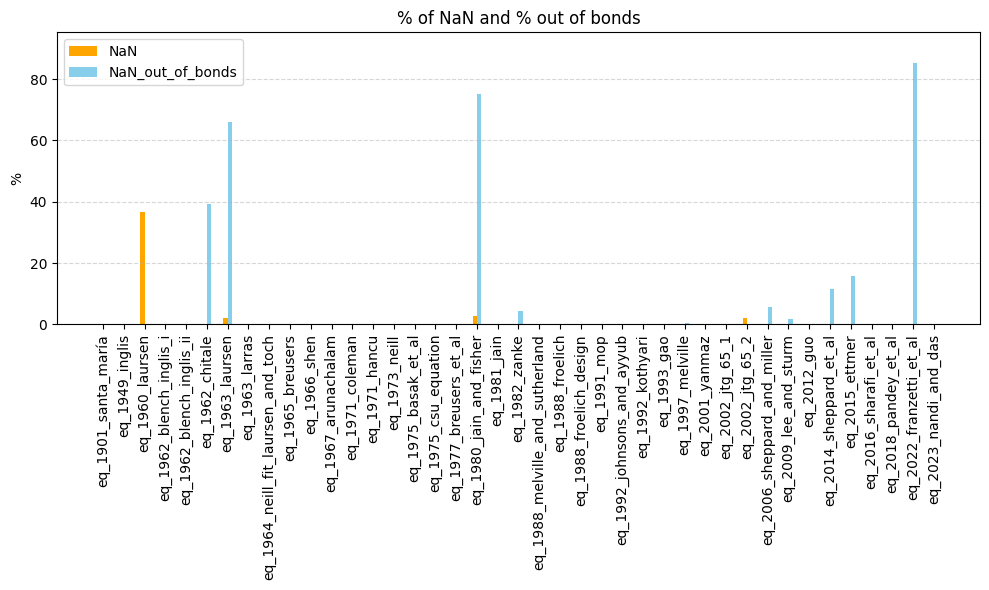

In [1019]:
equations = df_subcritic_cal['equation'].unique()
data = []

for eq in equations:
    df_eq = df_subcritic_cal[df_subcritic_cal['equation'] == eq]
    total = len(df_eq)

    count_nan = df_eq['cal'].isna().sum()
    count_out = (df_eq['cal'] == 'NaN_out_of_bonds').sum()

    pct_nan = (count_nan / total) * 100 if total > 0 else 0
    pct_out = (count_out / total) * 100 if total > 0 else 0

    data.append([eq, pct_nan, pct_out])

df_plot = pd.DataFrame(data, columns=['equation', 'pct_nan', 'pct_out'])

# gráfico de barras agrupadas
x = np.arange(len(df_plot))
width = 0.2

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, df_plot['pct_nan'], width, label='NaN', color='orange')
plt.bar(x + width/2, df_plot['pct_out'], width, label='NaN_out_of_bonds', color='skyblue')

# etiquetas
plt.xticks(x, df_plot['equation'], rotation=90)  # verticales
plt.ylabel('%')
plt.title('% of NaN and % out of bonds')
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0, max(df_plot['pct_nan'].max(), df_plot['pct_out'].max()) + 10)
plt.show()

#display(df_plot)

In [1020]:
# replace 'NaN_out_of_bonds' per NaN
df_subcritic_cal['cal'] = df_subcritic_cal['cal'].replace('NaN_out_of_bonds', np.nan)
df_supercritic_cal['cal'] = df_supercritic_cal['cal'].replace('NaN_out_of_bonds', np.nan)

# calculate dimensionless scour
df_subcritic_cal['cal_dimensionless'] = df_subcritic_cal['cal'] / df_subcritic_cal['b']
df_supercritic_cal['cal_dimensionless'] = df_supercritic_cal['cal'] / df_supercritic_cal['b']

/tmp/ipython-input-790910007.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_subcritic_cal['cal'] = df_subcritic_cal['cal'].replace('NaN_out_of_bonds', np.nan)
/tmp/ipython-input-790910007.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_supercritic_cal['cal'] = df_supercritic_cal['cal'].replace('NaN_out_of_bonds', np.nan)


*  df_subcritic_cal has in **each row** : **one observation** and **one calulation**; total row number is = observations * applied equations

In [1021]:
# Export
df_subcritic_cal.to_csv('data_processed/df_subcritic_cal.csv', index=False)
df_supercritic_cal.to_csv('data_processed/df_supercritic_cal.csv', index=False)

## Equations perfomance assestment

In [1022]:
# Read csv with results of equations
#df_subcritic_cal = pd.read_csv('data_processed/df_subcritic_cal.csv')
#df_supercritic_cal = pd.read_csv('data_processed/df_supercritic_cal.csv')

# Group by the 'equation' column
equations = df_subcritic_cal['equation'].unique()

##### Metrics

In [1023]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def analyze_metrics_for_df(df, equations, output_path):
    metrics_list = []

    for i, equation in enumerate(equations):
        equation_data = df[df['equation'] == equation]
        observed = equation_data['obs_dimensionless']
        calculated = equation_data['cal_dimensionless']

        parts = equation.split('_')
        formatted_title = f"{parts[1]} {' '.join(parts[2:]).title()}"

        mask = ~np.isnan(observed) & ~np.isnan(calculated)
        obs_filtered = observed[mask]
        cal_filtered = calculated[mask]

        if len(obs_filtered) == 0:
            continue

        r2 = r2_score(obs_filtered, cal_filtered)
        mae = mean_absolute_error(obs_filtered, cal_filtered)
        rmse = np.sqrt(mean_squared_error(obs_filtered, cal_filtered))
        mape = np.mean(np.abs((obs_filtered - cal_filtered) / obs_filtered)) * 100

        relative_error = (cal_filtered - obs_filtered) / obs_filtered
        error_over_10 = np.sum(relative_error > 0.10)
        error_within_10 = np.sum(np.abs(relative_error) <= 0.10)
        error_under_10 = np.sum(relative_error < -0.10)
        total = len(relative_error)

        over_pct = 100 * error_over_10 / total
        within_pct = 100 * error_within_10 / total
        under_pct = 100 * error_under_10 / total

        metrics_list.append({
            "Equation": formatted_title,
            "R2": round(r2, 2),
            "MAE": round(mae, 2),
            "RMSE": round(rmse, 2),
            "MAPE (%)": round(mape, 2),
            "> +10%": round(over_pct, 1),
            "±10%": round(within_pct, 1),
            "< -10%": round(under_pct, 1)
        })

    df_metrics = pd.DataFrame(metrics_list)
    df_metrics.to_csv(output_path, index=False)

    print(f"Métricas guardadas en: {output_path}")
    print("\nDataFrame de métricas generado:")
    display(df_metrics)

In [1024]:
# Subcritic
analyze_metrics_for_df(
    df=df_subcritic_cal,
    equations=equations,
    output_path="res/table_metrics_formulas_subcritic.csv"
)

Métricas guardadas en: res/table_metrics_formulas_subcritic.csv

DataFrame de métricas generado:


,Equation,R2,MAE,RMSE,MAPE (%),> +10%,±10%,< -10%
0,1901 Santa María,-17.96,1.66,2.71,185.84,33.4,2.6,64.1
1,1949 Inglis,-17.04,1.85,2.64,187.68,71.4,6.0,22.6
2,1960 Laursen,-2.55,1.03,1.25,200.04,82.6,10.1,7.3
3,1962 Blench Inglis I,-3501.11,23.40,36.81,1492.02,85.3,2.5,12.3
4,1962 Blench Inglis Ii,-28.52,2.44,3.38,179.16,53.7,0.7,45.5
5,1962 Chitale,-88.75,4.40,5.78,621.61,97.2,1.6,1.2
6,1963 Laursen,-0.78,0.72,0.92,77.27,21.5,4.6,73.8
7,1963 Larras,0.06,0.53,0.60,76.45,80.3,10.1,9.6
8,1964 Neill Fit Laursen And Toch,-1.89,0.83,1.06,153.91,82.9,14.0,3.1
9,1965 Breusers,-0.09,0.54,0.65,96.52,54.8,15.4,29.9


In [1025]:
# Supercritic
analyze_metrics_for_df(
    df=df_supercritic_cal,
    equations=equations,
    output_path="res/table_metrics_formulas_supercritic.csv"
)

Métricas guardadas en: res/table_metrics_formulas_supercritic.csv

DataFrame de métricas generado:


,Equation,R2,MAE,RMSE,MAPE (%),> +10%,±10%,< -10%
0,1901 Santa María,-16.31,1.53,2.25,93.35,37.4,7.7,54.9
1,1949 Inglis,-97.86,4.42,5.38,282.83,98.9,1.1,0.0
2,1960 Laursen,-1.14,0.51,0.62,31.57,35.3,17.6,47.1
3,1962 Blench Inglis I,-6541.87,36.88,43.77,2567.95,98.9,0.0,1.1
4,1962 Blench Inglis Ii,-195.83,7.10,7.59,515.59,98.9,0.0,1.1
5,1963 Larras,-1.01,0.60,0.77,62.24,78.0,16.5,5.5
6,1964 Neill Fit Laursen And Toch,0.24,0.36,0.47,30.31,56.0,29.7,14.3
7,1965 Breusers,-0.12,0.43,0.57,34.72,22.0,28.6,49.5
8,1966 Shen,-1130.05,16.08,18.20,1474.41,100.0,0.0,0.0
9,1967 Arunachalam,-2.98,0.94,1.08,61.53,12.1,3.3,84.6


##### Figures

In [1026]:
# --- Determine Global X-axis Limits ---
all_observed_values = df_subcritic_cal['obs_dimensionless'].dropna()
global_x_min = np.floor(all_observed_values.min() * 0.9) if not all_observed_values.empty else 0
global_x_max = np.ceil(all_observed_values.max() * 1.1) if not all_observed_values.empty else 10
if global_x_max - global_x_min < 1:
    global_x_max = global_x_min + 1
print(f"Global X-axis (Observed) Range: [{global_x_min:.2f}, {global_x_max:.2f}]")

Global X-axis (Observed) Range: [0.00, 4.00]


###### Equations results in diferents plots

In [1043]:
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

# --- Define the enhanced plot_results function ---
def plot_results(ax, observed, calculated, title, global_x_min, global_x_max):
    """
    Plots observed vs. calculated values with custom styling,
    error bands, percentage of points within/outside bands,
    and line labels.

    Parameters:
    - ax: The matplotlib axes object to plot on.
    - observed (pd.Series or np.array): The observed (true) values.
    - calculated (pd.Series or np.array): The calculated (predicted) values.
    - title (str): The title for the subplot.
    - global_x_min (float): The minimum limit for the X-axis (global across all plots).
    - global_x_max (float): The maximum limit for the X-axis (global across all plots).
    """
    # Scatter plot
    sns.scatterplot(x=observed, y=calculated, alpha=0.3, ax=ax, edgecolors='black', facecolors='none', s=50)

    # Calculate metrics for percentages
    mask = ~np.isnan(observed) & ~np.isnan(calculated)
    obs_filtered = observed[mask]
    cal_filtered = calculated[mask]

    if len(obs_filtered) == 0:
        ax.set_title(f"{title}\n")
        ax.axis('off')
        return

    relative_error = (cal_filtered - obs_filtered) / obs_filtered
    error_over_10 = np.sum(relative_error > 0.10)
    error_within_10 = np.sum(np.abs(relative_error) <= 0.10)
    error_under_10 = np.sum(relative_error < -0.10)
    total = len(relative_error)

    # Handle division by zero for percentages if total is 0
    if total == 0:
        over_pct = 0
        within_pct = 0
        under_pct = 0
    else:
        over_pct = 100 * error_over_10 / total
        within_pct = 100 * error_within_10 / total
        under_pct = 100 * error_under_10 / total

    # --- Add 10% error lines and fill ---
    line_plot_range = np.linspace(global_x_min, global_x_max, 100)
    ax.plot(line_plot_range, line_plot_range * 1.10, color='black', linestyle=':')
    ax.plot(line_plot_range, line_plot_range * 0.90, color='black', linestyle=':')
    ax.fill_between(line_plot_range, line_plot_range * 0.90, line_plot_range * 1.10, color='gray', alpha=0.2)
    # ----------------------------------------

    ax.set_xlabel('observed', fontsize=8)
    ax.set_ylabel('computed', fontsize=8)

    # Set X-axis limits using the global range
    ax.set_xlim(global_x_min, global_x_max)

    # --- Set Y-axis (starts from 0, min top 4, dynamic upper limit) ---
    current_y_max = cal_filtered.max() if len(cal_filtered) > 0 else 0.1
    current_y_max_padded = max(1.0, np.ceil(current_y_max * 1.1))
    if current_y_max_padded < 4:
        current_y_max_padded = 4
    ax.set_ylim(bottom=0, top=current_y_max_padded)
    # -----------------------------------------------------------------

    ax.xaxis.set_major_locator(MultipleLocator(1))
    y_tick_step = max(1, int(current_y_max_padded / 4))
    if y_tick_step == 0: y_tick_step = 0.5
    ax.yaxis.set_major_locator(MultipleLocator(y_tick_step))

    ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%d'))

    ax.set_title(title, fontsize=14)

    # --- Add text labels for lines and band (no rotation, simplified text) ---
    # Position them slightly before the global_x_max for right alignment
    text_x_pos = global_x_max * 0.85

    # +10% Line label
    ax.text(text_x_pos, text_x_pos * 1.10, '+10%',
            horizontalalignment='right', verticalalignment='bottom',
            color='black', fontsize=9, rotation=0,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    # -10% Line label
    ax.text(text_x_pos, text_x_pos * 0.90, '-10%',
            horizontalalignment='right', verticalalignment='top',
            color='black', fontsize=9, rotation=0,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    # 10% Error Band label
    #band_text_x = (global_x_min + global_x_max) / 2
    #band_text_y = band_text_x # Centered on the 1:1 conceptual line for the band label
    #ax.text(band_text_x, band_text_y, '10% Error Band',
            #horizontalalignment='center', verticalalignment='center',
            #color='gray', fontsize=7, alpha=0.8,
            #bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=1))


    # --- Add percentage text based on band positions ---
    #mid_x_for_pct_text = 3 # Fixed x-position for these percentage labels
    #buffer_y = 0.02 * (current_y_max_padded - 0)

    #ax.text(mid_x_for_pct_text, mid_x_for_pct_text, f'{within_pct:.0f}%',
            #horizontalalignment='center', verticalalignment='center',
            #color='black', fontsize=9, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    #ax.text(mid_x_for_pct_text, mid_x_for_pct_text * 1.10 + buffer_y, f'{over_pct:.0f}%',
           # horizontalalignment='center', verticalalignment='bottom',
           # color='black', fontsize=9, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    #ax.text(mid_x_for_pct_text, mid_x_for_pct_text * 0.90 - buffer_y, f'#{under_pct:.0f}%',
            #horizontalalignment='center', verticalalignment='top',
            #color='black', fontsize=9, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

In [1045]:
def plot_results(ax, observed, calculated, title, global_x_min, global_x_max, equal_aspect=False):
    """
    Plots observed vs. calculated values with custom styling and 10% bands.
    Set equal_aspect=True to force square axes (1:1 aspect) using the global range.
    """
    # Scatter (hollow circles)
    sns.scatterplot(x=observed, y=calculated, alpha=0.7, ax=ax,
                    edgecolors='black', facecolors='none', s=25)

    # Filter NaNs
    mask = ~np.isnan(observed) & ~np.isnan(calculated)
    obs_filtered = observed[mask]
    cal_filtered = calculated[mask]
    if len(obs_filtered) == 0:
        ax.set_title(f"{title}\n")
        ax.axis('off')
        return

    # 10% bands
    line_plot_range = np.linspace(global_x_min, global_x_max, 100)
    ax.plot(line_plot_range, line_plot_range * 1.10, color='black', linestyle=':')
    ax.plot(line_plot_range, line_plot_range * 0.90, color='black', linestyle=':')
    ax.fill_between(line_plot_range, line_plot_range * 0.90, line_plot_range * 1.10,
                    color='gray', alpha=0.2)

    ax.set_xlabel('observed', fontsize=8)
    ax.set_ylabel('computed', fontsize=8)

    # --- Axes limits & aspect ---
    ax.set_xlim(global_x_min, global_x_max)
    if equal_aspect:
        # lock y to the same global range and enforce 1:1 aspect
        ax.set_ylim(global_x_min, global_x_max)
        ax.set_aspect('equal', adjustable='box')
    else:
        # dynamic y upper bound (keeps bottom at 0 as in your original)
        current_y_max = cal_filtered.max() if len(cal_filtered) > 0 else 0.1
        current_y_max_padded = max(1.0, np.ceil(current_y_max * 1.1))
        if current_y_max_padded < 4:
            current_y_max_padded = 4
        ax.set_ylim(bottom=0, top=current_y_max_padded)

    # integer ticks
    ax.xaxis.set_major_locator(MultipleLocator(1))
    # y ticks: if equal_aspect, mirror x step=1; else dynamic step
    if equal_aspect:
        ax.yaxis.set_major_locator(MultipleLocator(1))
    else:
        y_tick_step = max(1, int((ax.get_ylim()[1] - ax.get_ylim()[0]) / 4))
        ax.yaxis.set_major_locator(MultipleLocator(y_tick_step))

    ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%d'))

    ax.set_title(title, fontsize=10)

    # Labels for ±10% lines
    text_x_pos = global_x_max * 0.85
    ax.text(text_x_pos, text_x_pos * 1.10, '+10%',
            ha='right', va='bottom', color='black', fontsize=9,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
    ax.text(text_x_pos, text_x_pos * 0.90, '-10%',
            ha='right', va='top', color='black', fontsize=9,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

In [1071]:
import pandas as pd
import matplotlib.pyplot as plt
import math

def plot_equations(df_to_plot, equations, output_prefix, global_x_min, global_x_max,
                   plots_per_row=4, rows_per_figure_base=6, equal_aspect=False, width=14, height=3):
    """
    Plot only equations that have at least one valid (obs, cal) pair.
    """

    # --- 1) keep only equations with data (no all-NaN) ---
    required_cols = {'equation','obs_dimensionless','cal_dimensionless'}
    if not required_cols.issubset(df_to_plot.columns):
        raise ValueError(f"df_to_plot must contain columns: {required_cols}")

    valid_equations = []
    for eq in equations:
        sub = df_to_plot[df_to_plot['equation'] == eq]
        # **La comprobación principal de que hay datos válidos:**
        if not sub.empty and sub[['obs_dimensionless','cal_dimensionless']].dropna().shape[0] > 0:
            valid_equations.append(eq)

    if not valid_equations:
        print("No equations with valid data to plot.")
        return

    # --- 2) paginate figures based on valid equations only ---
    plots_per_figure = plots_per_row * rows_per_figure_base
    num_equations = len(valid_equations)
    num_figures = math.ceil(num_equations / plots_per_figure)

    figure_num = 1
    for fig_idx in range(num_figures):
        start_eq_idx = fig_idx * plots_per_figure
        end_eq_idx = min((fig_idx + 1) * plots_per_figure, num_equations)
        current_equations = valid_equations[start_eq_idx:end_eq_idx]

        if not current_equations:
            continue

        # rows for this figure
        if fig_idx == num_figures - 1:
            num_plots_last_figure = len(current_equations)
            rows_per_figure = max(1, math.ceil(num_plots_last_figure / plots_per_row))
        else:
            rows_per_figure = rows_per_figure_base

        fig, axes = plt.subplots(rows_per_figure, plots_per_row, figsize=(width, rows_per_figure * height))
        if isinstance(axes, (list, tuple, pd.core.indexes.base.Index)):
            axes = list(axes)
        axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

        for i, equation in enumerate(current_equations):
            ax = axes[i]
            eq_df = df_to_plot[df_to_plot['equation'] == equation]
            # valid pairs only
            eq_df = eq_df[['obs_dimensionless','cal_dimensionless']].dropna()
            observed = eq_df['obs_dimensionless'].values
            calculated = eq_df['cal_dimensionless'].values

            # **NUEVA COMPROBACIÓN DE SEGURIDAD**
            if len(observed) == 0:
                ax.axis('off')
                continue

            # title: robust parsing
            parts = equation.split('_')
            year = parts[1] if len(parts) > 1 else ""
            author_raw = ' '.join(parts[2:]).replace('_', ' ').title() if len(parts) > 2 else parts[0].title()
            author = (author_raw.replace('And', 'and')
                                 .replace('Et Al', 'et al.')
                                 .replace('Ii', 'II')
                                 .replace('Csu', 'CSU')
                                 .replace('Fit', 'fit')
                                 .replace('Mop', 'MOP')
                                 .replace('Jtg', 'JTG')
                                 .replace('65 1', '65-1')
                                 .replace('65 2', '65-2'))
            formatted_title = f"{author} ({year})" if year else author

            plot_results(ax, observed, calculated, formatted_title, global_x_min, global_x_max, equal_aspect)

        # hide unused axes (de las celdas del subplots no utilizadas)
        for j in range(len(current_equations), len(axes)):
            axes[j].axis('off')

        plt.tight_layout()
        out = f"res/{output_prefix}_{figure_num}.png"
        plt.savefig(out, format='png', dpi=1000, bbox_inches='tight')
        plt.show()
        plt.close(fig)
        figure_num += 1

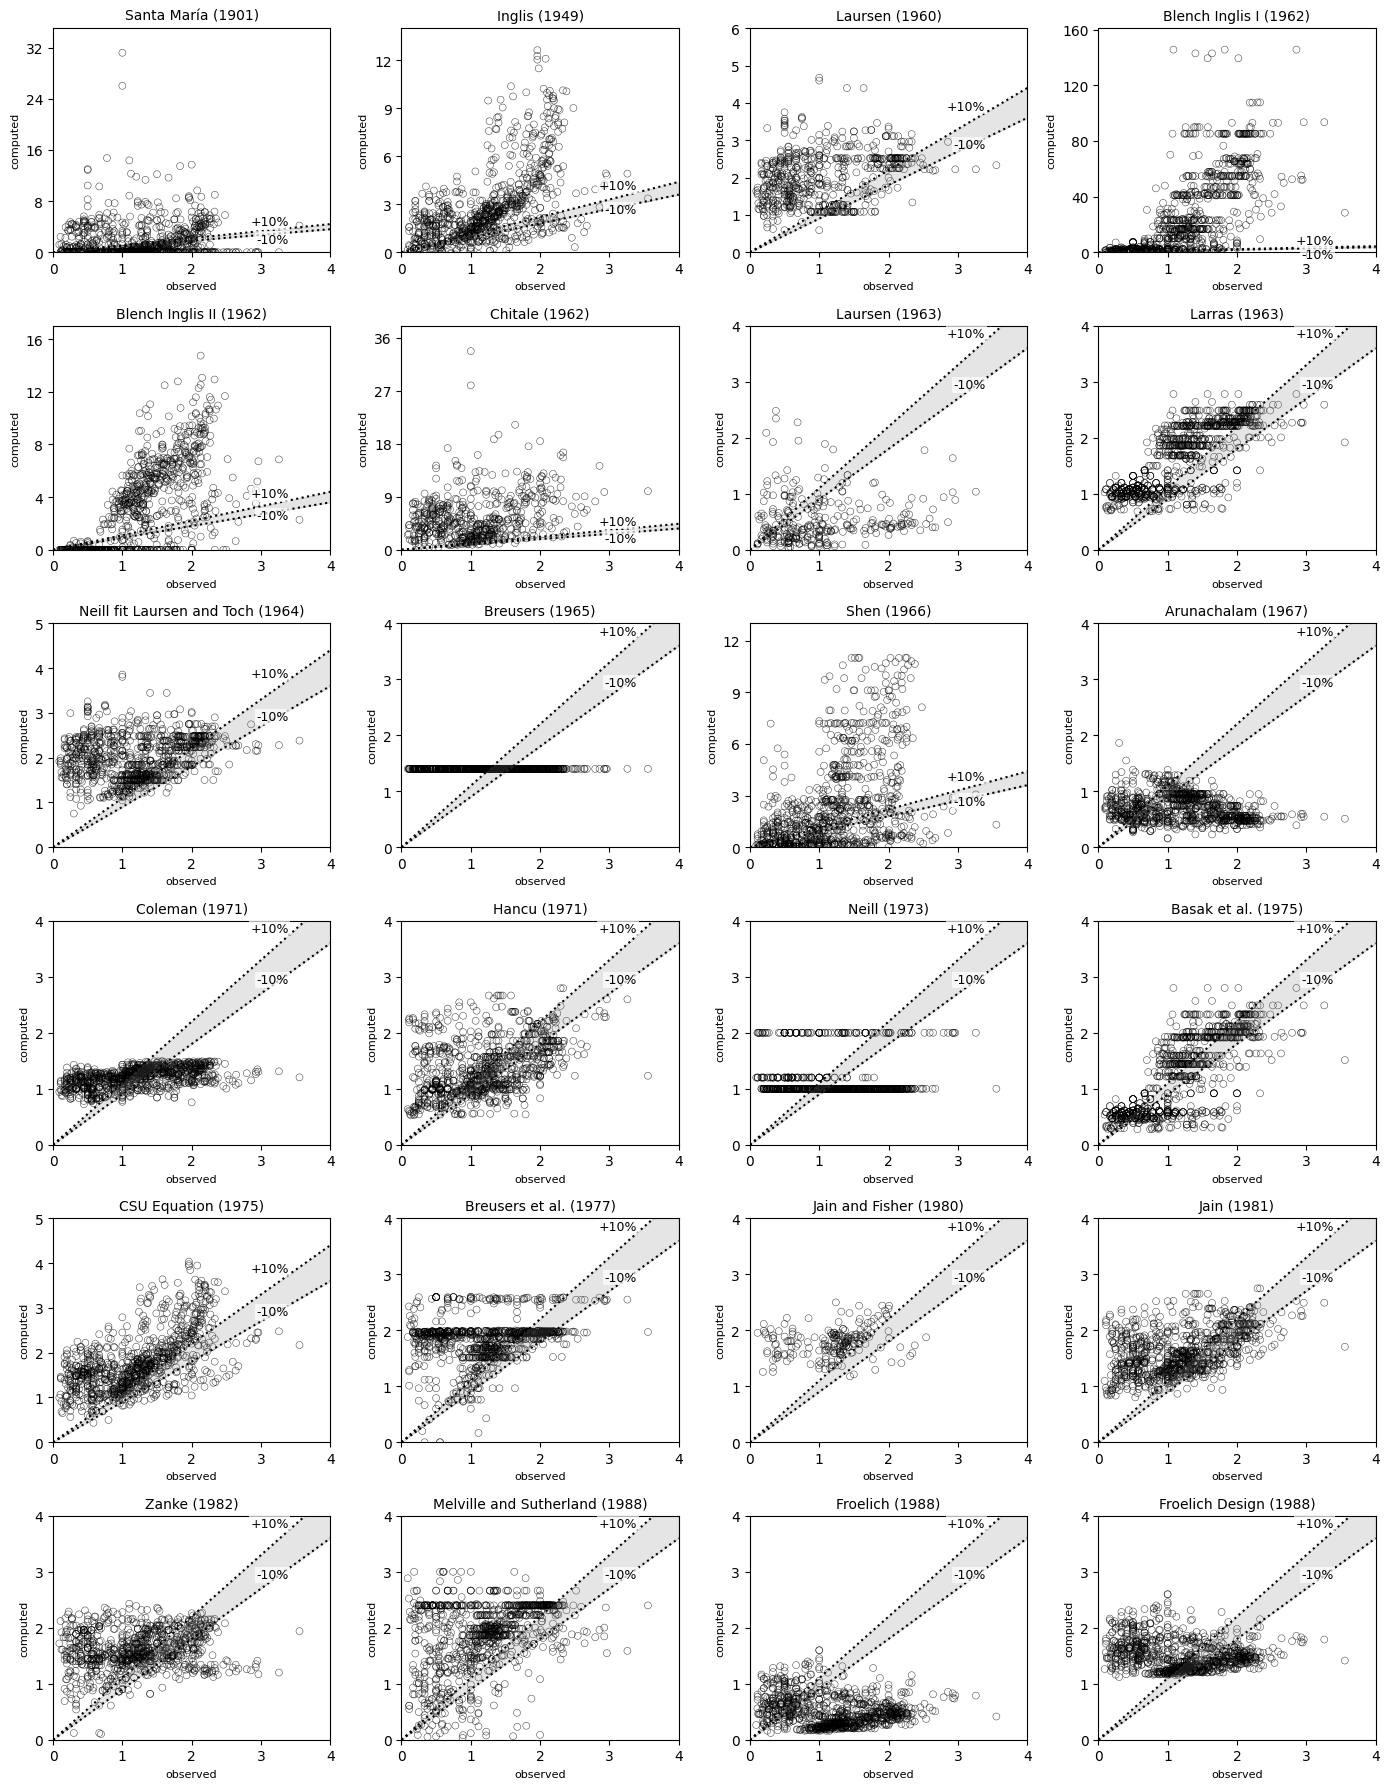

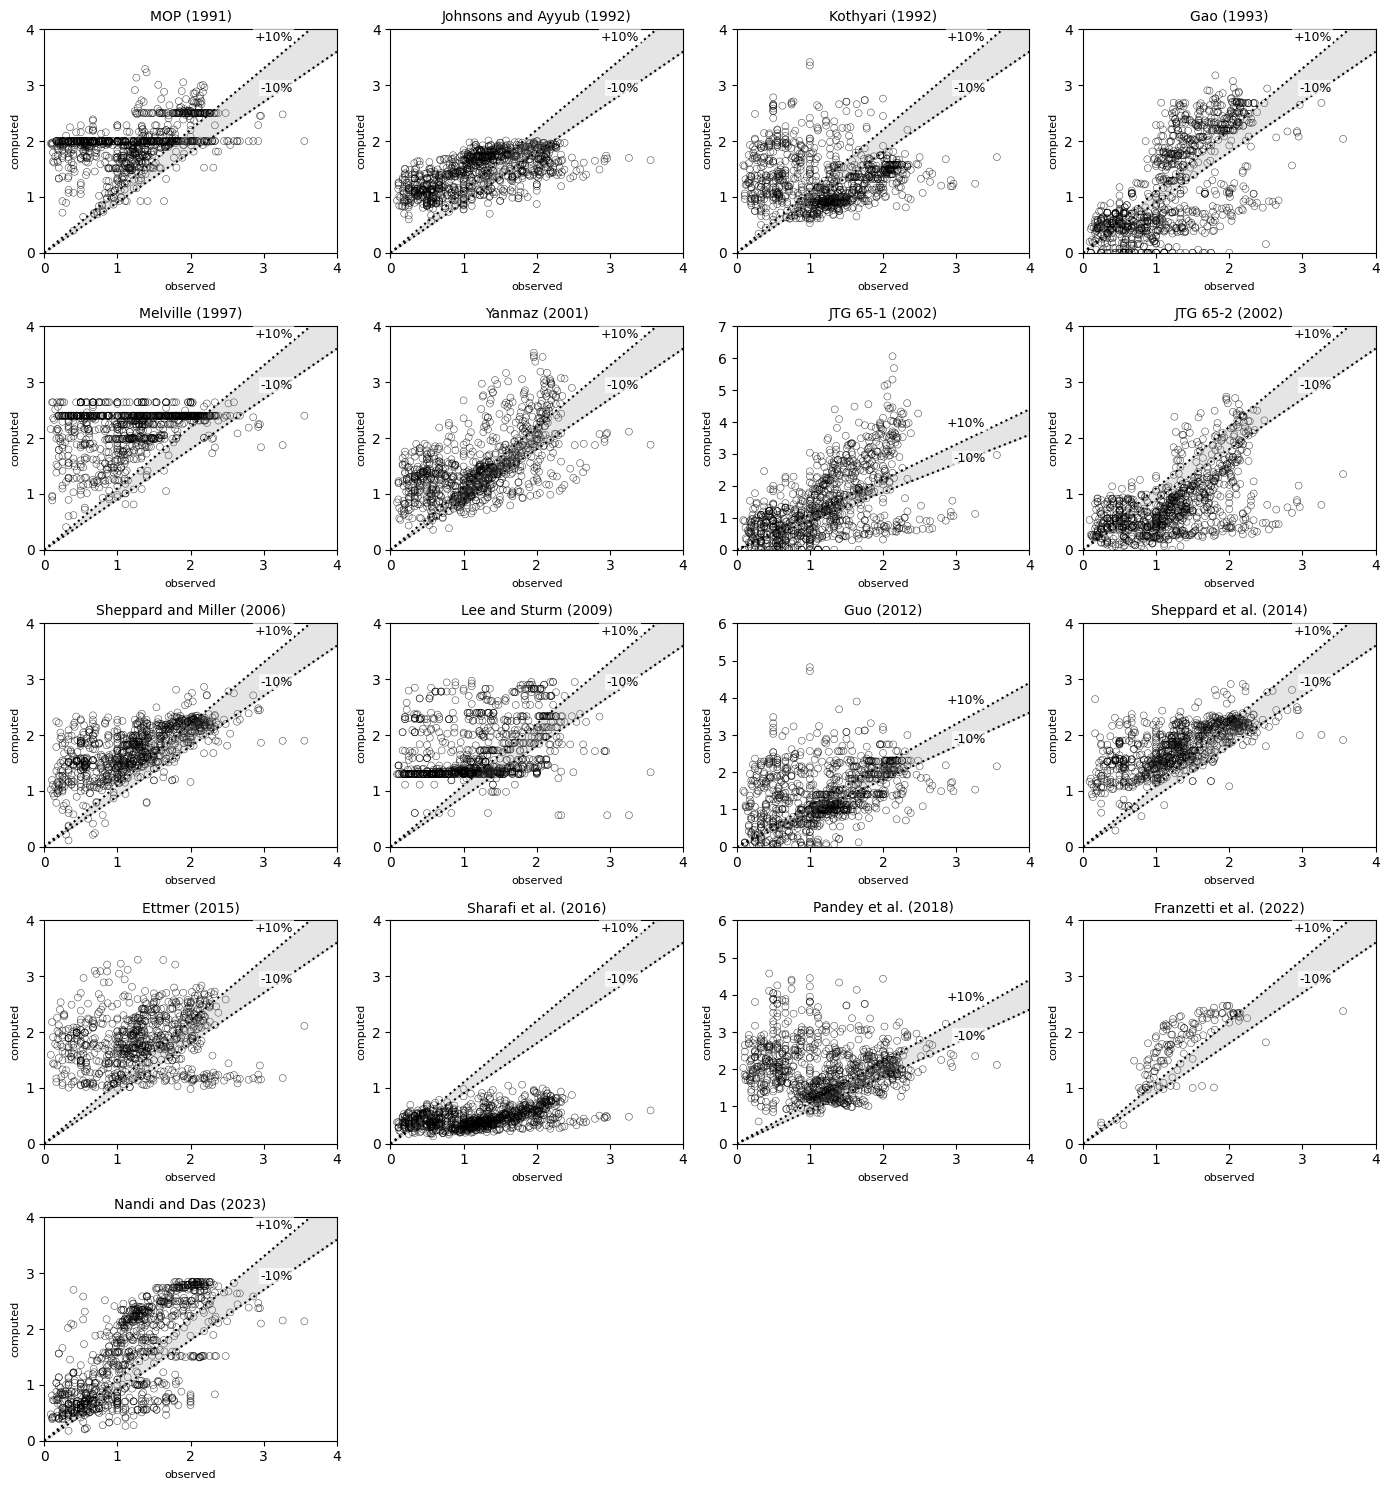

In [1072]:
plot_equations(
    df_to_plot=df_subcritic_cal,
    equations=equations,
    output_prefix="fig_formula_subcritic",
    global_x_min=global_x_min,
    global_x_max=global_x_max
)

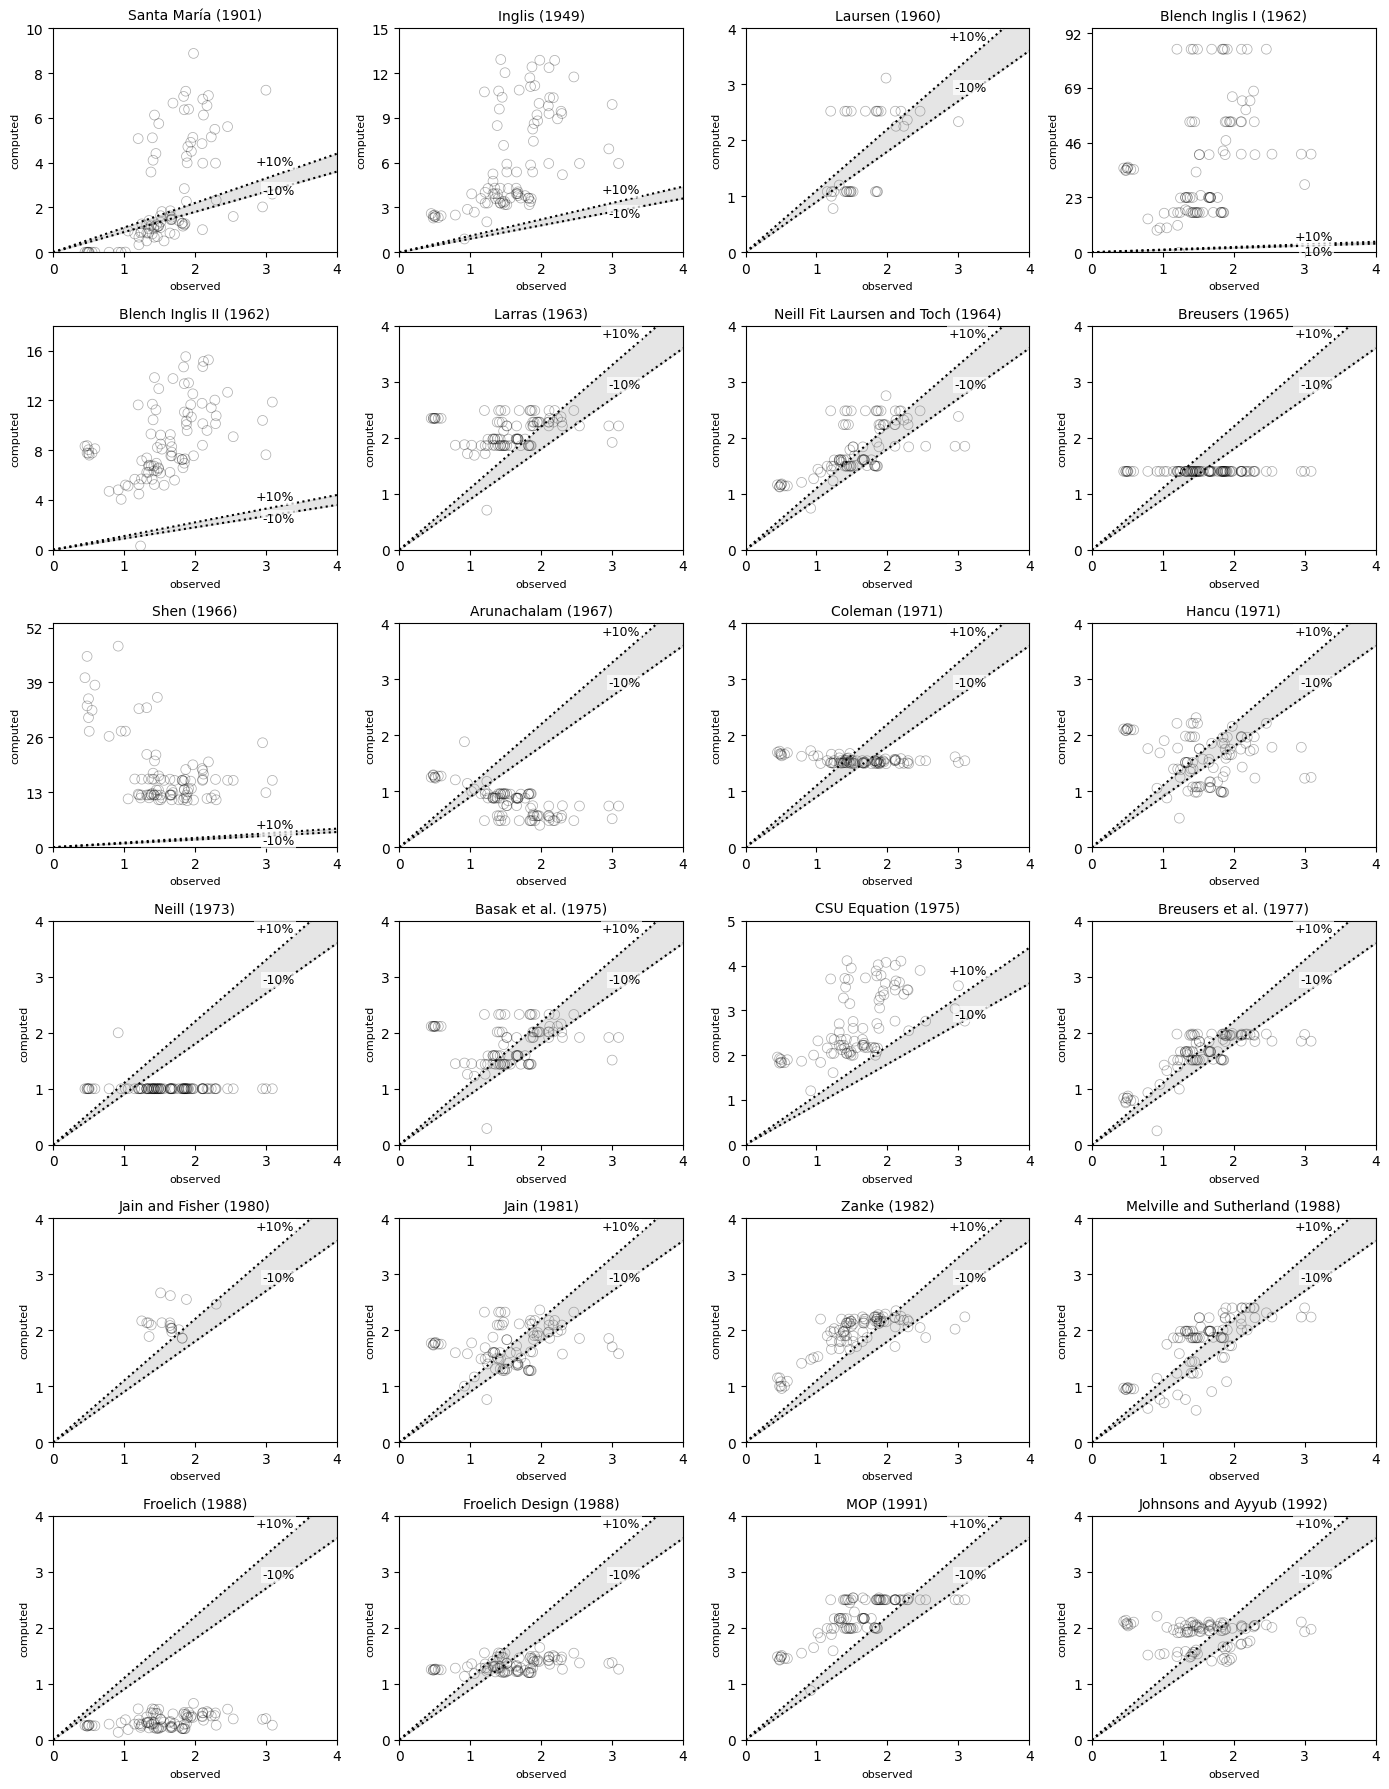

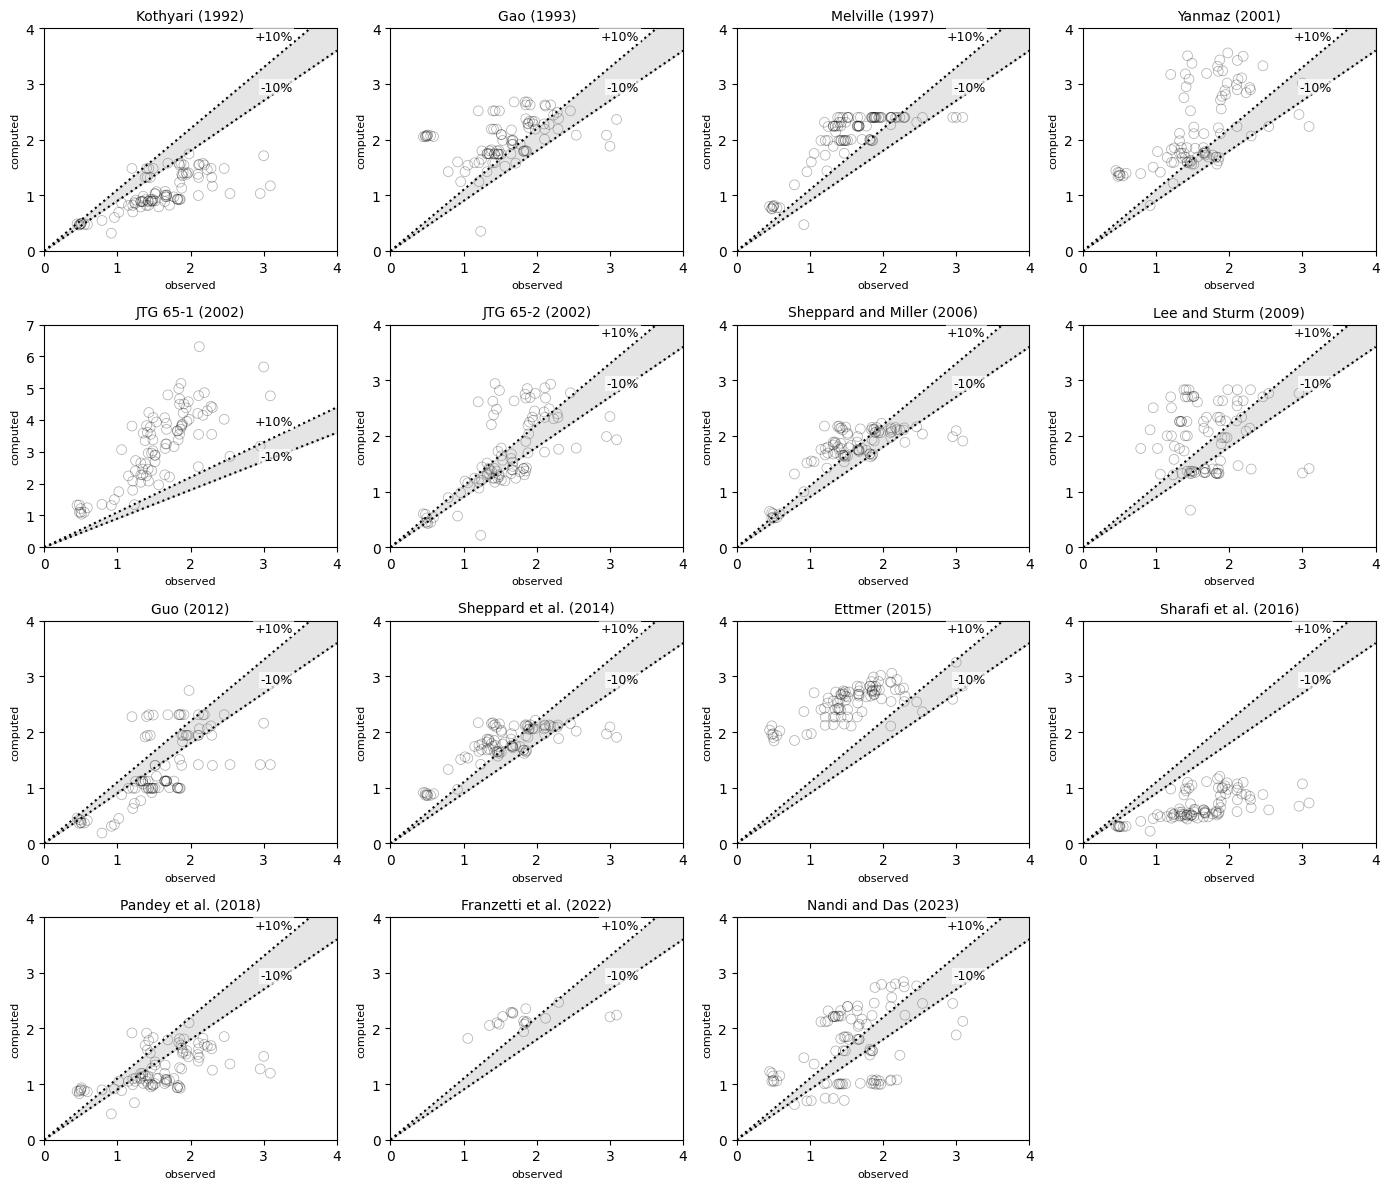

In [1031]:
plot_equations(
    df_to_plot=df_supercritic_cal,
    equations=equations,
    output_prefix="fig_formula_supercritic",
    global_x_min=global_x_min,
    global_x_max=global_x_max
)

###### Equations selected

In [1032]:
def plot_results_V2(
    ax, observed, calculated, title, global_x_min, global_x_max,
    title_fs=12, label_fs=10, tick_fs=9, line_label_fs=9
):
    sns.scatterplot(x=observed, y=calculated, alpha=0.3, ax=ax,
                    edgecolors='black', facecolors='none', s=50)

    mask = ~np.isnan(observed) & ~np.isnan(calculated)
    obs_filtered = observed[mask];  cal_filtered = calculated[mask]
    if len(obs_filtered) == 0:
        ax.set_title(f"{title}\nNo valid data", fontsize=title_fs); ax.axis('off'); return

    relative_error = (cal_filtered - obs_filtered) / obs_filtered
    line_plot_range = np.linspace(global_x_min, global_x_max, 100)
    ax.plot(line_plot_range, line_plot_range*1.10, color='black', linestyle=':')
    ax.plot(line_plot_range, line_plot_range*0.90, color='black', linestyle=':')
    ax.fill_between(line_plot_range, line_plot_range*0.90, line_plot_range*1.10,
                    color='gray', alpha=0.2)

    ax.set_xlabel('Observado', fontsize=label_fs)
    ax.set_ylabel('Calculado', fontsize=label_fs)
    ax.tick_params(axis='both', labelsize=tick_fs)

    ax.set_xlim(global_x_min, global_x_max)
    current_y_max = cal_filtered.max() if len(cal_filtered)>0 else 0.1
    current_y_max_padded = max(4, np.ceil(current_y_max*1.1))
    ax.set_ylim(bottom=0, top=current_y_max_padded)

    ax.xaxis.set_major_locator(MultipleLocator(1))
    y_tick_step = max(1, int(current_y_max_padded/4))
    ax.yaxis.set_major_locator(MultipleLocator(y_tick_step))
    ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%d'))

    ax.set_title(title, fontsize=title_fs)

    text_x_pos = global_x_max * 0.85
    ax.text(text_x_pos, text_x_pos*1.10, '+10%',
            ha='right', va='bottom', fontsize=line_label_fs,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
    ax.text(text_x_pos, text_x_pos*0.90, '-10%',
            ha='right', va='top', fontsize=line_label_fs,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))


In [1033]:
import math
import matplotlib.pyplot as plt
import math
import matplotlib.pyplot as plt

def plot_equations_V2(
    df_to_plot, equations, output_prefix, global_x_min, global_x_max,
    figure_title=None, title_map=None, figure_title_y=0.97,
    # tamaños
    figure_title_size=14, per_axes_title_size=14,
    axis_label_size=12, tick_size=11, line_label_size=11
):
    plots_per_row = 3
    rows_per_figure_base = 6
    plots_per_figure = plots_per_row * rows_per_figure_base

    num_equations = len(equations)
    num_figures = math.ceil(num_equations / plots_per_figure)
    figure_num = 1

    for fig_idx in range(num_figures):
        start_eq_idx = fig_idx * plots_per_figure
        end_eq_idx   = min((fig_idx + 1) * plots_per_figure, num_equations)
        current_equations = equations[start_eq_idx:end_eq_idx]

        # filas dinámicas solo en la última página
        if fig_idx < num_figures - 1:
            rows_per_figure = rows_per_figure_base
        else:
            rows_per_figure = max(1, math.ceil(len(current_equations) / plots_per_row))

        # --- figura y ejes (sin constrained_layout) ---
        fig, axes = plt.subplots(
            rows_per_figure, plots_per_row,
            figsize=(10, rows_per_figure * 3.2)  # un poco más alto para evitar solapes
        )
        axes = axes.flatten()

        # --- título general tipo sgtitle ---
        if figure_title:
            fig.suptitle(figure_title, fontsize=figure_title_size, y=figure_title_y)
            # deja margen para el título
            plt.tight_layout(rect=(0.04, 0.04, 0.98, 0.92))
        else:
            plt.tight_layout()

        # --- dibujar cada ecuación ---
        for i, equation in enumerate(current_equations):
            eqdf = df_to_plot[df_to_plot['equation'] == equation]
            observed = eqdf['obs_dimensionless']
            calculated = eqdf['cal_dimensionless']

            # título individual (permite overrides vía title_map)
            if title_map and equation in title_map:
                formatted_title = title_map[equation]
            else:
                parts = equation.split('_')
                year = parts[1] if len(parts) > 1 else ''
                author_raw = ' '.join(parts[2:]).replace('_', ' ').title()
                author = (author_raw.replace('And', 'and')
                                   .replace('Et Al', 'et al.')
                                   .replace('Fit', 'fit')
                                   .replace('Ii', 'II')
                                   .replace('Csu', 'CSU'))
                formatted_title = (
                    'HEC-18' if ('hec' in equation.lower() and year in ('18', '2018'))
                    else (f"{author} ({year})" if year else author)
                )

            # <<< si tu función se llama plot_results, cambia plot_results_V2 por plot_results >>>
            plot_results_V2(
                axes[i], observed, calculated, formatted_title,
                global_x_min, global_x_max,
                title_fs=per_axes_title_size,
                label_fs=axis_label_size,
                tick_fs=tick_size,
                line_label_fs=line_label_size
            )

        # ocultar ejes sobrantes
        for j in range(len(current_equations), len(axes)):
            axes[j].axis('off')

        # --- limpiar labels repetidos y espaciar subplots ---
        for i, ax in enumerate(axes[:len(current_equations)]):
            row = i // plots_per_row
            col = i %  plots_per_row
            if row < rows_per_figure - 1:   # no es última fila
                ax.set_xlabel('')
            if col > 0:                     # no es primera columna
                ax.set_ylabel('')

        fig.subplots_adjust(hspace=0.35, wspace=0.28)

        # guardar y cerrar
        out = f"results/figures/{output_prefix}_{figure_num}.png"
        fig.savefig(out, format='png', dpi=1000, bbox_inches='tight')
        plt.show()
        plt.close(fig)

        figure_num += 1

In [1034]:
def _format_eq_title(eq_name: str) -> str:
    parts = eq_name.split('_')
    year = parts[1] if len(parts) > 1 else ""
    author_raw = ' '.join(parts[2:]).replace('_', ' ').title() if len(parts) > 2 else parts[0].title()
    author = (author_raw.replace('And', 'and')
                        .replace('Et Al', 'et al.')
                        .replace('Ii', 'II')
                        .replace('Csu', 'CSU')
                        .replace('Neill Fit Laursen And Toch', 'Neill'))
    return f"{author} ({year})" if year else author

def plot_equations_combined(
    df_supercritic_cal, super_eqs,
    df_subcritic_cal,   sub_eqs,
    output_path,
    global_x_min, global_x_max,
    equal_aspect=True,
    width=9, height_per_row=3
):
    ncols = max(len(super_eqs), len(sub_eqs))
    nrows = 2
    fig, axes = plt.subplots(nrows, ncols, figsize=(width, nrows * height_per_row))
    if ncols == 1:
        axes = [[axes[0]], [axes[1]]]
    else:
        axes = [list(axes[0]), list(axes[1])]

    # --- fila 1: SUBCRITICAL (ahora primero) ---
    for j in range(ncols):
        ax = axes[0][j]
        if j < len(sub_eqs):
            eq = sub_eqs[j]
            eq_df = df_subcritic_cal[df_subcritic_cal['equation'] == eq][['obs_dimensionless','cal_dimensionless']].dropna()
            obs = eq_df['obs_dimensionless'].values
            cal = eq_df['cal_dimensionless'].values
            title = _format_eq_title(eq)
            plot_results(ax, obs, cal, title, global_x_min, global_x_max, equal_aspect=equal_aspect)
        else:
            ax.axis('off')

    # --- fila 2: SUPERCRITICAL (después) ---
    for j in range(ncols):
        ax = axes[1][j]
        if j < len(super_eqs):
            eq = super_eqs[j]
            eq_df = df_supercritic_cal[df_supercritic_cal['equation'] == eq][['obs_dimensionless','cal_dimensionless']].dropna()
            obs = eq_df['obs_dimensionless'].values
            cal = eq_df['cal_dimensionless'].values
            title = _format_eq_title(eq)
            plot_results(ax, obs, cal, title, global_x_min, global_x_max, equal_aspect=equal_aspect)
        else:
            ax.axis('off')

    plt.tight_layout()
    plt.savefig(output_path, format='png', dpi=1000, bbox_inches='tight')
    plt.show()
    plt.close(fig)

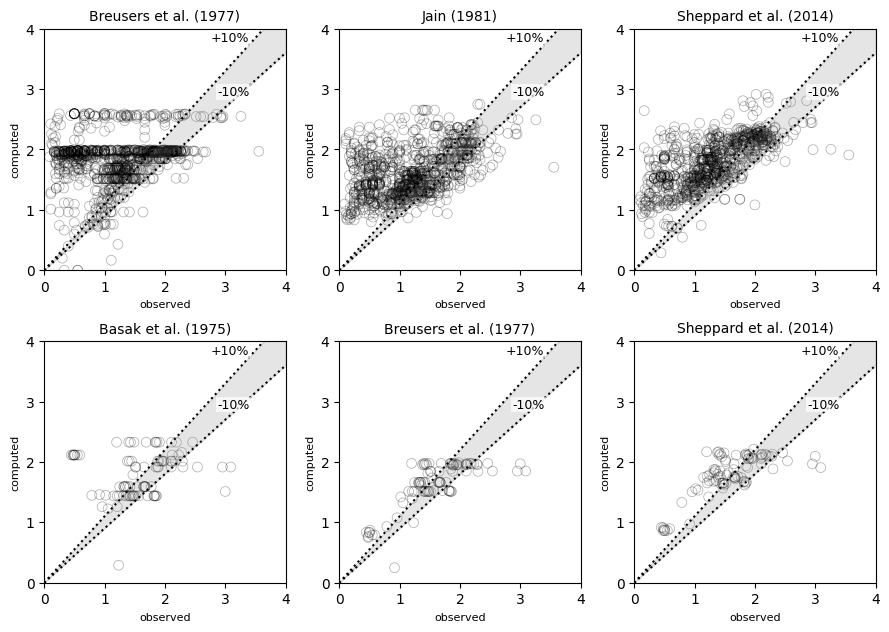

In [1035]:
plot_equations_combined(
    df_subcritic_cal=df_subcritic_cal,
    sub_eqs=[
        'eq_1977_breusers_et_al',
        'eq_1981_jain',
        'eq_2014_sheppard_et_al',
    ],
    df_supercritic_cal=df_supercritic_cal,
    super_eqs=[
        'eq_1975_basak_et_al',
        'eq_1977_breusers_et_al',
        'eq_2014_sheppard_et_al',
    ],
    output_path="results/figures/eq_lead.png",
    global_x_min=global_x_min,
    global_x_max=global_x_max,
    equal_aspect=True,
    width=9,
    height_per_row=3.2
)

###### Equations results combined in one plot

In [1036]:
from matplotlib.ticker import MaxNLocator, MultipleLocator
from matplotlib.lines import Line2D
import math

def plot_all_equations_on_one_plot_combined(df_to_plot, equations, output_prefix, global_x_min, global_x_max, single_color=None, equal_aspect=False):
    fig, ax = plt.subplots(figsize=(6, 5))

    if single_color:
        # Plot all points with the specified single color
        ax.scatter(df_to_plot['obs_dimensionless'], df_to_plot['cal_dimensionless'],
                   s=16, facecolors=single_color, edgecolors='none', alpha=0.8, zorder=1)
    else:
        # --- SUBCRÍTICO: relleno gris
        df_sub = df_to_plot[df_to_plot['reg'] == 'subcritic']
        ax.scatter(df_sub['obs_dimensionless'], df_sub['cal_dimensionless'],
                   s=16, facecolors='#808080', edgecolors='none', alpha=0.8, zorder=1, label='Fr ≤ 1')

        # --- SUPCRÍTICO: círculo vacío con borde negro
        df_sup = df_to_plot[df_to_plot['reg'] == 'supercritic']
        ax.scatter(df_sup['obs_dimensionless'], df_sup['cal_dimensionless'],
                   s=16, facecolors='none', edgecolors='black', linewidths=0.8, alpha=1.0, zorder=2, label='Fr > 1')

    # Línea 1:1 en negro
    ax.plot([global_x_min, global_x_max], [global_x_min, global_x_max],
            color='black', linewidth=1.5, zorder=3, label='1:1')

    # Ejes y ticks (solo enteros)
    xmin, xmax = math.floor(global_x_min), math.ceil(global_x_max)
    ax.set_xlim(xmin, xmax); ax.set_ylim(xmin, xmax)
    # si el rango es pequeño, paso 1; si es grande, usa enteros “bonitos”
    span = xmax - xmin
    if span <= 15:
        ax.xaxis.set_major_locator(MultipleLocator(1))
        ax.yaxis.set_major_locator(MultipleLocator(1))
    else:
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    # Estética similar a tu ejemplo
    ax.grid(True, linestyle=':', linewidth=0.6, alpha=0.4)
    ax.set_xlabel('observed')
    ax.set_ylabel('computed')

    # Línea 1:1 en negro (sin etiqueta)
    # Dibuja la 1:1 una sola vez y sin etiqueta
    ax.plot([global_x_min, global_x_max], [global_x_min, global_x_max],
            color='black', linewidth=1.5, zorder=4, label=None)

    # Leyenda: solo puntos, sin línea
    if not single_color:
        handles = [
            Line2D([0],[0],
                  marker='o', linestyle='None',
                  color='none', markerfacecolor='#808080', markeredgecolor='none',
                  markersize=5, label='$Fr$ ≤ 1'),
            Line2D([0],[0],
                  marker='o', linestyle='None',
                  color='none', markerfacecolor='none', markeredgecolor='black',
                  markersize=5, label='$Fr$ > 1')
        ]
        #ax.legend(handles=handles, loc='lower right', frameon=False)

    if equal_aspect:
        ax.set_aspect('equal', adjustable='box')


    plt.tight_layout()
    # plt.legend(frameon=False)  # ← elimina esta segunda leyenda
    out = f"res/{output_prefix}.png"
    plt.savefig(out, format='png', dpi=1000, bbox_inches='tight')
    plt.show()
    plt.close(fig)

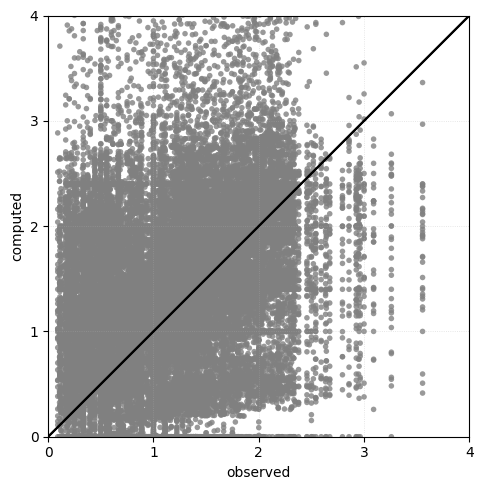

In [1060]:
df_supercritic_cal['reg'] = 'supercritic'
df_subcritic_cal['reg'] = 'subcritic'

df_cal = pd.concat([df_supercritic_cal, df_subcritic_cal], ignore_index=True)

plot_all_equations_on_one_plot_combined(
    df_to_plot=df_cal,
    equations=equations,
    output_prefix="fig_formulas_one_plot",
    global_x_min=global_x_min,
    global_x_max=global_x_max,
    single_color='#808080',
    equal_aspect=True
)

# Machine Learning Models

Predict the scour, training two models with the same dataset but diferents variables: (1) the dataset with hydraulic variables (2) the dataset with the predicted values of scour made by the equations provided

#### Dataset with subcritic flow

In [595]:
# Read csv with results of equations
df_subcritic_cal = pd.read_csv('data_processed/df_subcritic_cal.csv')

In [596]:
# Convert the calculated values by equations in diferents columnns
df_wide = df_subcritic_cal.pivot(index='id', columns='equation', values='cal_dimensionless').add_prefix('cal_').reset_index()

# merge with df
df_subcritic_cal = df.merge(df_wide, on='id')

*   X1: Dataset 1 with columns containing hydraulic variables for calculating
*   X2: Dataset 2 with columns containing calculations of scour

In [597]:
# Dataset 1: hydraulic variables as predictors
X1_subcritic = df_subcritic_cal[['b', 'h', 'v', 'd50','h/vcr','h/b','b/d50','b/h']]

# Dataset 2: outputs from equations as predictors
X2_subcritic = df_subcritic_cal.filter(like='cal')

# Define the target variable
y = df_subcritic_cal['obs_dimensionless']

# display both datasets
print('Dataset 1 (X1) - Hydraulic variables as predictors')
display(X1_subcritic)

print('\nDataset 2 (X2) - Outputs from equations as predictors')
display(X2_subcritic)

Dataset 1 (X1) - Hydraulic variables as predictors


,b,h,v,d50,h/vcr,h/b,b/d50,b/h
0,0.0508,0.102,0.75,0.25,0.430531,2.007874,203.200000,0.498039
1,0.0508,0.102,1.00,0.25,0.430531,2.007874,203.200000,0.498039
2,0.0508,0.102,0.50,1.50,0.228651,2.007874,33.866667,0.498039
3,0.0508,0.102,0.65,1.50,0.228651,2.007874,33.866667,0.498039
4,0.0508,0.102,0.75,1.50,0.228651,2.007874,33.866667,0.498039
...,...,...,...,...,...,...,...,...
933,0.0450,0.240,1.43,0.85,0.694193,5.333333,52.941176,0.187500
934,0.0450,0.240,1.21,0.85,0.694193,5.333333,52.941176,0.187500
935,0.0450,0.240,1.46,0.85,0.694193,5.333333,52.941176,0.187500
936,0.0450,0.340,1.39,0.85,0.983441,7.555556,52.941176,0.132353



Dataset 2 (X2) - Outputs from equations as predictors


,cal_eq_1909_santa_maría,cal_eq_1949_inglis,cal_eq_1960_laursen,cal_eq_1962_blench_inglis_i,cal_eq_1962_blench_inglis_ii,cal_eq_1962_chitale,cal_eq_1963_larras,cal_eq_1963_laursen,cal_eq_1964_neill_fit_laursen_and_toch,cal_eq_1965_breusers,...,cal_eq_2002_jtg_65_2,cal_eq_2006_sheppard_and_miller,cal_eq_2012_guo,cal_eq_2014_lee_and_sturm,cal_eq_2014_sheppard_et_al,cal_eq_2015_ettmer,cal_eq_2016_sharafi_et_al,cal_eq_2018_pandey_et_al,cal_eq_2022_franzetti_et_al,cal_eq_2023_nandi_and_das
0,1.916723,4.221125,NaN,41.178673,8.964363,NaN,2.211686,NaN,1.848895,1.4,...,1.448642,1.873079,1.416995,1.412991,1.872851,2.356332,0.583265,1.378298,2.247726,2.127817
1,2.369770,5.226257,NaN,41.178673,10.661774,NaN,2.211686,NaN,1.848895,1.4,...,1.747896,1.893545,1.416995,1.412991,1.893169,2.644014,0.667709,1.263606,2.247726,2.127817
2,0.000000,3.037005,NaN,41.178673,5.153241,4.903871,2.211686,NaN,1.848895,1.4,...,0.769101,2.144081,1.362367,2.765981,2.131877,1.491763,0.399358,1.772350,NaN,2.448480
3,0.000000,3.774435,NaN,41.178673,6.157054,NaN,2.211686,NaN,1.848895,1.4,...,1.084085,2.120341,1.413298,2.765981,2.107294,1.754127,0.451769,1.637339,NaN,2.448480
4,0.316709,4.221125,NaN,41.178673,6.762665,NaN,2.211686,NaN,1.848895,1.4,...,1.256653,2.104514,1.416585,2.765981,2.090906,1.897228,0.483199,1.568086,NaN,2.448480
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
933,6.220713,9.610665,NaN,59.786855,8.905884,NaN,2.279744,NaN,2.478511,1.4,...,2.387005,2.178153,2.309401,2.335925,2.159102,2.668058,0.850062,1.874723,NaN,2.800347
934,5.550886,8.367294,NaN,59.786855,7.764842,NaN,2.279744,NaN,2.478511,1.4,...,2.193413,2.221396,2.309401,2.335925,2.205513,2.501004,0.785872,1.971729,NaN,2.800347
935,6.296412,9.772878,NaN,59.786855,9.054471,NaN,2.279744,NaN,2.478511,1.4,...,2.410082,2.172257,2.309401,2.335925,2.152773,2.688820,0.858398,1.863005,NaN,2.800347
936,8.662487,10.093398,3.111111,65.317263,6.483099,NaN,2.279744,NaN,2.751511,1.4,...,2.481421,2.238016,2.748737,2.335925,2.221771,2.586984,0.897753,2.199420,NaN,2.800347


#### Dataset with supercritic flow

In [598]:
# Read csv with results of equations
df_supercritic_cal = pd.read_csv('data_processed/df_supercritic_cal.csv')

In [599]:
# convert the calculated values by equations in diferents columnns
df_wide = df_supercritic_cal.pivot(index='id', columns='equation', values='cal_dimensionless').add_prefix('cal_').reset_index()

# merge with df
df_supercritic_cal = df.merge(df_wide, on='id')

In [600]:
# Define test sets for supercritical flows (Froude > 1)
X1_supercritic_test = df_supercritic_cal[['b', 'h', 'v', 'd50','h/vcr','h/b','b/d50','b/h']]
X2_supercritic_test = df_supercritic_cal.filter(like='cal')
y_supercritic_test = df_supercritic_cal['obs_dimensionless']

### Train and Test

*   Train with subcritic data
*   Test with subcritic data
*   Test with supercritic data



In [601]:
results_test_subcritic = []
results_supercritic_test = []
seed = 42
np.random.seed(seed)

In [602]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from sklearn.base import BaseEstimator
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


class RegressorSwitcher(BaseEstimator):
    def __init__(self, estimator=RandomForestRegressor()):
        self.estimator = estimator
    def fit(self, X, y=None, **kwargs):
        self.estimator.fit(X, y)
        return self
    def predict(self, X):
        return self.estimator.predict(X)
    def score(self, X, y):
        return self.estimator.score(X, y)

def evaluate_model(model, X_test, y_test, dataset_name='X'):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    relative_error = (y_pred - y_test) / y_test
    total = len(relative_error)

    error_over_10 = np.sum(relative_error > 0.10)
    error_within_10 = np.sum(np.abs(relative_error) <= 0.10)
    error_under_10 = np.sum(relative_error < -0.10)

    over_pct = 100 * error_over_10 / total
    within_pct = 100 * error_within_10 / total
    under_pct = 100 * error_under_10 / total

    print(f'\n[RESULTADOS para {dataset_name}]')
    print(f'R2: {r2:.3f}, RMSE: {rmse:.3f}, MAE: {mae:.3f}')
    return {
        'dataset': dataset_name,
        'y_pred': y_pred,
        'r2': r2,
        'rmse': rmse,
        'mae': mae,
        'mape': mape,
        '> +10%': over_pct,
        '±10%': within_pct,
        '< -10%': under_pct
    }


In [603]:
from skopt.space import Real, Integer, Categorical
from skopt import BayesSearchCV


def train_model(X_train, y_train, model_type='rf', seed=seed):
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('reg', RegressorSwitcher())
    ])

    if model_type == 'rf':
        # Define el espacio de búsqueda para Bayesiana
        search_spaces = {
            'reg__estimator': [RandomForestRegressor(criterion='squared_error', random_state=seed)],
            'reg__estimator__n_estimators': Integer(10, 700),
            'reg__estimator__max_depth': Integer(2, 16),
            'reg__estimator__min_samples_split': Integer(5, 20),
            'reg__estimator__min_samples_leaf': Integer(5, 20),
            'reg__estimator__max_features': Categorical(['sqrt', 'log2']),
        }

    elif model_type == 'xgb':
        # Define el espacio de búsqueda para Bayesiana
        search_spaces = {
            'reg__estimator': [XGBRegressor(objective='reg:squarederror', random_state=seed)],
            'reg__estimator__n_estimators': Integer(10, 750),
            'reg__estimator__max_depth': Integer(2, 12),
            'reg__estimator__learning_rate': Real(0.01, 0.1, 'log-uniform'),
            'reg__estimator__subsample': Real(0.5, 0.7),
            'reg__estimator__colsample_bytree': Real(0.5, 0.7),
            'reg__estimator__gamma': Real(0.3, 1),
            'reg__estimator__reg_alpha': Real(0.01, 2, 'log-uniform'),
            'reg__estimator__reg_lambda': Real(0.01, 2, 'log-uniform'),
            'reg__estimator__min_child_weight': Integer(5, 10)
        }

    cv = KFold(n_splits=5, shuffle=True, random_state=seed)

    # Reemplaza RandomizedSearchCV por BayesSearchCV
    bayes_search = BayesSearchCV(
        pipeline,
        search_spaces,
        n_iter=5,
        cv=cv,
        scoring='r2',
        n_jobs=-1,
        verbose=1,
        random_state=seed
    )

    bayes_search.fit(X_train, y_train)

    print(f'Mejores parámetros para {model_type}:', bayes_search.best_params_)
    return bayes_search

In [604]:
from joblib import dump
import os

best_avg_r2 = -1  # Inicializa con un valor muy bajo
best_run_number = -1
best_run_results = {}  # Diccionario para guardar solo los mejores resultados
best_run_models = {}
best_run_params = {}

os.makedirs("models", exist_ok=True)

for run in range(2):
    print(f'\n>>> RUN {run+1} <<<')
    seed = seed + run

    # Split data into training and testing sets using indices
    train_idx, test_idx = train_test_split(df_subcritic_cal.index, test_size=0.25, random_state=seed)

    # Apply the same split to both datasets
    X1_subcritic_train, X1_subcritic_test = X1_subcritic.loc[train_idx], X1_subcritic.loc[test_idx]
    X2_subcritic_train, X2_subcritic_test = X2_subcritic.loc[train_idx], X2_subcritic.loc[test_idx]
    y_subcritic_train, y_subcritic_test = y.loc[train_idx], y.loc[test_idx]

    # Convert to numpy arrays
    X1_subcritic_train_np = X1_subcritic_train.to_numpy()
    X1_subcritic_test_np = X1_subcritic_test.to_numpy()
    X2_subcritic_train_np = X2_subcritic_train.to_numpy()
    X2_subcritic_test_np = X2_subcritic_test.to_numpy()
    y_subcritic_train_np = y_subcritic_train.to_numpy()
    y_subcritic_test_np = y_subcritic_test.to_numpy()

    # Ensure supercritic test data is in numpy format
    X1_supercritic_test_np = X1_supercritic_test.to_numpy()
    X2_supercritic_test_np = X2_supercritic_test.to_numpy()
    y_supercritic_test_np = y_supercritic_test.to_numpy()

    # --- Random Forest - X1 ---
    fitted_search_rf_X1 = train_model(X1_subcritic_train_np, y_subcritic_train_np, model_type='rf', seed=seed)
    model_rf_X1 = fitted_search_rf_X1.best_estimator_
    results_rf_X1_train = evaluate_model(model_rf_X1, X1_subcritic_train_np, y_subcritic_train_np, dataset_name=f'RF_X1_subcritic_train_run_{run+1}')
    results_test_subcritic.append(results_rf_X1_train)
    results_rf_X1_test = evaluate_model(model_rf_X1, X1_subcritic_test_np, y_subcritic_test_np, dataset_name=f'RF_X1_subcritic_test_run_{run+1}')
    results_test_subcritic.append(results_rf_X1_test)
    results_rf_X1_supercritic_test = evaluate_model(model_rf_X1, X1_supercritic_test_np, y_supercritic_test_np, dataset_name=f'RF_X1_supercritic_test_run_{run+1}')
    results_supercritic_test.append(results_rf_X1_supercritic_test)

    # --- XGB - X1 ---
    fitted_search_xgb_X1 = train_model(X1_subcritic_train_np, y_subcritic_train_np, model_type='xgb', seed=seed)
    model_xgb_X1 = fitted_search_xgb_X1.best_estimator_
    results_xgb_X1_train = evaluate_model(model_xgb_X1, X1_subcritic_train_np, y_subcritic_train_np, dataset_name=f'XGB_X1_subcritic_train_run_{run+1}')
    results_test_subcritic.append(results_xgb_X1_train)
    results_xgb_X1_test = evaluate_model(model_xgb_X1, X1_subcritic_test_np, y_subcritic_test_np, dataset_name=f'XGB_X1_subcritic_test_run_{run+1}')
    results_test_subcritic.append(results_xgb_X1_test)
    results_xgb_X1_supercritic_test = evaluate_model(model_xgb_X1, X1_supercritic_test_np, y_supercritic_test_np, dataset_name=f'XGB_X1_supercritic_test_run_{run+1}')
    results_supercritic_test.append(results_xgb_X1_supercritic_test)

    # --- Random Forest - X2 ---
    fitted_search_rf_X2 = train_model(X2_subcritic_train_np, y_subcritic_train_np, model_type='rf', seed=seed)
    model_rf_X2 = fitted_search_rf_X2.best_estimator_
    results_rf_X2_train = evaluate_model(model_rf_X2, X2_subcritic_train_np, y_subcritic_train_np, dataset_name=f'RF_X2_subcritic_train_run_{run+1}')
    results_test_subcritic.append(results_rf_X2_train)
    results_rf_X2_test = evaluate_model(model_rf_X2, X2_subcritic_test_np, y_subcritic_test_np, dataset_name=f'RF_X2_subcritic_test_run_{run+1}')
    results_test_subcritic.append(results_rf_X2_test)
    results_rf_X2_supercritic_test = evaluate_model(model_rf_X2, X2_supercritic_test_np, y_supercritic_test_np, dataset_name=f'RF_X2_supercritic_test_run_{run+1}')
    results_supercritic_test.append(results_rf_X2_supercritic_test)

    # --- XGB - X2 ---
    fitted_search_xgb_X2 = train_model(X2_subcritic_train_np, y_subcritic_train_np, model_type='xgb', seed=seed)
    model_xgb_X2 = fitted_search_xgb_X2.best_estimator_
    results_xgb_X2_train = evaluate_model(model_xgb_X2, X2_subcritic_train_np, y_subcritic_train_np, dataset_name=f'XGB_X2_subcritic_train_run_{run+1}')
    results_test_subcritic.append(results_xgb_X2_train)
    results_xgb_X2_test = evaluate_model(model_xgb_X2, X2_subcritic_test_np, y_subcritic_test_np, dataset_name=f'XGB_X2_subcritic_test_run_{run+1}')
    results_test_subcritic.append(results_xgb_X2_test)
    results_xgb_X2_supercritic_test = evaluate_model(model_xgb_X2, X2_supercritic_test_np, y_supercritic_test_np, dataset_name=f'XGB_X2_supercritic_test_run_{run+1}')
    results_supercritic_test.append(results_xgb_X2_supercritic_test)


    # R2
    r2_values = [
        results_rf_X1_test['r2'],
        results_xgb_X1_test['r2'],
        results_rf_X2_test['r2'],
        results_xgb_X2_test['r2']
    ]
    avg_r2_current_run = sum(r2_values) / len(r2_values)
    print(f"Promedio de R2 para la ejecución {run+1}: {avg_r2_current_run:.4f}")

    # Compare and save ---
    if avg_r2_current_run > best_avg_r2:
        best_avg_r2 = avg_r2_current_run
        best_run_number = run + 1

        # Guarda modelos (objetos ya ajustados con sus mejores hiperparámetros)
        best_run_models = {
            "rf_X1":  model_rf_X1,
            "xgb_X1": model_xgb_X1,
            "rf_X2":  model_rf_X2,
            "xgb_X2": model_xgb_X2,
        }

        # Guarda hiperparámetros óptimos
        best_run_params = {
            "rf_X1":  fitted_search_rf_X1.best_params_,
            "xgb_X1": fitted_search_xgb_X1.best_params_,
            "rf_X2":  fitted_search_rf_X2.best_params_,
            "xgb_X2": fitted_search_xgb_X2.best_params_,
        }

        # Guarda métricas (ejemplo)
        best_run_results = {
            "rf_X1_test":  results_rf_X1_test,
            "xgb_X1_test": results_xgb_X1_test,
            "rf_X2_test":  results_rf_X2_test,
            "xgb_X2_test": results_xgb_X2_test,
            "avg_r2":      best_avg_r2,
            "run":         best_run_number,
        }

        # (opcional) persistir a disco
        for name, model in best_run_models.items():
            dump(model, f"models/{name}_run{best_run_number}.joblib")
        with open(f"models/best_params_run{best_run_number}.txt", "w") as f:
            for k, v in best_run_params.items():
                f.write(f"{k}: {v}\n")

print("Mejor run:", best_run_number, "| R2 medio:", best_avg_r2)


>>> RUN 1 <<<
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Mejores parámetros para rf: OrderedDict({'reg__estimator': RandomForestRegressor(random_state=42), 'reg__estimator__max_depth': 12, 'reg__estimator__max_features': 'log2', 'reg__estimator__min_samples_leaf': 10, 'reg__estimator__min_samples_split': 15, 'reg__estimator__n_estimators': 296})

[RESULTADOS para RF_X1_subcritic_train_run_1]
R2: 0.772, RMSE: 0.299, MAE: 0.213

[RESULTADOS para RF_X1_subcritic_test_run_1]
R2: 0.755, RMSE: 0.298, MAE: 0.228

[RESULTADOS para RF_X1_supercritic_test_run_1]
R2: 0.421, RMSE: 0.412, MAE: 0.290
Fitting 5 folds for each of 1 candidates, totalling 5 fits


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Mejores parámetros para xgb: OrderedDict({'reg__estimator': XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
         

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Mejores parámetros para rf: OrderedDict({'reg__estimator': RandomForestRegressor(random_state=42), 'reg__estimator__max_depth': 12, 'reg__estimator__max_features': 'log2', 'reg__estimator__min_samples_leaf': 10, 'reg__estimator__min_samples_split': 15, 'reg__estimator__n_estimators': 296})

[RESULTADOS para RF_X2_subcritic_train_run_1]
R2: 0.824, RMSE: 0.263, MAE: 0.185

[RESULTADOS para RF_X2_subcritic_test_run_1]
R2: 0.773, RMSE: 0.287, MAE: 0.216

[RESULTADOS para RF_X2_supercritic_test_run_1]
R2: 0.550, RMSE: 0.363, MAE: 0.265
Fitting 5 folds for each of 1 candidates, totalling 5 fits


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Mejores parámetros para xgb: OrderedDict({'reg__estimator': XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
         

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(



>>> RUN 2 <<<
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Mejores parámetros para rf: OrderedDict({'reg__estimator': RandomForestRegressor(random_state=43), 'reg__estimator__max_depth': 10, 'reg__estimator__max_features': 'log2', 'reg__estimator__min_samples_leaf': 11, 'reg__estimator__min_samples_split': 18, 'reg__estimator__n_estimators': 321})

[RESULTADOS para RF_X1_subcritic_train_run_2]
R2: 0.788, RMSE: 0.286, MAE: 0.204

[RESULTADOS para RF_X1_subcritic_test_run_2]
R2: 0.635, RMSE: 0.379, MAE: 0.276

[RESULTADOS para RF_X1_supercritic_test_run_2]
R2: 0.443, RMSE: 0.404, MAE: 0.286


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Mejores parámetros para xgb: OrderedDict({'reg__estimator': XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constrai

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Mejores parámetros para rf: OrderedDict({'reg__estimator': RandomForestRegressor(random_state=43), 'reg__estimator__max_depth': 10, 'reg__estimator__max_features': 'log2', 'reg__estimator__min_samples_leaf': 11, 'reg__estimator__min_samples_split': 18, 'reg__estimator__n_estimators': 321})

[RESULTADOS para RF_X2_subcritic_train_run_2]
R2: 0.828, RMSE: 0.257, MAE: 0.182

[RESULTADOS para RF_X2_subcritic_test_run_2]
R2: 0.689, RMSE: 0.349, MAE: 0.255

[RESULTADOS para RF_X2_supercritic_test_run_2]
R2: 0.538, RMSE: 0.368, MAE: 0.267
Fitting 5 folds for each of 1 candidates, totalling 5 fits


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Mejores parámetros para xgb: OrderedDict({'reg__estimator': XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
         

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


### Feature importance

In [1073]:
# columnas usadas por cada modelo
cols_X1 = X1_subcritic_train.columns.tolist()
cols_X2 = X2_subcritic_train.columns.tolist()
print(cols_X1)
print(cols_X2)

['b', 'h', 'v', 'd50', 'h/vcr', 'h/b', 'b/d50', 'b/h']
['cal_eq_1909_santa_maría', 'cal_eq_1949_inglis', 'cal_eq_1960_laursen', 'cal_eq_1962_blench_inglis_i', 'cal_eq_1962_blench_inglis_ii', 'cal_eq_1962_chitale', 'cal_eq_1963_larras', 'cal_eq_1963_laursen', 'cal_eq_1964_neill_fit_laursen_and_toch', 'cal_eq_1965_breusers', 'cal_eq_1966_shen', 'cal_eq_1967_arunachalam', 'cal_eq_1971_coleman', 'cal_eq_1971_hancu', 'cal_eq_1973_neill', 'cal_eq_1975_basak_et_al', 'cal_eq_1975_csu_equation', 'cal_eq_1977_breusers_et_al', 'cal_eq_1980_jain_and_fisher', 'cal_eq_1981_jain', 'cal_eq_1982_zanke', 'cal_eq_1988_froelich', 'cal_eq_1988_froelich_design', 'cal_eq_1988_melville_and_sutherland', 'cal_eq_1991_mop', 'cal_eq_1992_johnsons_and_ayyub', 'cal_eq_1992_kothyari', 'cal_eq_1993_gao', 'cal_eq_1997_melville', 'cal_eq_2001_yanmaz', 'cal_eq_2002_jtg_65_1', 'cal_eq_2002_jtg_65_2', 'cal_eq_2006_sheppard_and_miller', 'cal_eq_2012_guo', 'cal_eq_2014_lee_and_sturm', 'cal_eq_2014_sheppard_et_al', 'cal_eq_2

In [1083]:
import shap
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

shap.initjs()

shap_results = {}

for name, model in best_run_models.items():
    print(f"\nprocesando: {name}")

    reg = model.named_steps["reg"].estimator
    if "X1" in name:
        X_data, cols = X1_subcritic_train, cols_X1
    else:
        X_data, cols = X2_subcritic_train, cols_X2

    scaler = model.named_steps["scaler"]
    X_scaled = scaler.transform(X_data)

    if not isinstance(reg, (RandomForestRegressor, XGBRegressor)):
        print("modelo no compatible con treeexplainer")
        continue

    try:
        explainer = shap.TreeExplainer(reg)
        shap_vals = explainer.shap_values(X_scaled)
        if isinstance(shap_vals, list):
            shap_vals = shap_vals[1]

        shap_results[name] = {
            "explainer": explainer,
            "shap_values": shap_vals,
            "X": X_data,
            "cols": cols
        }
        print("shap listo")

    except Exception as e:
        print("error:", e)


procesando: rf_X1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


shap listo

procesando: xgb_X1
shap listo

procesando: rf_X2


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


shap listo

procesando: xgb_X2
shap listo


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(



graficando: rf_X1


/tmp/ipython-input-1492566060.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X[cols], show=False, max_display=len(cols))


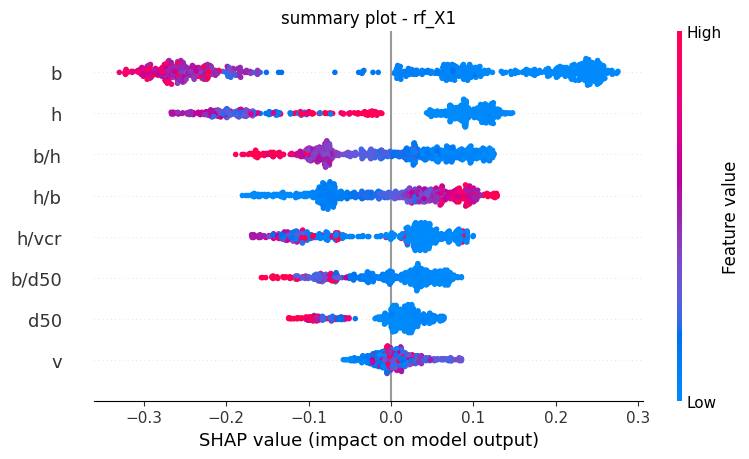

/tmp/ipython-input-1492566060.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X[cols], plot_type="bar", max_display=len(cols), show=False)


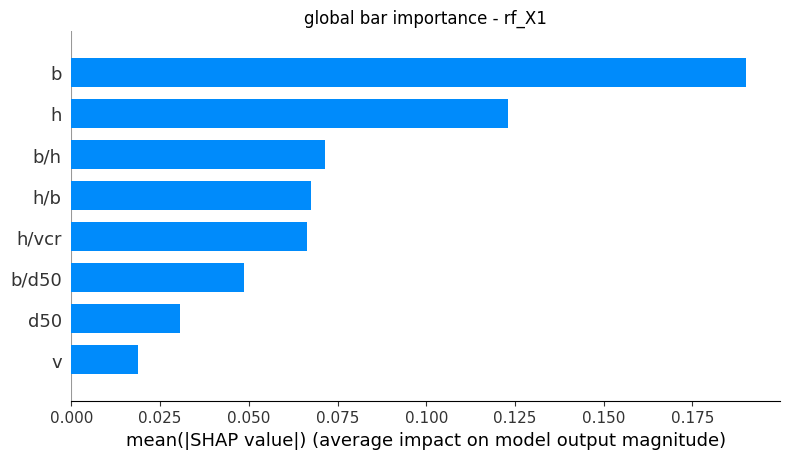

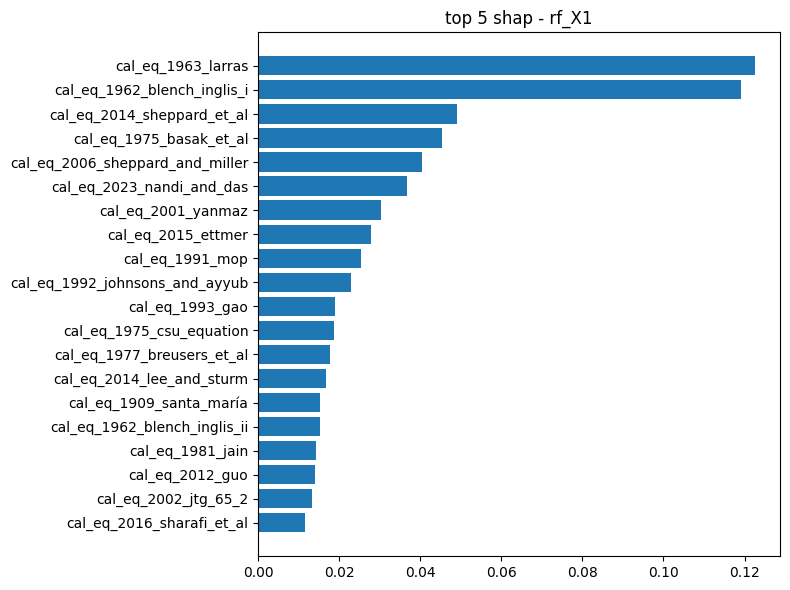


graficando: xgb_X1


/tmp/ipython-input-1492566060.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X[cols], show=False, max_display=len(cols))


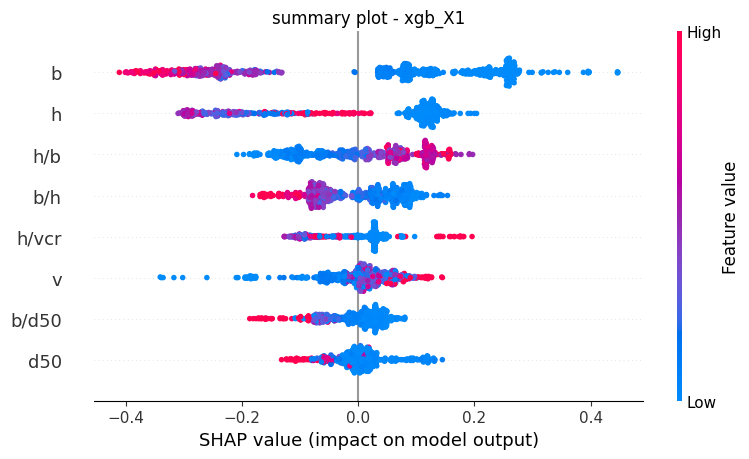

/tmp/ipython-input-1492566060.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X[cols], plot_type="bar", max_display=len(cols), show=False)


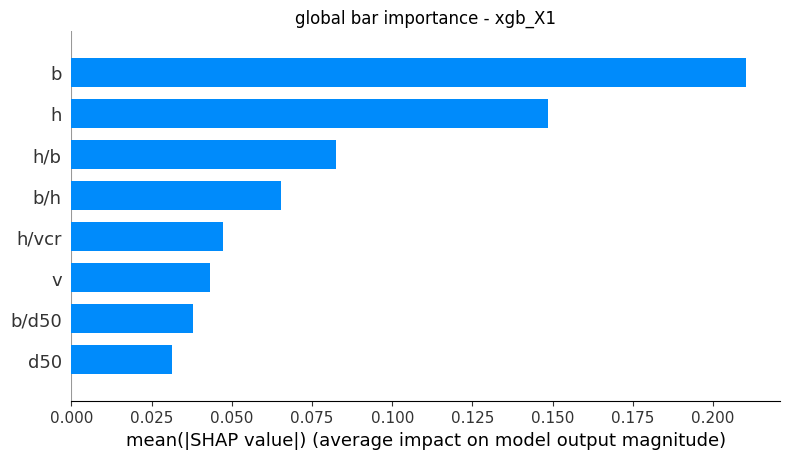

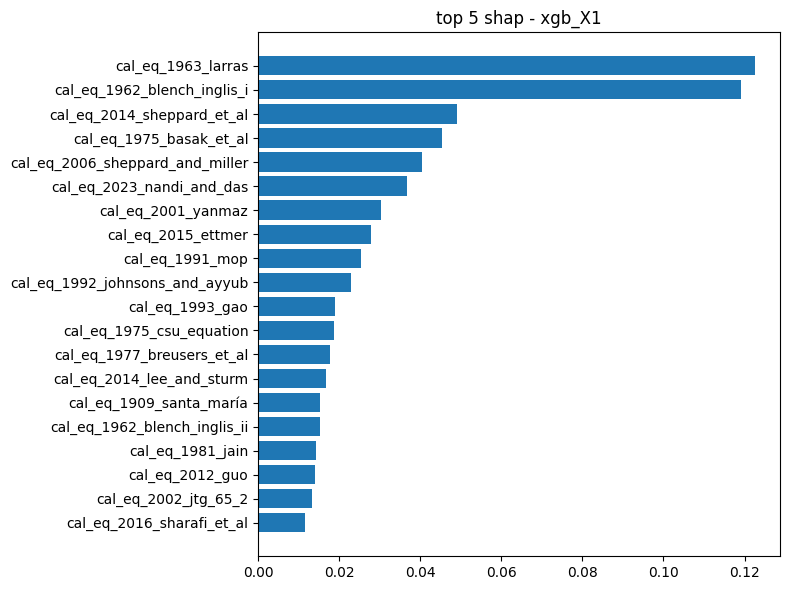


graficando: rf_X2


/tmp/ipython-input-1492566060.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X[cols], show=False, max_display=len(cols))


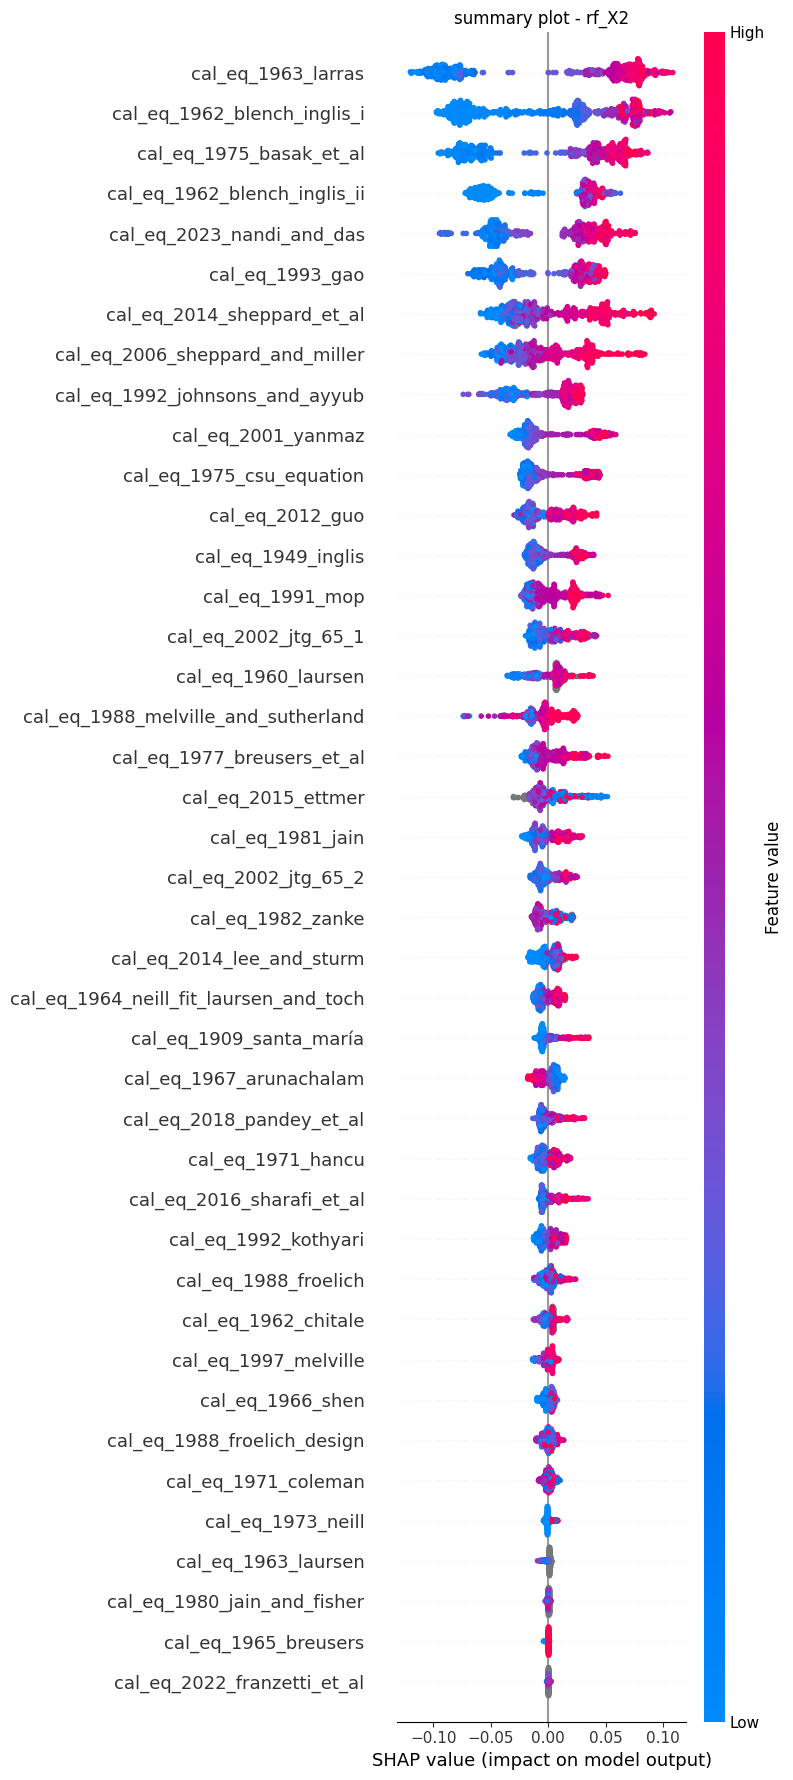

/tmp/ipython-input-1492566060.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X[cols], plot_type="bar", max_display=len(cols), show=False)


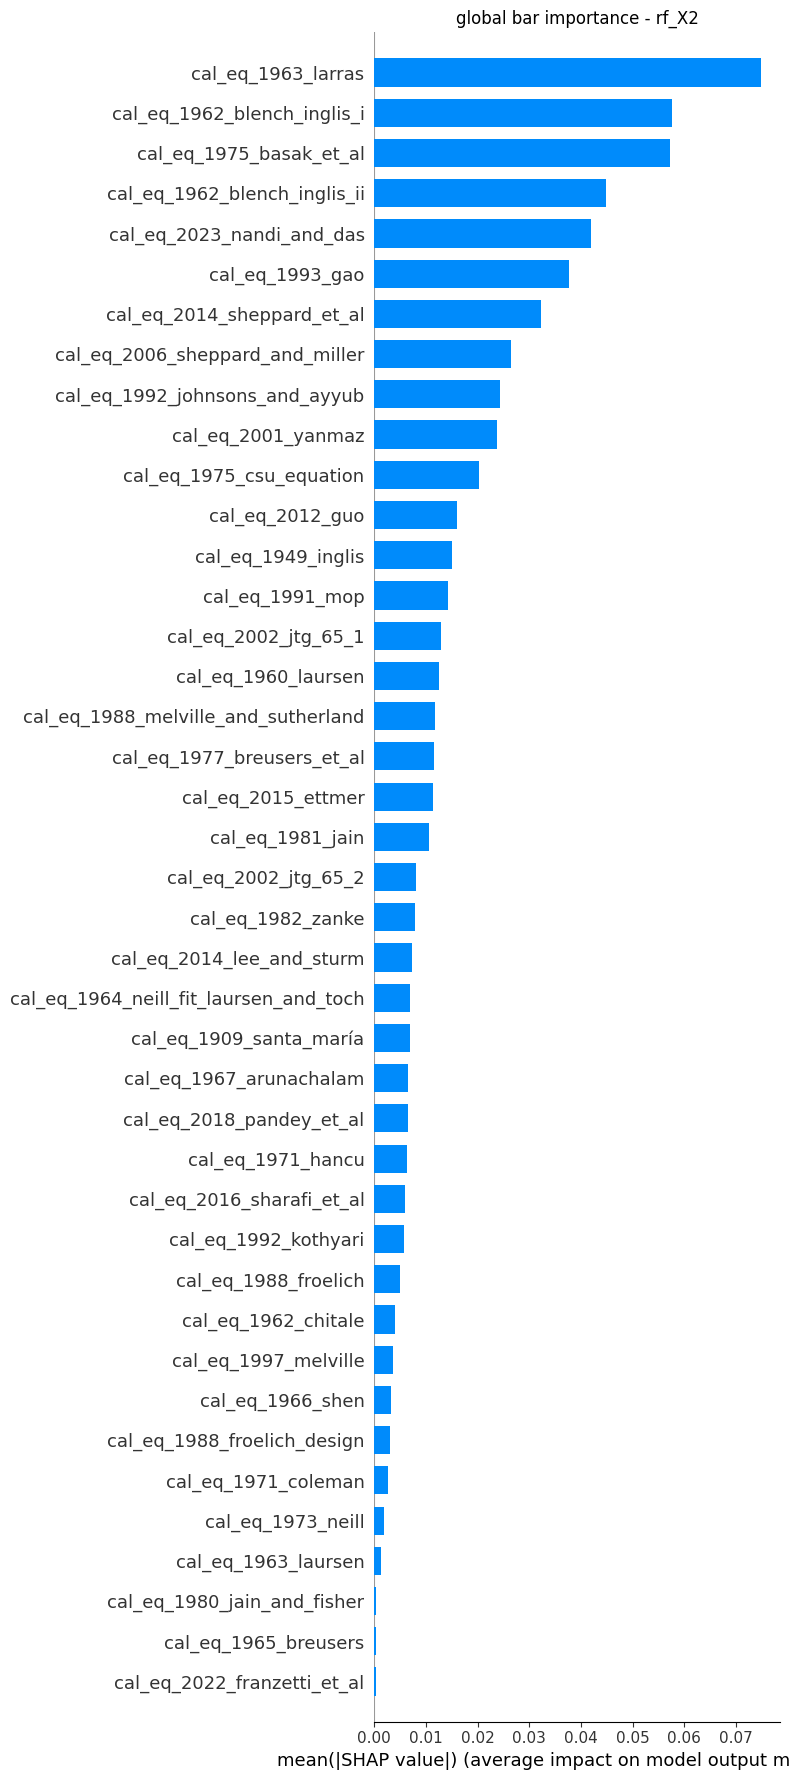

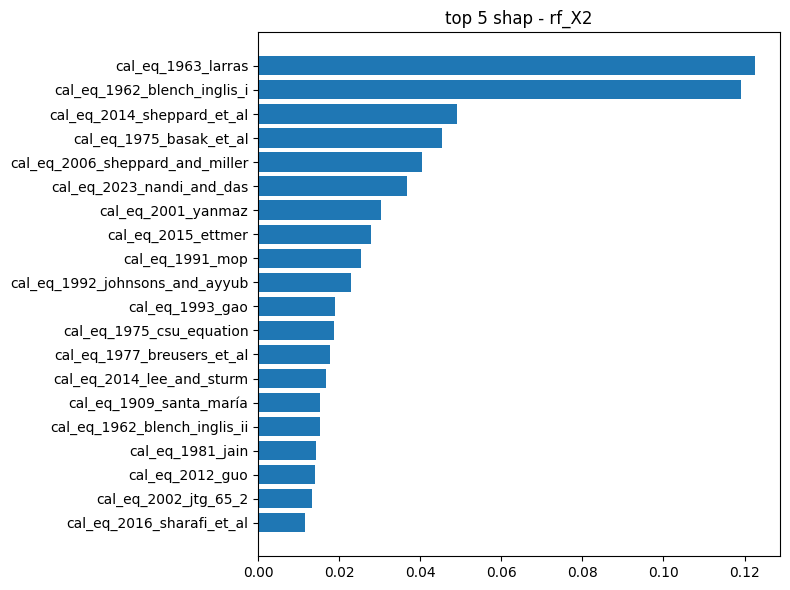


graficando: xgb_X2


/tmp/ipython-input-1492566060.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X[cols], show=False, max_display=len(cols))


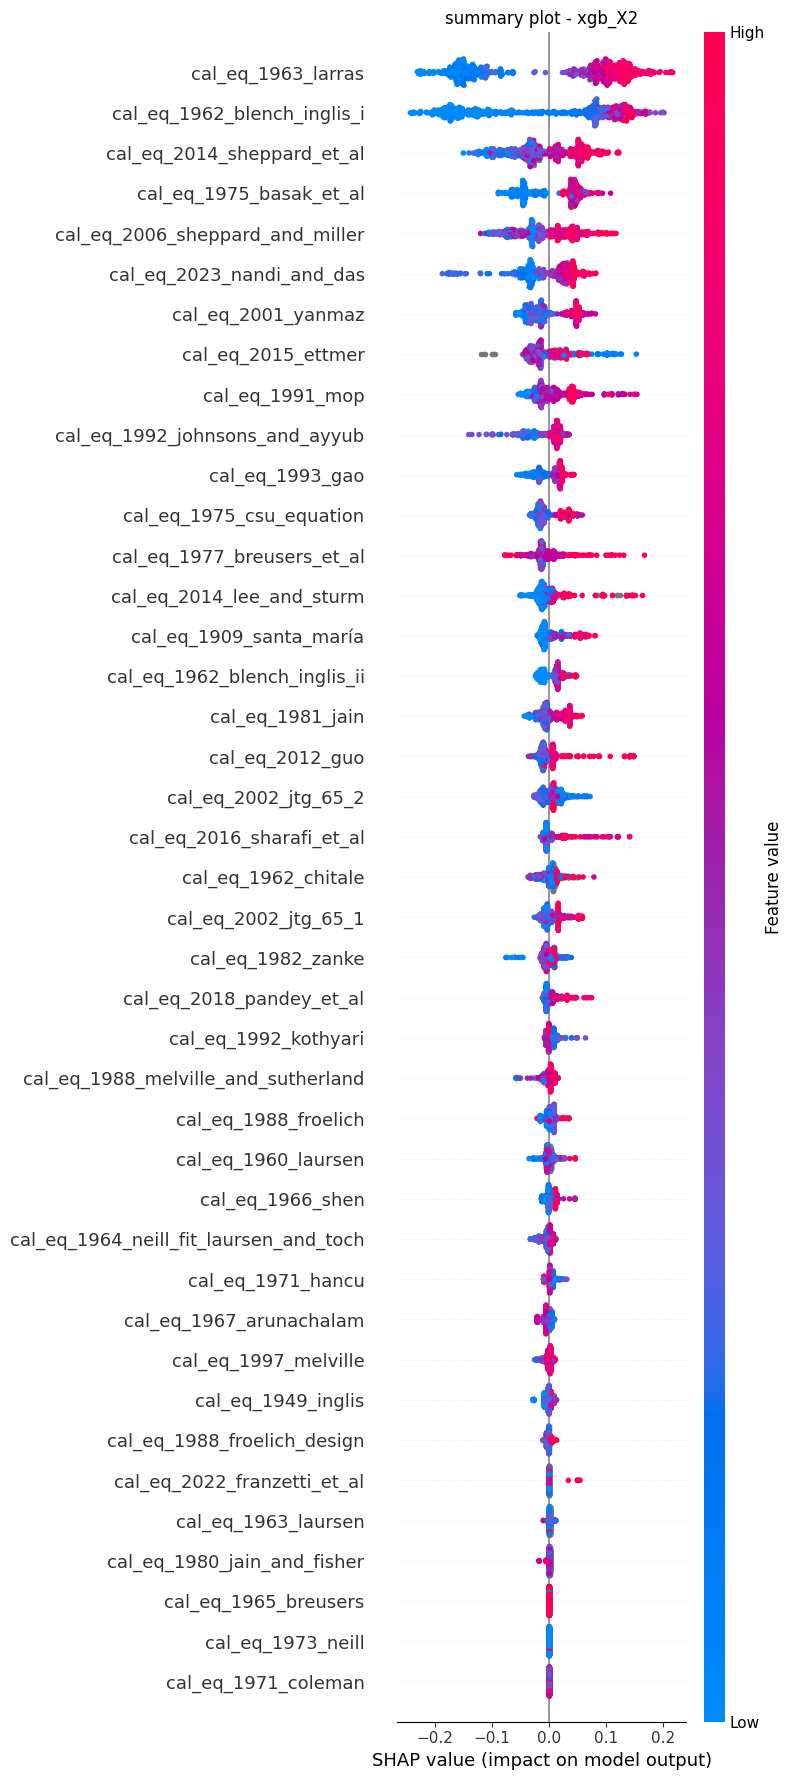

/tmp/ipython-input-1492566060.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X[cols], plot_type="bar", max_display=len(cols), show=False)


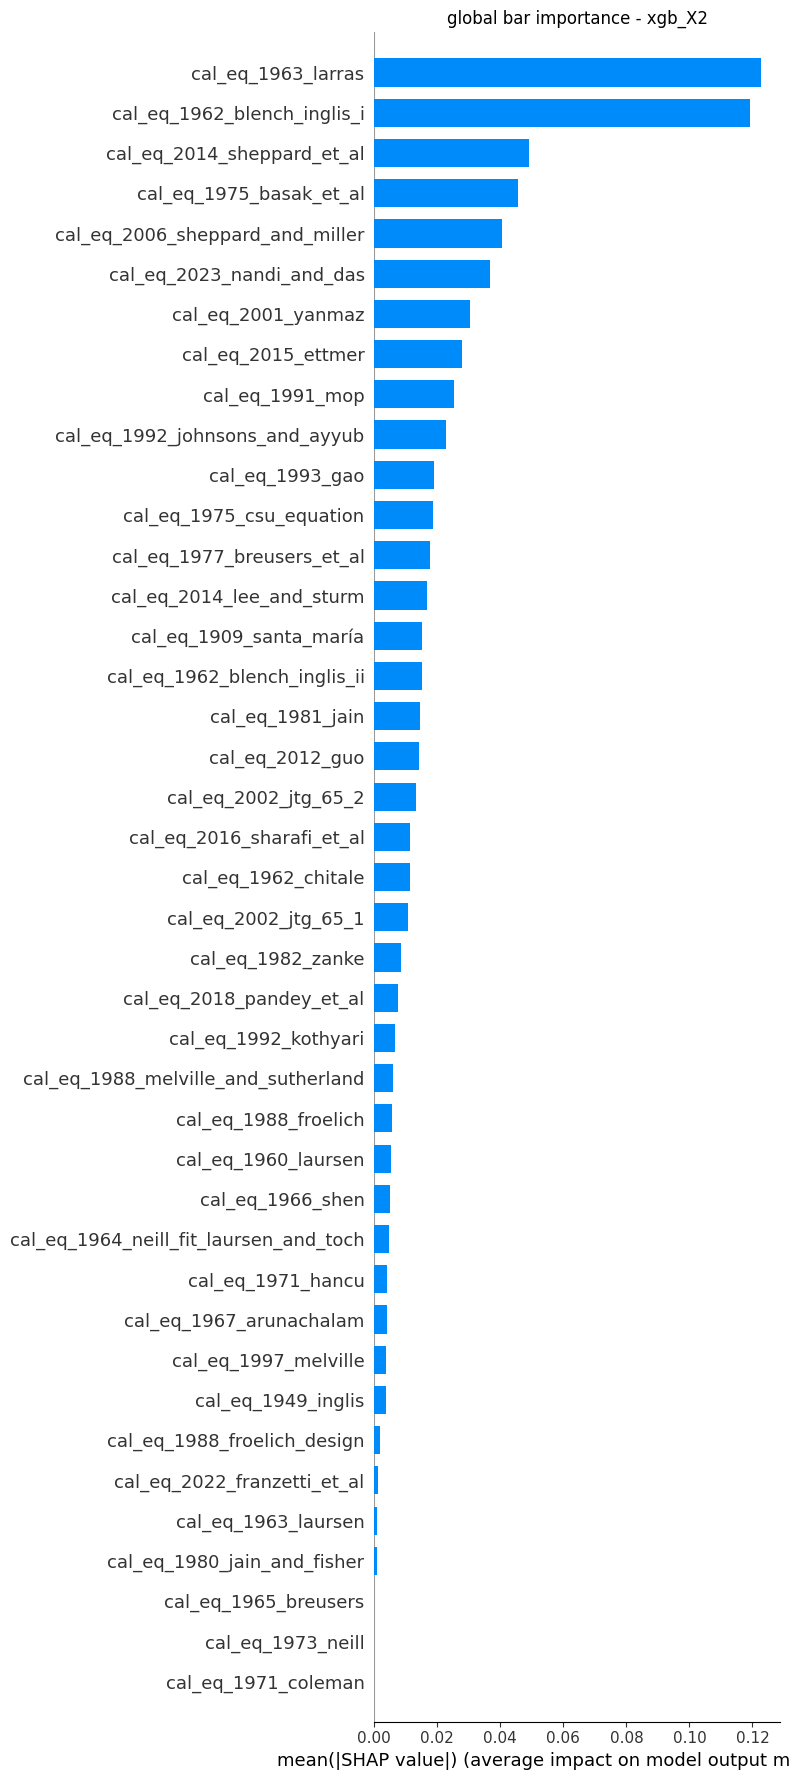

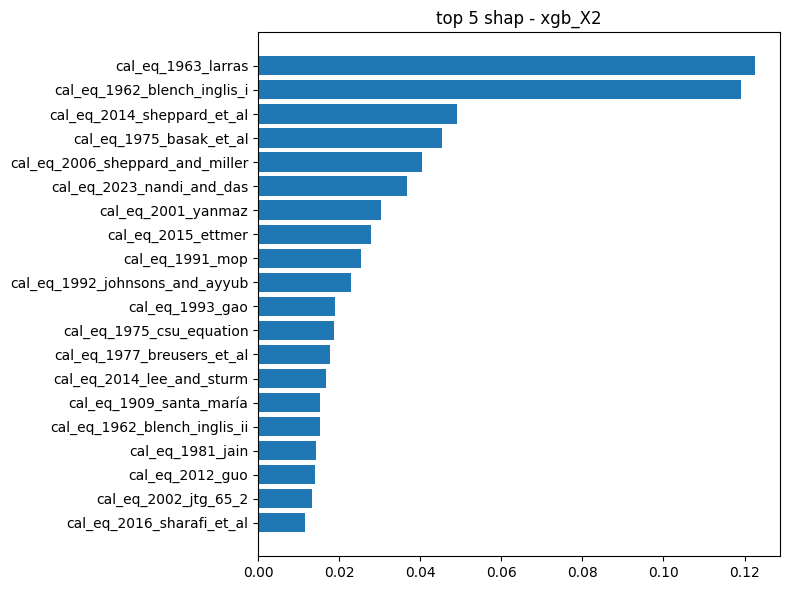

In [1085]:
n=5

for name, res in shap_results.items():
    print("\ngraficando:", name)

    shap_values = res["shap_values"]
    X = res["X"]
    cols = res["cols"]

    # summary plot (violin)
    plt.figure(figsize=(10,5))
    shap.summary_plot(shap_values, X[cols], show=False, max_display=len(cols))
    plt.title(f"summary plot - {name}")
    plt.tight_layout()
    plt.show()

    # bar plot global
    plt.figure(figsize=(8,5))
    shap.summary_plot(shap_values, X[cols], plot_type="bar", max_display=len(cols), show=False)
    plt.title(f"global bar importance - {name}")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8,6))
    plt.barh(df_plot["feature"], df_plot["importance"])
    plt.gca().invert_yaxis()
    plt.title(f"top {n} shap - {name}")
    plt.tight_layout()
    plt.show()

### Hyperameters

In [481]:
import numpy as np
import pandas as pd
from pathlib import Path

# -------- helpers --------
def _extract_params(src):
    """Accepts dict, GridSearchCV (best_params_), or estimator (get_params). Returns a plain dict."""
    if src is None:
        return {}
    if isinstance(src, dict):
        return dict(src)
    # GridSearchCV / RandomizedSearchCV
    bp = getattr(src, "best_params_", None)
    if isinstance(bp, dict):
        return dict(bp)
    # Estimator with get_params
    gp = getattr(src, "get_params", None)
    if callable(gp):
        return dict(gp())
    return {}

def _fmt_val(v, ndigits=3):
    if v is None:
        return ""
    if isinstance(v, (int, np.integer)):
        return str(int(v))
    if isinstance(v, (float, np.floating)):
        # keep integers like 1.0 as "1", else round to ndigits
        if float(v).is_integer():
            return str(int(v))
        return f"{float(v):.{ndigits}f}"
    return str(v)

def build_hyperparams_table(best_sources: dict, family: str = "X2", savepath: str | None = None,
                            float_digits: int = 3) -> pd.DataFrame:
    """
    best_sources: dict mapping model key -> params/search/estimator.
                  e.g., {'rf_X2': fitted_search_rf_X2, 'xgb_X2': fitted_search_xgb_X2}
    family: 'X1' or 'X2'
    """
    # which models to include by family and the order of hyperparameters to show
    if family.upper() == "X1":
        model_rows = [("RF1", "rf_X1"), ("XGB1", "xgb_X1")]
    else:
        model_rows = [("RF2", "rf_X2"), ("XGB2", "xgb_X2")]

    # Hyperparameters of interest (display name -> candidate keys to look up)
    RF_ORDER = [
        ("n_estimators",        ["n_estimators"]),
        ("max_depth",           ["max_depth"]),
        ("min_samples_split",   ["min_samples_split"]),
        ("min_samples_leaf",    ["min_samples_leaf"]),
        ("max_features",        ["max_features"]),
    ]
    XGB_ORDER = [
        ("n_estimators",      ["n_estimators"]),
        ("max_depth",         ["max_depth"]),
        ("learning_rate",     ["learning_rate", "eta"]),
        ("subsample",         ["subsample"]),
        ("colsample_bytree",  ["colsample_bytree"]),
        ("gamma",             ["gamma"]),
        ("reg_alpha",         ["reg_alpha"]),
        ("reg_lambda",        ["reg_lambda"]),
        ("min_child_weight",  ["min_child_weight"]),
    ]

    rows = []
    for disp_name, key in model_rows:
        params = _extract_params(best_sources.get(key))
        # choose list according to model type
        order = RF_ORDER if disp_name.startswith("RF") else XGB_ORDER

        # first row will carry the model name; subsequent rows leave it blank for visual grouping
        first = True
        for hyper_name, keys in order:
            # find the first key that exists in the params dict (some libs prefix with estimator name)
            value = None
            for k in keys:
                if k in params:
                    value = params[k]
                    break
                # sometimes keys come prefixed, e.g. 'regressor__n_estimators' or 'xgb__n_estimators'
                if not value:
                    for pk, pv in params.items():
                        if pk.endswith("__"+k) or pk.split("__")[-1] == k:
                            value = pv
                            break
                if value is not None:
                    break

            rows.append([
                disp_name if first else "",       # only print model once
                hyper_name,
                _fmt_val(value, ndigits=float_digits)
            ])
            first = False

    df = pd.DataFrame(rows, columns=["Model", "Hyperparameter", "Value"])

    # Save to Excel
    Path("results/metrics").mkdir(parents=True, exist_ok=True)
    if savepath is None:
        savepath = f"results/metrics/hyperparams_{family.upper()}.xlsx"

    try:
        with pd.ExcelWriter(savepath, engine="xlsxwriter") as writer:
            df.to_excel(writer, index=False, sheet_name="Table 8")
            # simple column width
            ws = writer.sheets["Table 8"]
            ws.set_column("A:A", 10)
            ws.set_column("B:B", 22)
            ws.set_column("C:C", 16)
    except ModuleNotFoundError:
        with pd.ExcelWriter(savepath, engine="openpyxl") as writer:
            df.to_excel(writer, index=False, sheet_name="Table 8")

    print(f"Hyperparameters table saved to: {savepath}")
    try:
        display(df)  # if in notebook
    except Exception:
        pass
    return df

In [482]:
# Para X1:
best_sources_X1 = {
    "rf_X1":  best_run_params.get("rf_X1"),
    "xgb_X1": best_run_params.get("xgb_X1"),
}
table_hp_X1 = build_hyperparams_table(best_sources_X1, family="X1")

# Para X2:
best_sources_X2 = {
    "rf_X2":  best_run_params.get("rf_X2"),   # puede ser dict, GridSearchCV o modelo
    "xgb_X2": best_run_params.get("xgb_X2"),
}
table_hp_X2 = build_hyperparams_table(best_sources_X2, family="X2")

Hyperparameters table saved to: results/metrics/hyperparams_X1.xlsx


,Model,Hyperparameter,Value
0,RF1,n_estimators,296
1,,max_depth,12
2,,min_samples_split,15
3,,min_samples_leaf,10
4,,max_features,log2
5,XGB1,n_estimators,112
6,,max_depth,11
7,,learning_rate,0.089
8,,subsample,0.691
9,,colsample_bytree,0.677


Hyperparameters table saved to: results/metrics/hyperparams_X2.xlsx


,Model,Hyperparameter,Value
0,RF2,n_estimators,296
1,,max_depth,12
2,,min_samples_split,15
3,,min_samples_leaf,10
4,,max_features,log2
5,XGB2,n_estimators,112
6,,max_depth,11
7,,learning_rate,0.089
8,,subsample,0.691
9,,colsample_bytree,0.677


##### Metrics

In [483]:
df_results = pd.DataFrame(results_test_subcritic)
display(df_results[['dataset', 'r2', 'rmse', 'mae', 'mape','> +10%','±10%','< -10%']])
df_results.to_csv("results/metrics/metrics_subcritic_repetition.csv",
index=False)

,dataset,r2,rmse,mae,mape,> +10%,±10%,< -10%
0,RF_X1_subcritic_train_run_1,0.772348,0.298808,0.213253,28.215285,35.846373,39.829303,24.324324
1,RF_X1_subcritic_test_run_1,0.755425,0.297602,0.227827,35.193651,43.829787,31.489362,24.680851
2,XGB_X1_subcritic_train_run_1,0.818168,0.267050,0.196980,26.524586,34.139403,43.243243,22.617354
3,XGB_X1_subcritic_test_run_1,0.787668,0.277292,0.213338,32.702541,41.702128,34.042553,24.255319
4,RF_X2_subcritic_train_run_1,0.823902,0.262805,0.185169,26.097138,32.859175,46.372688,20.768137
5,RF_X2_subcritic_test_run_1,0.773256,0.286548,0.215933,34.842416,40.425532,36.170213,23.404255
6,XGB_X2_subcritic_train_run_1,0.888626,0.209001,0.154411,22.938596,29.445235,51.493599,19.061166
7,XGB_X2_subcritic_test_run_1,0.788459,0.276776,0.202935,32.578130,37.021277,40.851064,22.127660
8,RF_X1_subcritic_train_run_2,0.787819,0.285703,0.203709,28.195150,34.423898,41.678521,23.897582
9,RF_X1_subcritic_test_run_2,0.634974,0.378812,0.276159,34.647594,40.000000,30.638298,29.361702


In [484]:
df_results_supercritic = pd.DataFrame(results_supercritic_test)
display(df_results_supercritic[['dataset', 'r2', 'rmse', 'mae', 'mape','> +10%','±10%','< -10%']])
df_results_supercritic.to_csv("results/metrics/metrics_train_supercritic_repetition.csv", index=False)

,dataset,r2,rmse,mae,mape,> +10%,±10%,< -10%
0,RF_X1_supercritic_test_run_1,0.421413,0.411642,0.289731,25.449108,27.472527,39.560440,32.967033
1,XGB_X1_supercritic_test_run_1,0.439958,0.404991,0.290081,26.385905,27.472527,42.857143,29.670330
2,RF_X2_supercritic_test_run_1,0.550343,0.362891,0.264857,24.353408,37.362637,39.560440,23.076923
3,XGB_X2_supercritic_test_run_1,0.597107,0.343503,0.271376,23.850575,38.461538,32.967033,28.571429
4,RF_X1_supercritic_test_run_2,0.442750,0.403980,0.285908,24.412367,26.373626,42.857143,30.769231
5,XGB_X1_supercritic_test_run_2,0.386512,0.423875,0.298591,26.902534,26.373626,41.758242,31.868132
6,RF_X2_supercritic_test_run_2,0.538277,0.367727,0.267212,24.759121,39.560440,41.758242,18.681319
7,XGB_X2_supercritic_test_run_2,0.576965,0.351984,0.264137,24.303485,37.362637,37.362637,25.274725


In [485]:
import numpy as np
import pandas as pd
from pathlib import Path

# ---------- helpers ----------
def _prep_results(df: pd.DataFrame) -> pd.DataFrame:
    """
    Clean/standardize result rows and ensure error columns are included.
    (Assumes 'over_pct', 'within_pct', 'under_pct' or similar names exist in the input DataFrame rows)
    """
    out = df.copy()

    # Strip suffixes (sin cambios)
    out['base_model'] = (
        out['dataset']
        .str.replace(r'_train_run_\d+', '', regex=True)
        .str.replace(r'_test_run_\d+',  '', regex=True)
        .str.replace(r'_run_\d+',      '', regex=True)
    )

    # Split type (sin cambios)
    out['dataset_type'] = np.where(out['dataset'].str.contains('train', case=False, na=False),
                                   'Train', 'Test')
    out.loc[out['dataset'].str.contains('supercritic', case=False, na=False), 'dataset_type'] = 'Verification'

    # Short labels & family (sin cambios)
    def _short(m):
        if 'RF_X1'  in m: return 'RF1'
        if 'XGB_X1' in m: return 'XGB1'
        if 'RF_X2'  in m: return 'RF2'
        if 'XGB_X2' in m: return 'XGB2'
        return m

    out['Model']  = out['base_model'].map(_short)
    out['family'] = np.where(out['Model'].str.endswith('1'), 'X1',
                       np.where(out['Model'].str.endswith('2'), 'X2', 'OTHER'))

    # --- Renombrar/Asegurar Columnas de Porcentaje para Agregación ---
    # Asume que las métricas de porcentaje (calculadas en el paso previo)
    # están presentes en los diccionarios de resultados.

    # Renombrar las columnas de porcentaje para facilitar la agregación:
    # Si las columnas en tu input son 'over_pct', 'within_pct', 'under_pct':
    out['E_gt_10'] = out['> +10%'] # Error > +10% (Sobrestima)
    out['E_le_10_abs'] = out['±10%'] # Error Absoluto <= 10% (Dentro)
    out['E_lt_minus_10'] = out['< -10%'] # Error < -10% (Subestima)
    # Si las columnas en tu input no tienen esos nombres, AJUSTA las líneas de arriba.

    return out


def build_table(results_subcritic, results_supercritic, family='X1', savepath=None):
    """
    Build a table (mean ± std) for Train/Test/Verification phases, now including the
    over, within, and under 10% error metrics.
    """
    # Assemble full results
    df_all = pd.concat(
        [_prep_results(pd.DataFrame(results_subcritic)),
         _prep_results(pd.DataFrame(results_supercritic))],
        ignore_index=True
    )
    df_all = df_all[df_all['family'] == family].copy()

    # Aggregate mean/std per (Phase, Model)
    g = df_all.groupby(['dataset_type', 'Model']).agg(
        r2_mean=('r2','mean'),      r2_std=('r2','std'),
        rmse_mean=('rmse','mean'),  rmse_std=('rmse','std'),
        mae_mean=('mae','mean'),    mae_std=('mae','std'),
        mape_mean=('mape','mean'),  mape_std=('mape','std'),

        # --- NUEVA AGREGACIÓN PARA LOS PORCENTAJES DE ERROR ---
        E_gt_10_mean=('E_gt_10', 'mean'),           E_gt_10_std=('E_gt_10', 'std'),
        E_le_10_abs_mean=('E_le_10_abs', 'mean'),   E_le_10_abs_std=('E_le_10_abs', 'std'),
        E_lt_minus_10_mean=('E_lt_minus_10', 'mean'), E_lt_minus_10_std=('E_lt_minus_10', 'std'),
        # ------------------------------------------------------
    )

    # formatters
    def fmt2(metric):
        return g[f'{metric}_mean'].round(2).map(lambda x: f"{x:.2f}") + " ± " + g[f'{metric}_std'].round(2).map(lambda x: f"{x:.2f}")
    def fmt1(metric):
        return g[f'{metric}_mean'].round(1).map(lambda x: f"{x:.1f}") + " ± " + g[f'{metric}_std'].round(1).map(lambda x: f"{x:.1f}")

    # Formateador para porcentaje (ya está en porcentaje, solo se redondea)
    def fmt_pct(metric):
        mean_pct = g[f'{metric}_mean'].round(1).map(lambda x: f"{x:.1f}")
        std_pct = g[f'{metric}_std'].round(1).map(lambda x: f"{x:.1f}")
        return mean_pct + " ± " + std_pct


    # Final table with requested columns
    tbl = pd.DataFrame(index=g.index).assign(
        **{
            'R2'         : fmt2('r2'),
            'RMSE'       : fmt2('rmse'),
            'MAE'        : fmt2('mae'),
            'MAPE (%)'   : fmt1('mape'),
            # --- NUEVAS COLUMNAS DE PORCENTAJE ---
            '> +10% (%)' : fmt_pct('E_gt_10'),
            '±10% (%)'   : fmt_pct('E_le_10_abs'),
            '< -10% (%)' : fmt_pct('E_lt_minus_10'),
            # -------------------------------------
        }
    )

    # Row order: phases and models (sin cambios)
    order_phase = ['Train', 'Test', 'Verification']
    order_model = ['RF1','XGB1'] if family == 'X1' else ['RF2','XGB2']
    idx = [(p, m) for p in order_phase for m in order_model if (p, m) in tbl.index]
    tbl = tbl.reindex(idx)

    # Tidy MultiIndex view (sin cambios)
    tbl_out = tbl.copy()
    tbl_out.index = pd.MultiIndex.from_tuples(tbl_out.index, names=['Phase', 'Model'])

    # Pretty view with blank header rows before each phase block (sin cambios)
    def pretty_block(phase):
        if phase not in tbl_out.index.get_level_values(0):
            return pd.DataFrame(columns=tbl_out.columns)
        block = tbl_out.loc[phase]
        header = pd.DataFrame([[''] * len(block.columns)], columns=block.columns, index=[phase])
        return pd.concat([header, block], axis=0)

    pretty = pd.concat([pretty_block(p) for p in order_phase], axis=0)

    # Save to Excel (sin cambios)
    Path('res').mkdir(parents=True, exist_ok=True)
    if savepath is None:
        savepath = f'res/table_{family}_train_test_verification.xlsx'

    try:
        with pd.ExcelWriter(savepath, engine='xlsxwriter') as writer:
            tbl_out.to_excel(writer, sheet_name='tidy')
            pretty.to_excel(writer, sheet_name='pretty')

            # Light formatting (center columns)
            wb = writer.book
            fmt_center = wb.add_format({'align': 'center'})
            for ws_name in ['tidy', 'pretty']:
                ws = writer.sheets[ws_name]
                ws.set_column('A:Z', 16, fmt_center)
    except ModuleNotFoundError:
        # Fallback: openpyxl without extra formatting
        with pd.ExcelWriter(savepath, engine='openpyxl') as writer:
            tbl_out.to_excel(writer, sheet_name='tidy')
            pretty.to_excel(writer, sheet_name='pretty')

    print(f"Saved Excel to: {savepath}")

    # Show pretty view if running in a notebook
    try:
        display(pretty)  # noqa: F821
    except Exception:
        pass

    return pretty

In [486]:
# ---------- build X1 and X2 tables ----------
tabla_X1 = build_table(results_test_subcritic, results_supercritic_test, family='X1')
tabla_X2 = build_table(results_test_subcritic, results_supercritic_test, family='X2')

Saved Excel to: res/table_X1_train_test_verification.xlsx


,R2,RMSE,MAE,MAPE (%),> +10% (%),±10% (%),< -10% (%)
Train,,,,,,,
RF1,0.78 ± 0.01,0.29 ± 0.01,0.21 ± 0.01,28.2 ± 0.0,35.1 ± 1.0,40.8 ± 1.3,24.1 ± 0.3
XGB1,0.82 ± 0.01,0.26 ± 0.01,0.19 ± 0.01,25.8 ± 1.0,33.1 ± 1.5,44.0 ± 1.0,23.0 ± 0.5
Test,,,,,,,
RF1,0.70 ± 0.09,0.34 ± 0.06,0.25 ± 0.03,34.9 ± 0.4,41.9 ± 2.7,31.1 ± 0.6,27.0 ± 3.3
XGB1,0.73 ± 0.08,0.32 ± 0.06,0.24 ± 0.03,32.1 ± 0.8,41.5 ± 0.3,32.8 ± 1.8,25.7 ± 2.1
Verification,,,,,,,
RF1,0.43 ± 0.02,0.41 ± 0.01,0.29 ± 0.00,24.9 ± 0.7,26.9 ± 0.8,41.2 ± 2.3,31.9 ± 1.6
XGB1,0.41 ± 0.04,0.41 ± 0.01,0.29 ± 0.01,26.6 ± 0.4,26.9 ± 0.8,42.3 ± 0.8,30.8 ± 1.6


Saved Excel to: res/table_X2_train_test_verification.xlsx


,R2,RMSE,MAE,MAPE (%),> +10% (%),±10% (%),< -10% (%)
Train,,,,,,,
RF2,0.83 ± 0.00,0.26 ± 0.00,0.18 ± 0.00,26.2 ± 0.1,32.8 ± 0.1,46.3 ± 0.1,20.9 ± 0.2
XGB2,0.89 ± 0.00,0.21 ± 0.00,0.15 ± 0.00,22.3 ± 0.8,29.7 ± 0.3,50.9 ± 0.8,19.4 ± 0.5
Test,,,,,,,
RF2,0.73 ± 0.06,0.32 ± 0.04,0.24 ± 0.03,33.8 ± 1.5,39.4 ± 1.5,36.2 ± 0.0,24.5 ± 1.5
XGB2,0.76 ± 0.04,0.30 ± 0.03,0.22 ± 0.02,30.8 ± 2.5,36.2 ± 1.2,39.8 ± 1.5,24.0 ± 2.7
Verification,,,,,,,
RF2,0.54 ± 0.01,0.37 ± 0.00,0.27 ± 0.00,24.6 ± 0.3,38.5 ± 1.6,40.7 ± 1.6,20.9 ± 3.1
XGB2,0.59 ± 0.01,0.35 ± 0.01,0.27 ± 0.01,24.1 ± 0.3,37.9 ± 0.8,35.2 ± 3.1,26.9 ± 2.3


##### Figures

###### RF and XGB with hydraulics variables as input

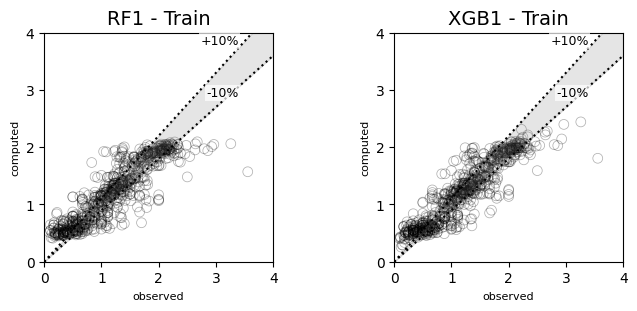

In [487]:
# Plot only X1 results.
fig, axes = plt.subplots(1, 2, figsize=(7, 3), constrained_layout=True)

plot_results(
    axes[0],
    # Observed
    y_subcritic_train_np,
    # Calculated
    results_rf_X1_train['y_pred'],
    'RF1 - Train',  # Título para el conjunto de entrenamiento
    global_x_min,
    global_x_max,
    equal_aspect=True
)

plot_results(
    axes[1],
    # Observed
    y_subcritic_train_np,
    # Calculated
    results_xgb_X1_train['y_pred'],
    'XGB1 - Train',  # Título para el conjunto de entrenamiento
    global_x_min,
    global_x_max,
    equal_aspect=True
)

# Save figure.
plt.savefig('results/figures/Figure_3.png', format='png', dpi=1000, bbox_inches='tight')
plt.show();

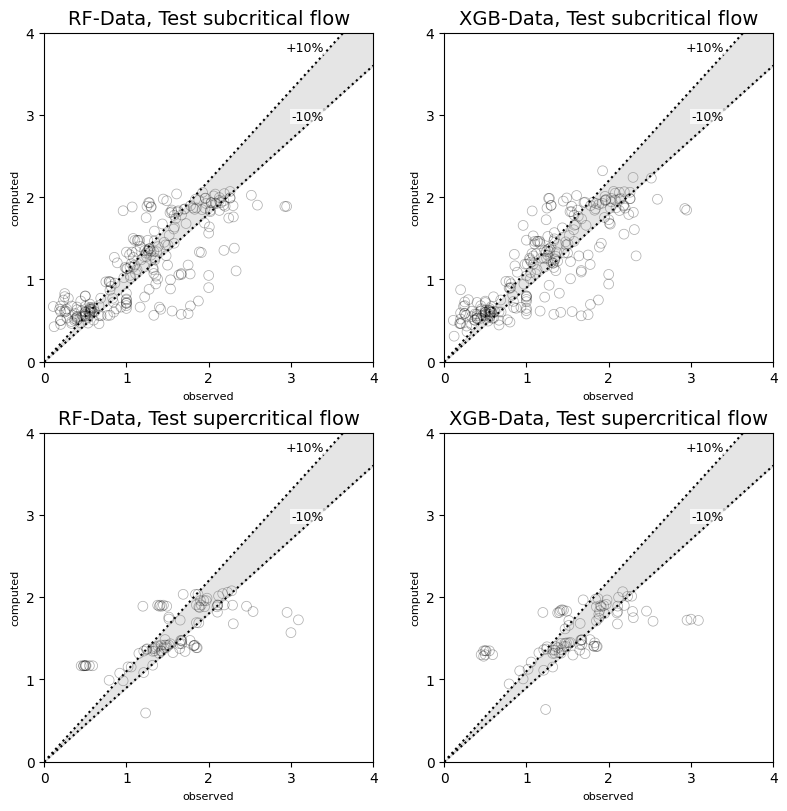

In [488]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8), constrained_layout=True)

plot_results(
    axes[0, 0],
    y_subcritic_test_np,
    results_rf_X1_test['y_pred'],
    'RF-Data, Test subcritical flow',
    global_x_min,
    global_x_max,
    equal_aspect=True
)

plot_results(
    axes[0, 1],
    y_subcritic_test_np,
    results_xgb_X1_test['y_pred'],
    'XGB-Data, Test subcritical flow',
    global_x_min,
    global_x_max,
    equal_aspect=True
)

plot_results(
    axes[1, 0],
    y_supercritic_test,
    results_rf_X1_supercritic_test['y_pred'],
    'RF-Data, Test supercritical flow',
    global_x_min,
    global_x_max,
    equal_aspect=True
)

plot_results(
    axes[1, 1],
    y_supercritic_test,
    results_xgb_X1_supercritic_test['y_pred'],
    'XGB-Data, Test supercritical flow',
    global_x_min,
    global_x_max,
    equal_aspect=True
)

plt.savefig('results/figures/ml_res_dataset.png', format='png', dpi=1000, bbox_inches='tight')
plt.show()

###### RF and XGB with formulas as input

In [492]:
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plot_results(ax, observed, calculated, title, global_x_min, global_x_max, equal_aspect=False):
    sns.scatterplot(x=observed, y=calculated, alpha=0.3, ax=ax, edgecolors='black', facecolors='none', s=50)

    mask = ~np.isnan(observed) & ~np.isnan(calculated)
    obs_filtered = observed[mask]
    cal_filtered = calculated[mask]

    if len(obs_filtered) == 0:
        ax.set_title(f"{title}\n")
        ax.axis('off')
        return

    relative_error = (cal_filtered - obs_filtered) / obs_filtered
    error_over_10 = np.sum(relative_error > 0.10)
    error_within_10 = np.sum(np.abs(relative_error) <= 0.10)
    error_under_10 = np.sum(relative_error < -0.10)
    total = len(relative_error)

    if total == 0:
        over_pct = 0
        within_pct = 0
        under_pct = 0
    else:
        over_pct = 100 * error_over_10 / total
        within_pct = 100 * error_within_10 / total
        under_pct = 100 * error_under_10 / total

    line_plot_range = np.linspace(global_x_min, global_x_max, 100)
    ax.plot(line_plot_range, line_plot_range * 1.10, color='black', linestyle=':')
    ax.plot(line_plot_range, line_plot_range * 0.90, color='black', linestyle=':')
    ax.fill_between(line_plot_range, line_plot_range * 0.90, line_plot_range * 1.10, color='gray', alpha=0.2)

    ax.set_xlabel('observed', fontsize=8)
    ax.set_ylabel('computed', fontsize=8)

    ax.set_xlim(global_x_min, global_x_max)

    current_y_max = cal_filtered.max() if len(cal_filtered) > 0 else 0.1
    current_y_max_padded = max(1.0, np.ceil(current_y_max * 1.1))
    if current_y_max_padded < 4:
        current_y_max_padded = 4
    ax.set_ylim(bottom=0, top=current_y_max_padded)

    ax.xaxis.set_major_locator(MultipleLocator(1))
    y_tick_step = max(1, int(current_y_max_padded / 4))
    if y_tick_step == 0: y_tick_step = 0.5
    ax.yaxis.set_major_locator(MultipleLocator(y_tick_step))

    ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%d'))

    ax.set_title(title, fontsize=14)

    text_x_pos = global_x_max * 0.85

    ax.text(text_x_pos, text_x_pos * 1.10, '+10%',
            horizontalalignment='right', verticalalignment='bottom',
            color='black', fontsize=9, rotation=0,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    ax.text(text_x_pos, text_x_pos * 0.90, '-10%',
            horizontalalignment='right', verticalalignment='top',
            color='black', fontsize=9, rotation=0,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    if equal_aspect:
        ax.set_aspect('equal', adjustable='box')

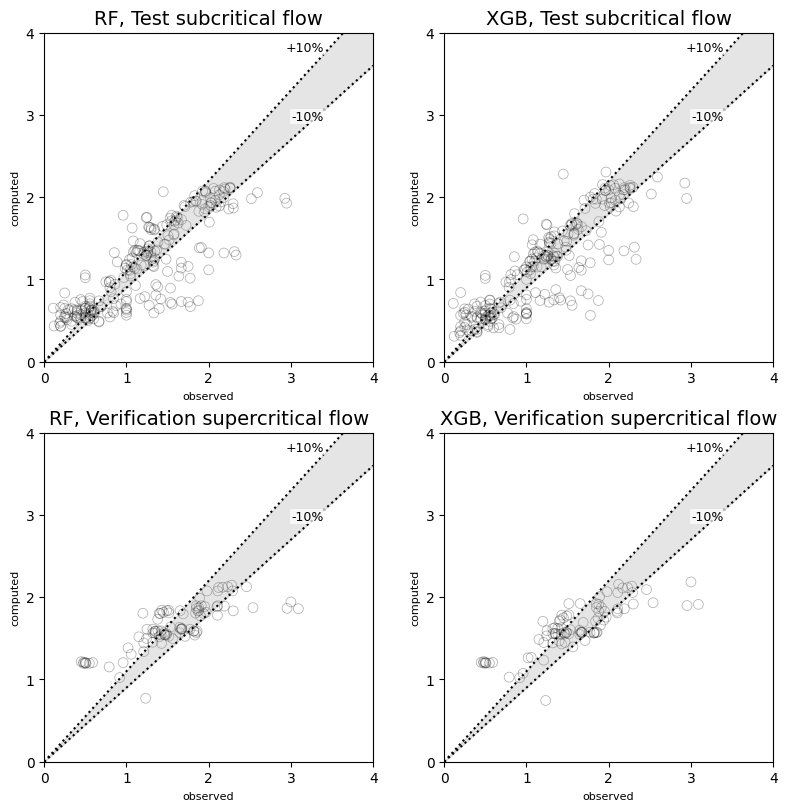

In [493]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(8, 8), constrained_layout=True)

plot_results(
    axes[0, 0],
    y_subcritic_test_np,
    results_rf_X2_test['y_pred'],
    'RF, Test subcritical flow',
    global_x_min,
    global_x_max,
    equal_aspect=True
)

plot_results(
    axes[0, 1],
    y_subcritic_test_np,
    results_xgb_X2_test['y_pred'],
    'XGB, Test subcritical flow',
    global_x_min,
    global_x_max,
    equal_aspect=True
)

plot_results(
    axes[1, 0],
    y_supercritic_test,
    results_rf_X2_supercritic_test['y_pred'],
    'RF, Verification supercritical flow',
    global_x_min,
    global_x_max,
    equal_aspect=True
)

plot_results(
    axes[1, 1],
    y_supercritic_test,
    results_xgb_X2_supercritic_test['y_pred'],
    'XGB, Verification supercritical flow',
    global_x_min,
    global_x_max,
    equal_aspect=True
)

plt.savefig('res/fig_ml_formulas_test_verification.png', format='png', dpi=1000, bbox_inches='tight')
plt.show()